# DysCalc ML Component Pre-Processing, Training, and Evaluation

Using FUNA-DB Dataset and C4.5 Decision Tree Algorithm

## Validator-Oriented Methodological Assumptions and Scope

This notebook is organized to support external validation of the DysCalc machine learning component. The pipeline is intended for a thesis-level proof-of-concept screening system, not for clinical diagnosis.

The following assumptions guide the analysis:

1. **Dataset assumption:** The FUNA-DB learner records are assumed to contain relevant numeracy-task measures suitable for exploratory machine learning-based screening.
2. **Feature assumption:** The selected task features, including NC, DM, NS, ADD, SUB, and CA, are assumed to represent numeracy-related constructs such as number comparison, dot-magnitude processing, number sequencing, arithmetic addition, subtraction, and calculation ability.
3. **Label assumption:** The At-Risk and Typical classes are treated as operational screening categories derived from RMAT performance. These labels are not interpreted as clinical diagnostic categories.
4. **Leakage-control assumption:** RMAT is used only to construct the target label and is excluded from the predictive feature set.
5. **Preprocessing assumption:** Any imputation, missingness handling, and clipping rules must be estimated from the training set only and then applied unchanged to validation and test sets.
6. **Synthetic-data assumption:** Synthetic At-Risk records are used only for training augmentation. They are not treated as real learner records and are not included in validation or test sets.
7. **Evaluation assumption:** Validation and test sets remain fully real and unseen during synthetic-data generation, model training, and final evaluation.
8. **Screening-metric assumption:** Recall and F2-score are prioritized because, in a screening-support context, missing an At-Risk learner may delay instructional support.
9. **Decision-support assumption:** The model output is intended to assist teacher review and instructional planning, not to replace professional judgment.


## Global Imports, Configs, and Setups

### Imports

In [1]:
import os, warnings, random, json, sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from itertools import product
from typing import Dict, List, Optional
from joblib import Parallel, delayed

import scipy.stats as stats
from scipy.stats import gaussian_kde, pearsonr
from scipy.spatial.distance import jensenshannon

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import fbeta_score, f1_score, recall_score, precision_score, accuracy_score, roc_auc_score, mean_squared_error

from sdv.single_table import CopulaGANSynthesizer, CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

sys.path.append(str(Path().resolve().parent))
from src.C45DecisionTree import C45DecisionTree

### Configs

In [2]:
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

AT_RIST_COLOR = '#ED7D31'
TYPICAL_COLOR = '#5B9BD5'
REAL_COLOR = '#54A24B'
SYNTHETIC_COLOR = '#E45756'

EPSILON = 1e-9
SEED = 42
NUMBER_PROCESSING = ['NC', 'DM']
ARITHMETIC_FLUENCY = ['NS', 'ADD', 'SUB', 'CA']
FEATURE_COLUMNS = NUMBER_PROCESSING + ARITHMETIC_FLUENCY
DERIVED_FEATURES = ['NP', 'SN', 'AF', 'BC', 'AS', 'PF']

FUNA_DB_DOMAIN_MAPPING: Dict[str, str] = {
    "NC":  "Number Comparison",
    "DM":  "Digit-Dot Matching",
    "NP":  "Overall Processing Efficiency",
    "SN":  "Symbolic vs. Non-Symbolic Processing Difference",
    "NS":  "Number Series",
    "ADD": "Single-Digit Addition",
    "SUB": "Single-Digit Subtraction",
    "CA":  "Multi-Digit Addition and Subtraction",
    "AF":  "Overall Arithmetic Fluency",
    "BC":  "Basic vs. Complex Arithmetic Contrast",
    "AS":  "Addition vs. Subtraction Asymmetry",
    "PF":  "Processing-Fluency Integration",
}

### Paths

In [3]:
ROOT_DIR = Path().resolve().parent
DATASET_DIR = ROOT_DIR / "datasets"
RAW_DATASET_DIR = DATASET_DIR / "raw"
PROCESSED_DATASET_DIR = DATASET_DIR / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs"
FIGURES_OUTPUTS = OUTPUTS_DIR / "dataset_analysis_figures"
LOGS_OUTPUTS = OUTPUTS_DIR / "logs_and_metrics"
GRIDSEARCH_OUTPUTS = OUTPUTS_DIR / "grid_search"
GAN_FIGURES = OUTPUTS_DIR / "gan_figures"

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(RAW_DATASET_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATASET_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(FIGURES_OUTPUTS, exist_ok=True)
os.makedirs(LOGS_OUTPUTS, exist_ok=True)
os.makedirs(GRIDSEARCH_OUTPUTS, exist_ok=True)
os.makedirs(GAN_FIGURES, exist_ok=True)

## 1.0 Label Construction, Data Preprocessing, and Feature Engineering


### 1.1 Dataset Labeling

This section covers the labeling of the dataset using standardized Räsänen Basic Arithmetic Test (RMAT) screening test and clinical threshold, EDA, and data cleaning. For labeling using RMAT scores, students with below the 35th percentile score are labeled as *1* (At-Risk) (Mononen et al., 2022) for supervised learning.

#### Validator Note: Label Construction Assumptions

The target variable is constructed from RMAT, which serves as an external arithmetic fluency reference. Learners at or below the selected percentile cutoff are labeled as **At-Risk**, while learners above the cutoff are labeled as **Typical**.

The 35th percentile cutoff is treated as an **operational screening threshold** for proof-of-concept model development. It should not be interpreted as a clinical or diagnostic boundary. This threshold identifies learners with relatively lower arithmetic fluency performance within the available dataset so that the model can learn a screening-oriented distinction between lower-performing and typical-performing groups.

After label construction, RMAT is removed from the model input features. This prevents the model from directly learning from the same reference variable used to define the target class.


In [4]:
RAW_DATASET = RAW_DATASET_DIR / "FUNADB_rawdata_SUPPL.csv"
LABELED_DATASET = DATASET_DIR / "processed" / "FUNADB_labled.csv"
KEEP_COLUMNS = ["NC_t1", "DM_t1", "NS_t1", "ADD_t1", "SUB_t1", "CA_t1", "RMAT"]

# Read and Drop Unusable Columns
df_unl = pd.read_csv(RAW_DATASET, index_col=False)
df_unl = df_unl[KEEP_COLUMNS]
df_unl = df_unl.rename(columns=lambda c: c.removesuffix("_t1") if c != "RMAT" else c)   # remove the _t1 in the column names

# Label with 1 ("At-Risk") or 0 ("Typical") based on RMAT score
df_unl = df_unl[df_unl['RMAT'] >= 0].reset_index(drop=True)
RMAT_scores = df_unl['RMAT'].to_numpy()

# Labeling, with 35th percentile as threshold
threshold = np.percentile(RMAT_scores, 15)
RMAT_labels = (RMAT_scores <= threshold).astype(int)

# Add the "Label" to the dataframe then drop RMAT since it will not be used 
df_unl['Label'] = np.array(RMAT_labels)
df_l = df_unl.drop(columns=['RMAT'])

df_l.to_csv(LABELED_DATASET, index=False)

df_l.head(10)

,NC,DM,NS,ADD,SUB,CA,Label
0,1248.000000,2903.384615,5,23,17,8,1
1,921.142857,2212.000000,21,48,22,29,0
2,902.720000,1943.846154,14,28,26,18,1
3,1334.297872,3707.268293,9,17,10,-99,0
4,1274.509804,2384.918919,16,34,37,16,0
5,1150.500000,2817.073171,12,33,24,14,0
6,637.795918,1583.076923,21,48,43,26,0
7,1565.098039,2482.097561,14,23,28,15,0
8,1793.480000,3539.000000,10,14,31,20,0
9,1251.058824,2636.780488,16,42,33,23,0


### 1.2 Initial Exploratory Dataset Analysis

#### Feature Reference Guide (FUNA-DB)
Based on Räsänen et al. (2021) and Hakkarainen et al. (2025).

| Column | Full Name | Factor | Score Type | Direction |
|--------|-----------|--------|------------|-----------|
| NC | Number Comparison | Number Processing | Efficiency index (RT ÷ accuracy) | **Higher = worse** (slower/less accurate) |
| DM | Digit-Dot Matching | Number Processing | Efficiency index (RT ÷ accuracy) | **Higher = worse** (slower/less accurate) |
| NS | Number Series | Arithmetic Fluency | # correct items (3 min) | Higher = better |
| ADD | Single-Digit Addition | Arithmetic Fluency | # correct items (2 min) | Higher = better |
| SUB | Single-Digit Subtraction | Arithmetic Fluency | # correct items (2 min) | Higher = better |
| CA | Multi-Digit Calculations | Arithmetic Fluency | # correct items (3 min) | Higher = better |

**Important notes for interpretation:**
- NC and DM are efficiency scores — a student with dyscalculia will score *higher* on these (slow + inaccurate)
- NS, ADD, SUB, CA are speed-accuracy counts — a student with dyscalculia will score *lower* on these
- This means NC/DM correlate *negatively* with ADD/SUB/CA — this is **expected and correct**, not a data error
- NC and DM are **not inverted** here because C4.5 Decision Tree is direction-agnostic — it will learn the correct split thresholds regardless
- The two-factor structure (Number Processing vs Arithmetic Fluency) is validated across 18,405 students (Hellstrand et al., 2024)
- Missing values for students or scores would be -99

##### 1.2.1 EDA Helper and Generator Functions

In [5]:
def add_class_specific_corr(g, df, features, class_col="Class"):
    """
    Adds class-specific Pearson r values to the lower triangle of a seaborn pairplot.
    """

    for i, y_var in enumerate(features):
        for j, x_var in enumerate(features):

            # Only annotate lower triangle
            if i > j:
                ax = g.axes[i, j]

                lines = []

                for class_name, group_df in df.groupby(class_col):
                    x = group_df[x_var]
                    y = group_df[y_var]

                    valid = x.notna() & y.notna()
                    x_valid = x[valid]
                    y_valid = y[valid]

                    if len(x_valid) > 2:
                        r, p = pearsonr(x_valid, y_valid)
                        lines.append(f"{class_name}: r = {r:.2f}")
                    else:
                        lines.append(f"{class_name}: r = NA")

                ax.annotate(
                    "\n".join(lines),
                    xy=(0.05, 0.95),
                    xycoords="axes fraction",
                    ha="left",
                    va="top",
                    fontsize=6.5,
                    fontweight="bold",
                    bbox=dict(
                        boxstyle="round,pad=0.25",
                        facecolor="white",
                        edgecolor="gray",
                        alpha=0.75
                    )
                )

def show_label_distribution_plot(df, df_type: str):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    counts = df['Label'].value_counts().sort_index()
    labels = ['Class 0 (Typical)', 'Class 1 (At-Risk)']
    colors = [TYPICAL_COLOR, AT_RIST_COLOR]

    axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
    axes[0].set_ylabel('Count')
    axes[0].set_title('Count per Class')
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

    axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
                startangle=90, wedgeprops=dict(edgecolor='white'))
    axes[1].set_title('Class Proportions')

    plt.tight_layout()
    plt.savefig(FIGURES_OUTPUTS / f'label_distribution_{df_type}.png')
    plt.show()

def show_feature_distribution_plot(df, df_type: str, feature_columns: list, missing_values: list):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, col in enumerate(feature_columns):
        ax = axes[i]

        for label, color in zip([0, 1], [TYPICAL_COLOR, AT_RIST_COLOR]):
            data = df[df['Label'] == label][col]

            # ---- KDE trend (EXCLUDE sentinel values) ----
            data_no_sentinel = data[~data.isin(missing_values)].dropna()

            # Histogram
            ax.hist(
                data_no_sentinel.dropna(), bins=25, alpha=0.5, color=color,
                label=f'Class {label} ({["Typical","At-Risk"][label]})',
                edgecolor='white', density=True
            )

            if len(data_no_sentinel) > 1:
                kde = gaussian_kde(data_no_sentinel)
                x_vals = np.linspace(data_no_sentinel.min(), data_no_sentinel.max(), 200)
                y_vals = kde(x_vals)
                ax.plot(x_vals, y_vals, color=color, linewidth=2)

        # ---- Sentinel annotation + vertical line ----
        for idx, sentinel in enumerate(missing_values):
            n_sentinel = (df[col] == sentinel).sum()
            
            if n_sentinel > 0:
                ax.axvline(sentinel, linestyle='--', linewidth=1.5)
                
                # Shift the text box down slightly if there are multiple sentinel types
                y_pos = 0.92 - (idx * 0.15)
                
                ax.annotate(
                    f'{sentinel} sentinel\n(n={n_sentinel})',
                    xy=(0.02, y_pos),
                    xycoords='axes fraction',
                    fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.2', alpha=0.8)
                )

        ax.set_title(col)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')  
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(FIGURES_OUTPUTS / f'feature_distribution_{df_type}.png')
    plt.show()

def show_feature_class_outliers(df, df_type: str, feature_columns: list):
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, col in enumerate(feature_columns):
        ax = axes[i]
        data_to_plot = [df[df['Label'] == lbl][col].replace(-99, float('nan')).dropna() for lbl in [0, 1]]
        bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                        medianprops=dict(color='black', linewidth=2))
        for patch, color in zip(bp['boxes'], [TYPICAL_COLOR, AT_RIST_COLOR]):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_xticklabels(['Class 0', 'Class 1'])
        ax.set_title(col)
        ax.set_ylabel('Value')

    plt.tight_layout()
    plt.savefig(FIGURES_OUTPUTS / f'boxplots_{df_type}.png')
    plt.show()

def show_correlation_matrix(df, df_type: str, number_processing: list, arithmetic_fluency: list):
    # Correlation
    cols = number_processing + arithmetic_fluency
    corr_raw = df[cols].replace(-99, np.nan).corr()

    fig, ax = plt.subplots(figsize=(9, 7))

    mask = np.triu(np.ones_like(corr_raw, dtype=bool))

    sns.heatmap(corr_raw, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
        center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})

    # --- Dynamic mapping ---
    col_index = {col: i for i, col in enumerate(corr_raw.columns)}

    # Number Processing
    np_idx = [col_index[c] for c in number_processing if c in col_index]
    if np_idx:
        np_min, np_max = min(np_idx), max(np_idx)
        ax.add_patch(plt.Rectangle(
            (np_min, np_min),
            np_max - np_min + 1,
            np_max - np_min + 1,
            fill=False,
            edgecolor='#2E75B6',
            lw=2.5
        ))
        ax.text(np_min + 0.3, np_min + 0.5, 'Number Processing',
                fontsize=8, color='#2E75B6', fontweight='bold')

    # Arithmetic Fluency
    af_idx = [col_index[c] for c in arithmetic_fluency if c in col_index]
    if af_idx:
        af_min, af_max = min(af_idx), max(af_idx)
        ax.add_patch(plt.Rectangle(
            (af_min, af_min),
            af_max - af_min + 1,
            af_max - af_min + 1,
            fill=False,
            edgecolor='#70AD47',
            lw=2.5
        ))
        ax.text(af_min + 0.3, af_min + 0.5, 'Arithmetic Fluency',
                fontsize=8, color='#70AD47', fontweight='bold')

    # # --- Stable annotation ---
    # ax.text(
    #     0.01, -0.18,
    #     f'{NUMBER_PROCESSING} are efficiency scores (RT ÷ accuracy): higher = worse performance.\n'
    #     f'Negative correlations with {arithmetic_fluency} are expected.',
    #     transform=ax.transAxes,
    #     fontsize=8,
    #     color='#C00000',
    #     bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='#C00000', alpha=0.8)
    # )

    plt.tight_layout()
    plt.savefig(FIGURES_OUTPUTS / f'correlation_matrix_{df_type}.png')
    plt.show()

def show_pairplot(df, df_type: str, feature_columns: list):
    import numpy as np
    pair_df = df.replace(-99, np.nan).copy()
    pair_df["Class"] = pair_df["Label"].map({
        0: "Typical",
        1: "At-Risk"
    })

    g = sns.pairplot(
        pair_df,
        vars=feature_columns,
        hue="Class",
        palette={
            "Typical": TYPICAL_COLOR,
            "At-Risk": AT_RIST_COLOR
        },
        diag_kind=None,
        plot_kws={"alpha": 0.5, "s": 20}
    )

    # Add class-specific Pearson r values
    add_class_specific_corr(
        g=g,
        df=pair_df,
        features=feature_columns,
        class_col="Class"
    )

    # g.figure.text(
    #     0.9, 0.4,
    #     f"Score Interpretation:\n\n• {NUMBER_PROCESSING}\n  (higher = worse)\n\n• {ARITHMETIC_FLUENCY}\n  (higher = better)",
    #     ha="left",
    #     va="top",
    #     fontsize=9,
    #     bbox=dict(
    #         boxstyle="round,pad=0.5",
    #         facecolor="white",
    #         edgecolor="gray",
    #         alpha=0.8
    #     )
    # )

    plt.savefig(FIGURES_OUTPUTS / f'pairplot_{df_type}.png')
    plt.show()

def _missing_rate_by_label(df: pd.DataFrame, feature_columns: list) -> pd.DataFrame:
    return df.groupby('Label')[feature_columns].apply(
        lambda x: (x.isna().sum() / len(x) * 100).round(1)
    )

def _missing_counts_by_label(df: pd.DataFrame, feature_columns: list) -> pd.DataFrame:
    return df.groupby('Label')[feature_columns].apply(lambda x: x.isna().sum())

def _rates_to_dict(rate_df: pd.DataFrame) -> dict:
    rate_decimal = (rate_df / 100).round(3)
    return {
        int(label): {
            k: float(v) for k, v in row.items() if pd.notna(v)
        }
        for label, row in rate_decimal.iterrows()
    }

def _plot_missingness(df: pd.DataFrame, split_name: str) -> None:
    miss_counts = _missing_counts_by_label(df, FEATURE_COLUMNS)
    miss_rates  = _missing_rate_by_label(df, FEATURE_COLUMNS)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Chart 1: Missing count per feature, grouped by class
    ax = axes[0]
    miss_c0 = df[df['Label'] == 0][FEATURE_COLUMNS].isna().sum()
    miss_c1 = df[df['Label'] == 1][FEATURE_COLUMNS].isna().sum()
    x = np.arange(len(FEATURE_COLUMNS))
    width = 0.35
    ax.bar(x - width/2, miss_c0, width, label='Typical (0)', color=TYPICAL_COLOR, alpha=0.8)
    ax.bar(x + width/2, miss_c1, width, label='At-Risk (1)',     color=AT_RIST_COLOR, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(FEATURE_COLUMNS)
    ax.set_ylabel('Missing Count')
    ax.set_title(f'Missing Values per Feature by Class ({split_name})')
    ax.legend()
    for xi, (v0, v1) in enumerate(zip(miss_c0, miss_c1)):
        if v0 > 0: ax.text(xi - width/2, v0 + 0.1, str(v0), ha='center', fontsize=8)
        if v1 > 0: ax.text(xi + width/2, v1 + 0.1, str(v1), ha='center', fontsize=8)

    # Chart 2: Missing rate heatmap
    ax2 = axes[1]
    rate_data = pd.DataFrame({
        'Typical (0)': (df[df['Label'] == 0][FEATURE_COLUMNS].isna().sum() / (df['Label'] == 0).sum() * 100),
        'At-Risk (1)': (df[df['Label'] == 1][FEATURE_COLUMNS].isna().sum() / (df['Label'] == 1).sum() * 100),
    }).T
    sns.heatmap(rate_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax2,
                linewidths=0.5, cbar_kws={'label': 'Missing %'}, annot_kws={'size': 10})
    ax2.set_title(f'Missing Rate (%) per Feature x Class ({split_name})')
    ax2.set_xlabel('Feature')

    plt.tight_layout()
    plt.savefig(FIGURES_OUTPUTS / f'missingness_{split_name.lower()}.png')
    plt.show()

    total_miss = df[FEATURE_COLUMNS].isna().sum().sum()
    if total_miss == 0:
        print(f"\nNo missing values found in {split_name} — missingness flags will be all-zero.")
    else:
        print(f"\n{total_miss} missing values found in {split_name}.")

def add_missing_flags(df: pd.DataFrame, feature_columns: list) -> pd.DataFrame:
    df_out = df.copy()
    for col in feature_columns:
        flag_name = f'{col}_incomplete'
        df_out[flag_name] = df_out[col].isna().astype(int)
    return df_out

#### 1.2.2 Initial Exploration of the Dataset

In this section, the raw labeled dataset (`FUNADB_labled.csv`) is loaded to establish a foundational understanding of the data prior to preprocessing. The objective is to conduct an initial Exploratory Data Analysis (EDA) by examining the structural schema, including data types and record counts. Summary statistics are generated to identify preliminary boundaries, and the prevalence of sentinel values (specifically `-99`, used to denote missing or incomplete data) is directly quantified. Establishing this baseline context is critical for designing the subsequent data cleaning, missing value imputation, and predictive modeling pipelines.

In [6]:
df_raw = pd.read_csv(PROCESSED_DATASET_DIR / "FUNADB_labled.csv")

print("=== Dataset Info ===")
print(df_raw.info())

print("\n=== Dataset Head ===")
print(df_raw.head())

print("\n=== Summary Statistics (raw) ===")
print(df_raw.describe().T.round(2))

print("\n=== Missing / Sentinel Values ===")
DEFAULT_MISSING_VALUES = [-99]
sentinel_mask = df_raw.isin(DEFAULT_MISSING_VALUES)
print(f"Cells equal to {DEFAULT_MISSING_VALUES}:", sentinel_mask.sum().sum())
print(sentinel_mask.sum()[sentinel_mask.sum() > 0])

print("\n=== Label Distribution ===")
print(df_raw['Label'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316 entries, 0 to 315
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NC      316 non-null    float64
 1   DM      316 non-null    float64
 2   NS      316 non-null    int64  
 3   ADD     316 non-null    int64  
 4   SUB     316 non-null    int64  
 5   CA      316 non-null    int64  
 6   Label   316 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 17.4 KB
None

=== Dataset Head ===
            NC           DM  NS  ADD  SUB  CA  Label
0  1248.000000  2903.384615   5   23   17   8      1
1   921.142857  2212.000000  21   48   22  29      0
2   902.720000  1943.846154  14   28   26  18      1
3  1334.297872  3707.268293   9   17   10 -99      0
4  1274.509804  2384.918919  16   34   37  16      0

=== Summary Statistics (raw) ===
       count     mean     std   min      25%      50%      75%      max
NC     316.0  1005.45  336.81 -99.0   76

#### 1.2.3 Label Distribution

This cell visualizes the distribution of the target variable to evaluate the class balance between the 'Typical' (Class 0) and 'At-Risk' (Class 1) observations. Given the clinical nature of this educational dataset, an inherent class imbalance is expected, with the 'At-Risk' cohort representing the minority distribution. Documenting this raw baseline is a necessary computational step; explicitly identifying the degree of imbalance informs whether compensatory methods will be required during model training to mitigate bias toward the majority class.

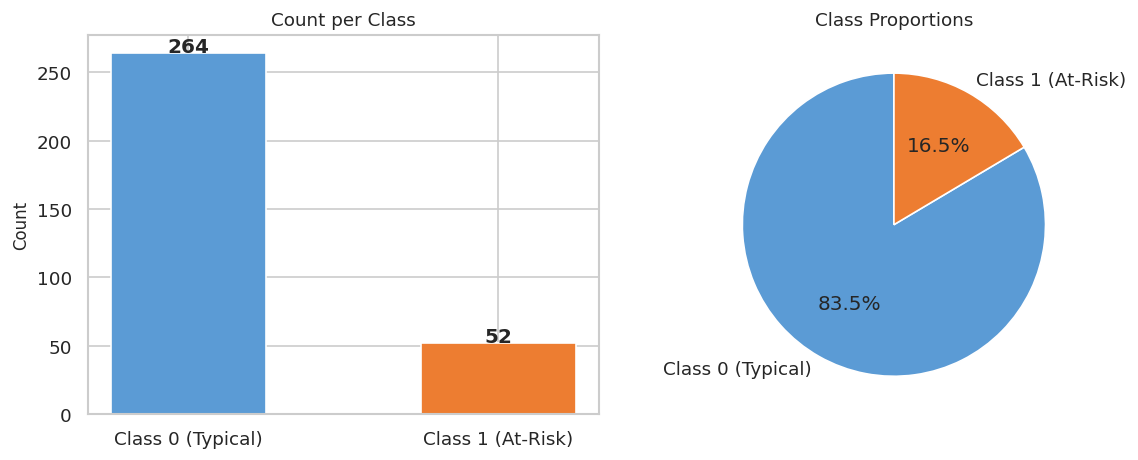

In [7]:
show_label_distribution_plot(df_raw, 'raw')

#### 1.2.4 Feature Distribution

To analyze the underlying distribution of the independent variables, a grid of overlapping histograms overlaid with Kernel Density Estimate (KDE) curves is generated, stratified by class. A specific technical consideration in this visualization involves the handling of the `[-99]` sentinel values: they are purposefully retained in the histograms to visually represent the scope of missing data, but are dynamically excluded from the KDE calculations to prevent significant distortion of the probability density curves. This approach ensures an accurate visual assessment of feature separability, class overlap, and the presence of distribution outliers prior to formal dataset normalization.

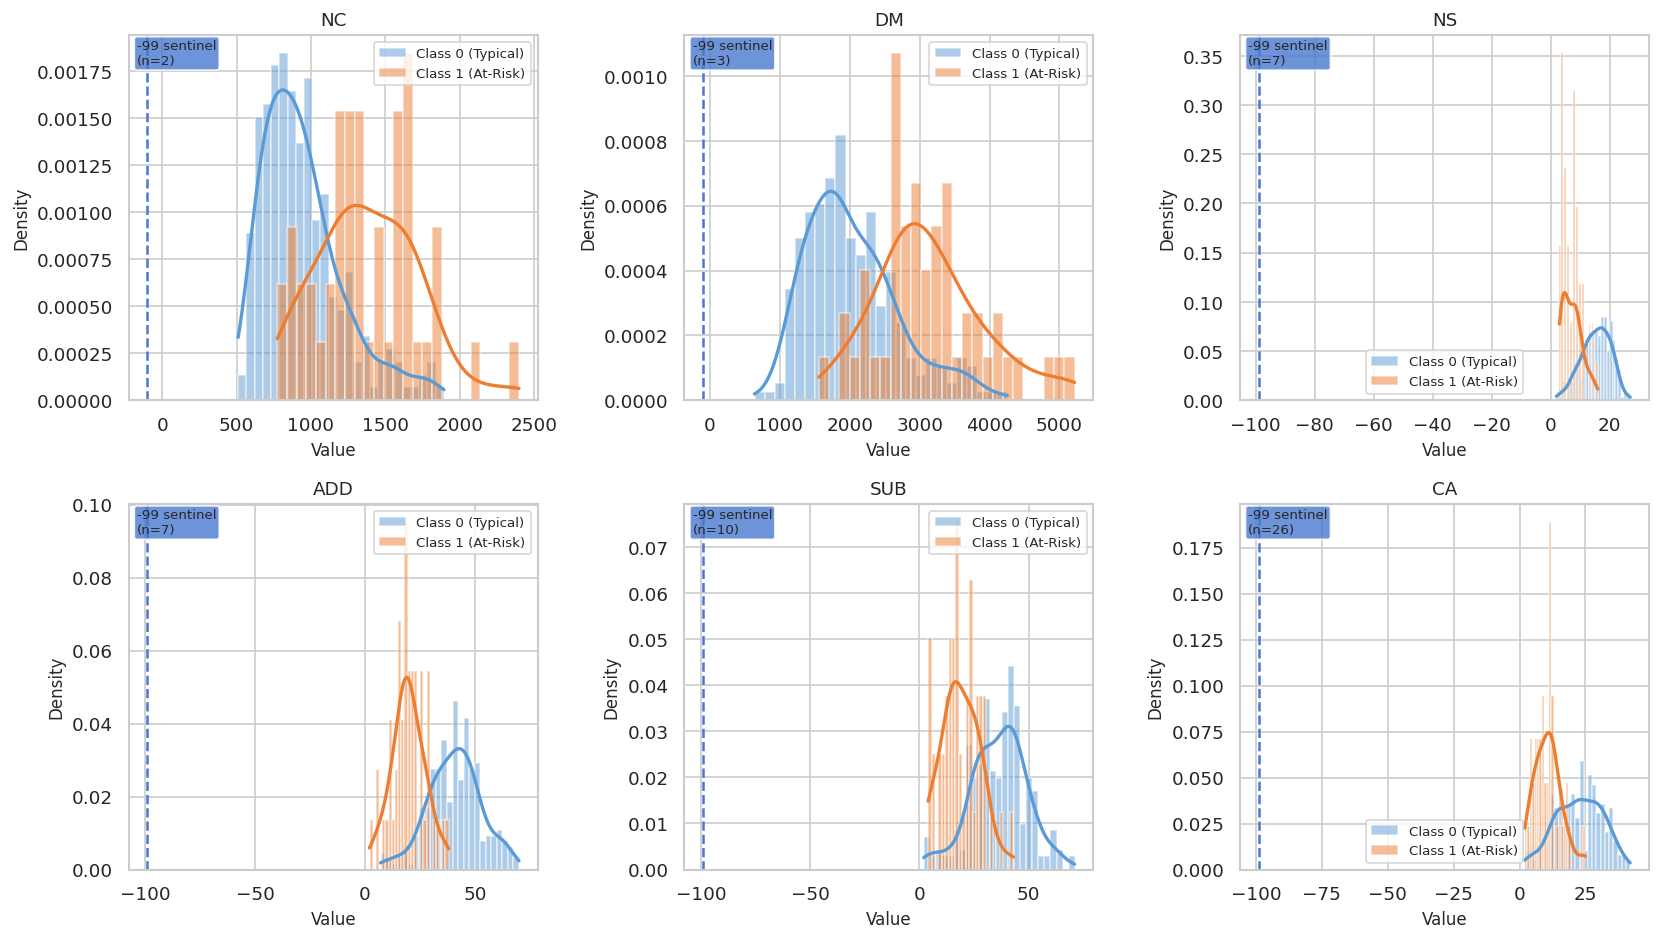

In [8]:
show_feature_distribution_plot(df_raw, 'raw', FEATURE_COLUMNS, DEFAULT_MISSING_VALUES)

#### 1.2.5 Feature x Class Outliers

This section utilizes boxplots to conduct a class-stratified analysis of feature dispersion and central tendencies. By partitioning the underlying data by the target label, we can visually assess the interquartile ranges (IQR) and reliably identify extreme outliers specific to each cohort. This stratified inspection is computationally crucial: because 'At-Risk' students intrinsically exhibit atypical scoring patterns, what might appear as a severe outlier on a global scale could actually represent a valid diagnostic signal within the minority class. Understanding these class-specific variances directly informs the localized, per-class IQR clipping strategy that will be implemented during the subsequent data cleaning phase.

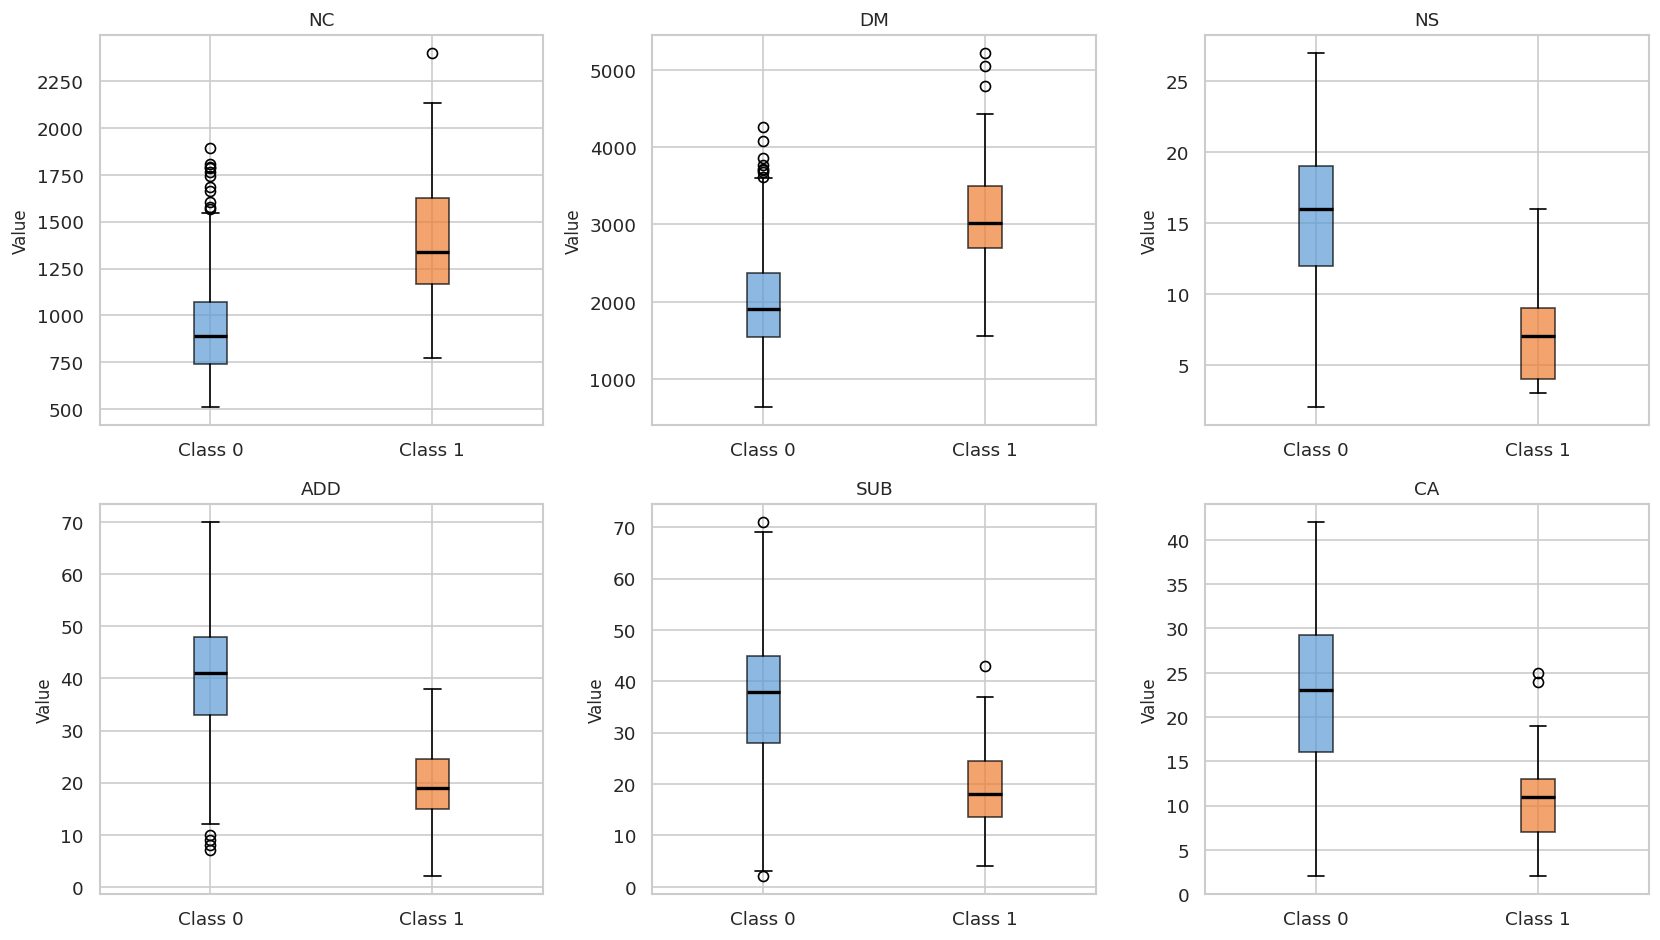

In [9]:
show_feature_class_outliers(df_raw, 'raw', FEATURE_COLUMNS)

#### 1.2.6 Correlation Matrix

In this section, a pairwise Pearson correlation matrix is generated to quantify the collinearity and linear relationships among the independent features. To contextualize these interactions within the dataset's domain, the matrix is visually partitioned to highlight two validated theoretical constructs: Number Processing (`NC`, `DM`) and Arithmetic Fluency (`NS`, `ADD`, `SUB`, `CA`). 

A critical technical observation during this stage of the EDA is the presence of strong negative correlations crossing between these two feature groups. While computationally this might initially suggest a data inversion error or scaling anomaly, it is absolutely structurally sound. The Number Processing variables act as efficiency indices (reaction time divided by accuracy, meaning a higher score indicates worse performance), whereas the Arithmetic Fluency variables are raw correct counts (where a higher score indicates better performance). Explicitly mapping and verifying this expected inverse relationship serves as a crucial sanity check, confirming the structural integrity of our diagnostic metrics before applying any predictive algorithms.

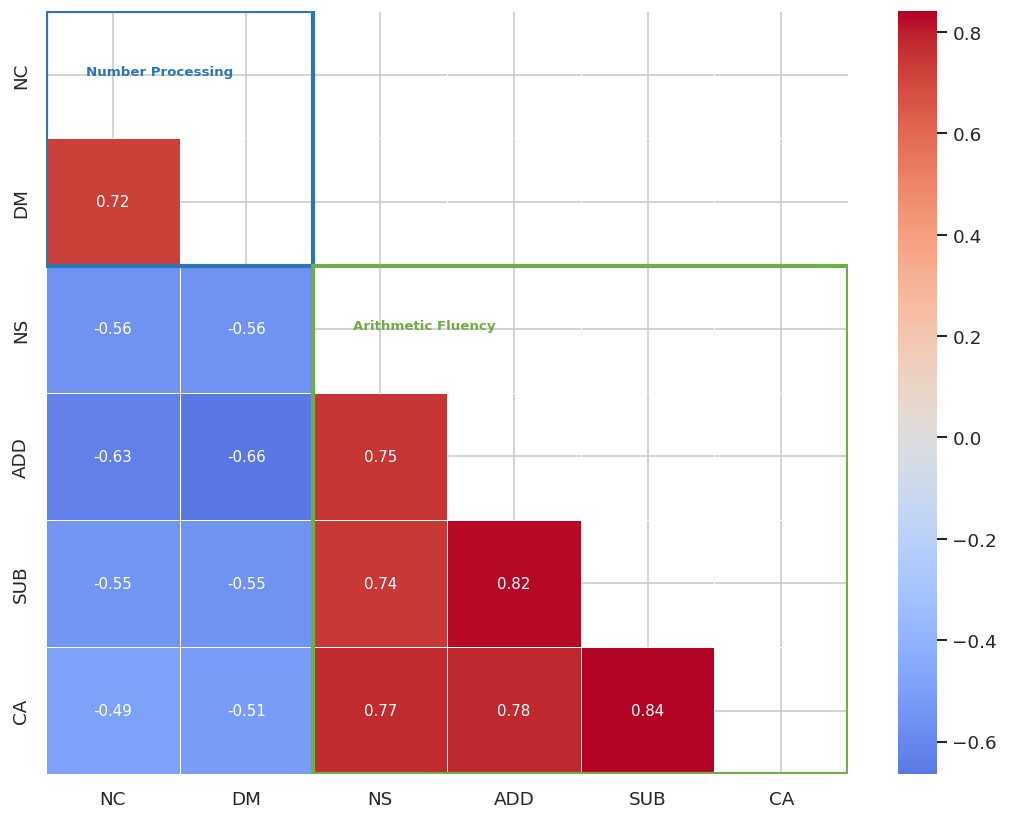

In [10]:
show_correlation_matrix(df_raw, 'raw', NUMBER_PROCESSING, ARITHMETIC_FLUENCY)

#### 1.2.7 Pairplot

To further investigate the multidimensional feature space prior to dataset normalization, this cell generates a pairwise scatter plot matrix overlaid with class-specific color mappings. This visualization provides a comprehensive view of both univariate distributions—via Kernel Density Estimates on the principal diagonal—and bivariate relationships across all independent variables. 

The variables are intentionally ordered to group the Number Processing metrics (`NC`, `DM`) alongside the Arithmetic Fluency metrics (`NS`, `ADD`, `SUB`, `CA`). By organizing the grid according to this theoretical two-factor structure, we can visually validate the clustering behaviors and inverse scaling relationships identified in the correlation matrix. From a machine learning perspective, examining these 2D projections is highly valuable; it helps identify localized regions of class separability, multivariate outliers, and non-linear feature interactions that decision tree algorithms, such as C4.5, are specifically optimized to exploit.

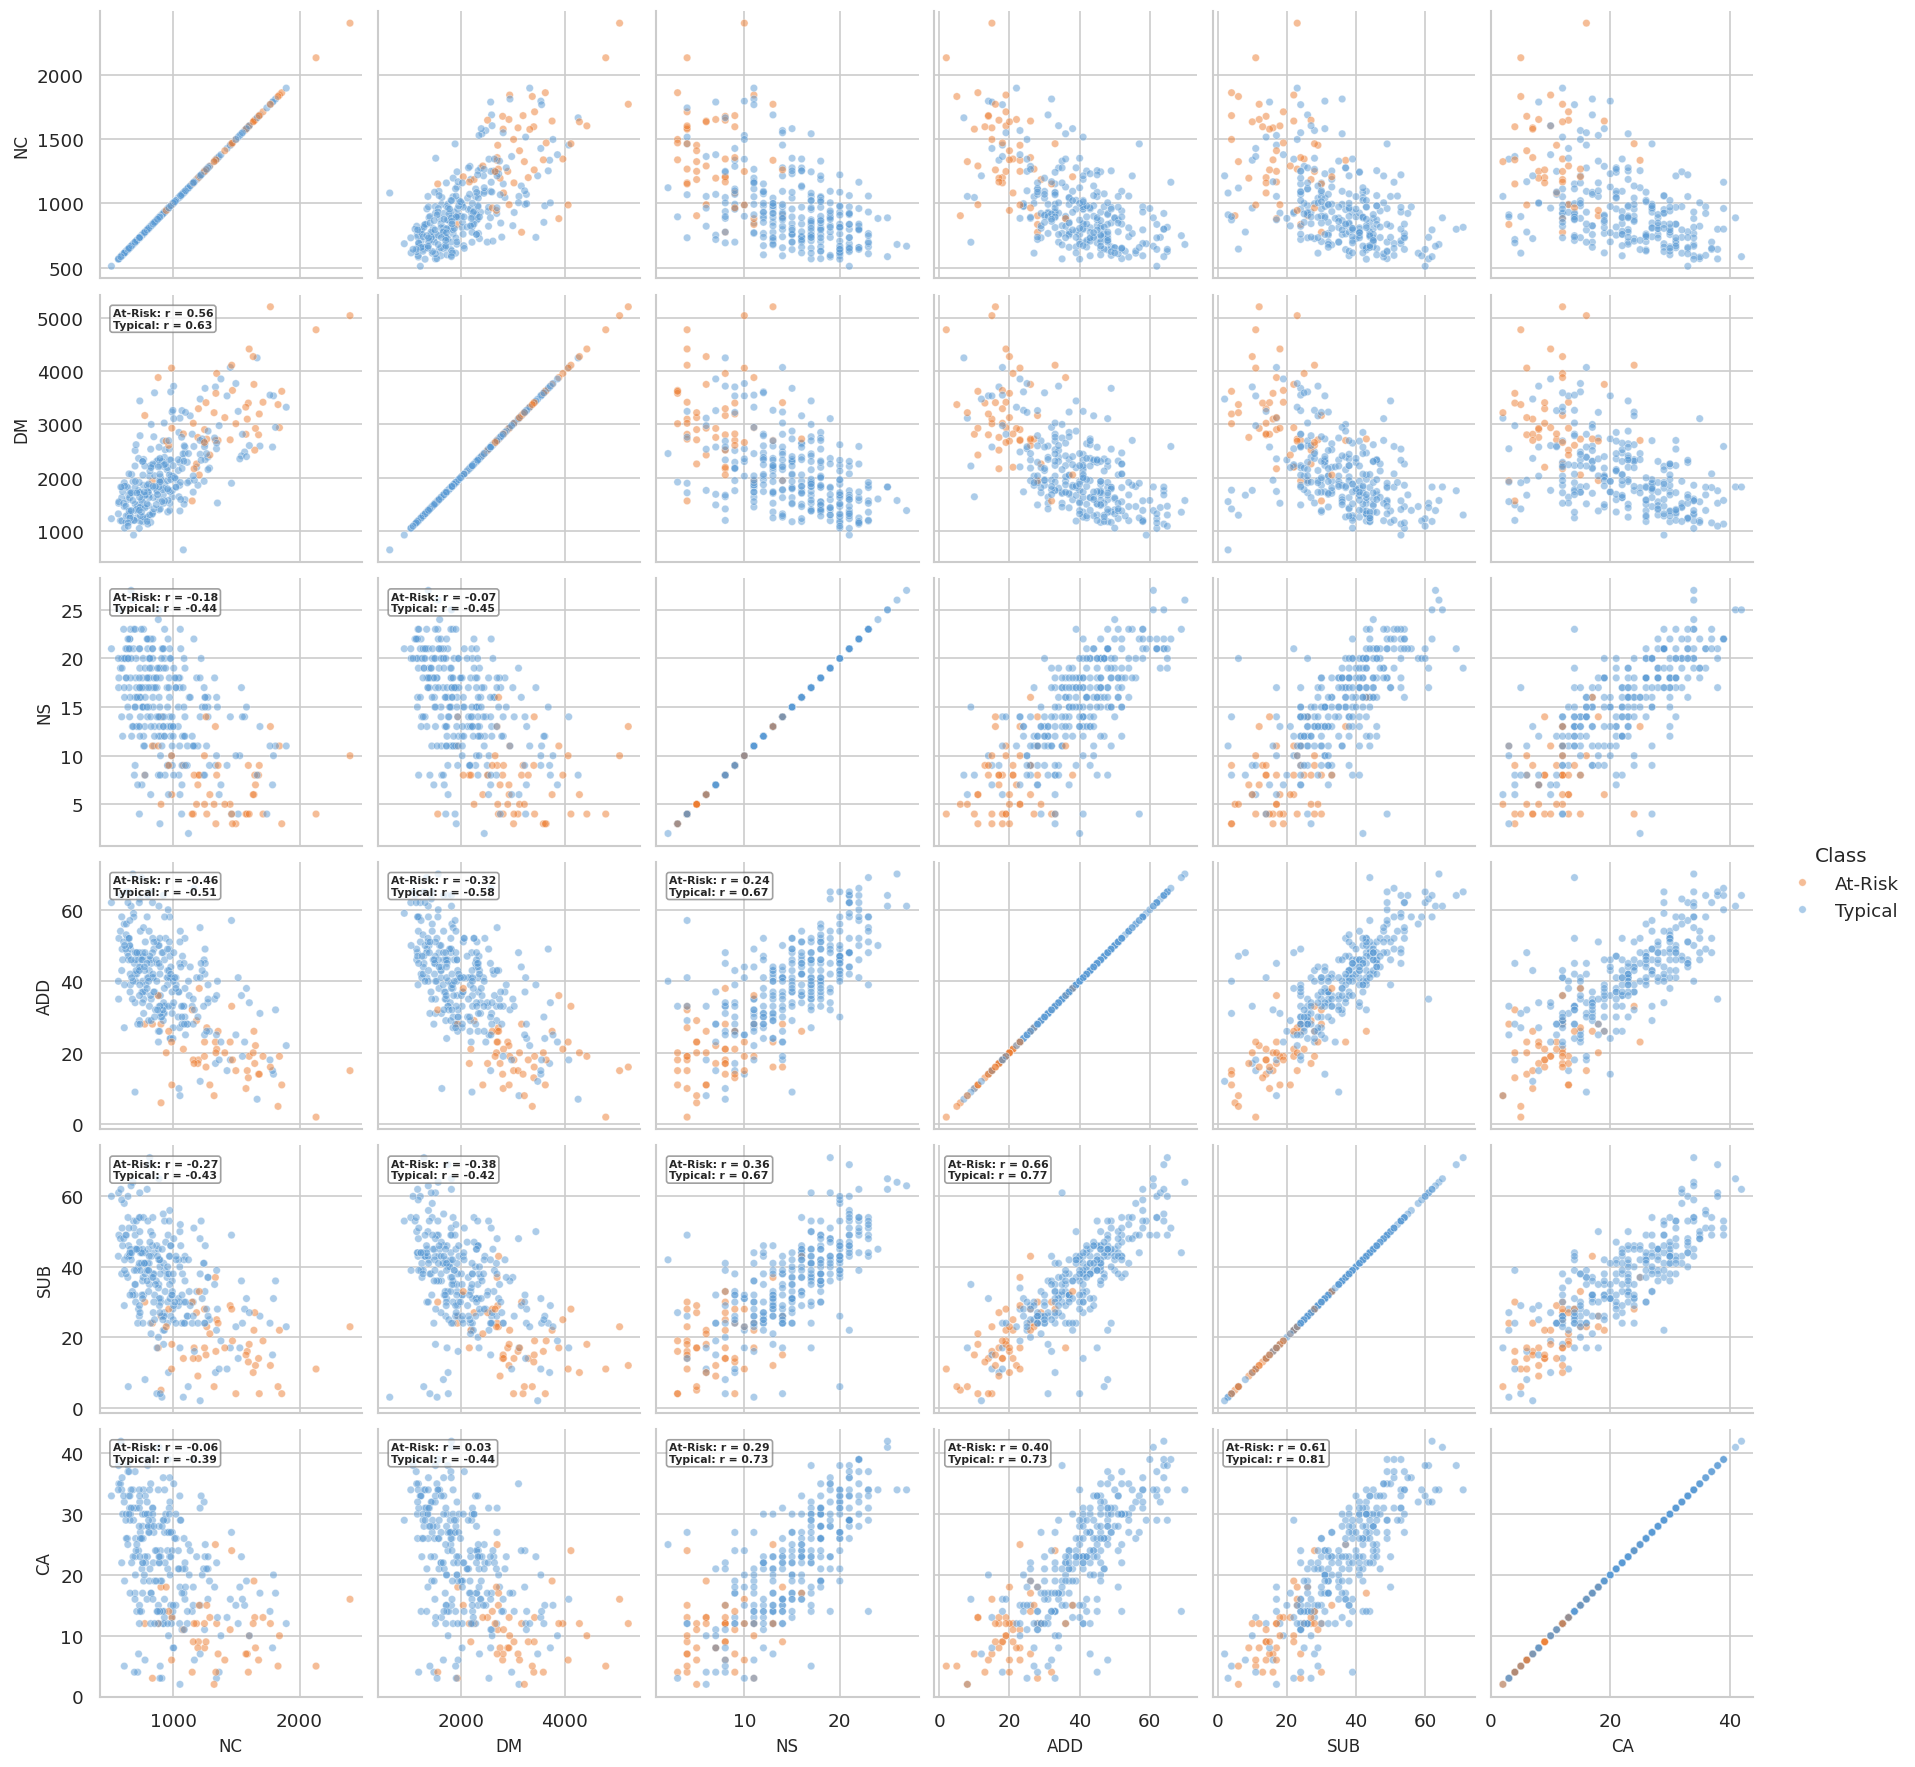

In [11]:
show_pairplot(df_raw, 'raw', FEATURE_COLUMNS)

#### Validator Note: Data Preprocessing and Leakage Control

For validation purposes, the critical methodological requirement in this section is that data cleaning and preprocessing should not use information from validation or test partitions. The intended sequence is:

1. Construct the label.
2. Remove RMAT from predictive features.
3. Split the dataset into training, validation, and test partitions.
4. Fit preprocessing parameters using the training set only.
5. Apply the fitted preprocessing rules unchanged to validation and test data.

This protects the evaluation design from data leakage. In particular, imputation medians, missingness handling rules, and clipping bounds should be estimated only from the training partition.


### 1.3 Dataset Cleanup

#### 1.3.1 Missing Values Handling

##### Validator Note: Missingness Assumptions

Missing, invalid, or sentinel values are assumed to reflect incomplete task-level observations rather than additional diagnostic labels. Missingness indicators are retained because the presence of incomplete task performance may contain useful screening information.

Imputation is used to make the numerical feature matrix model-ready. The imputation values should come from training-set feature medians only, rather than from class-specific medians or full-dataset medians. This avoids using outcome information or unseen validation/test distributional information during preprocessing.


##### 1.3.1.1 Replace Missing with Nan

In [12]:
df_base = df_raw.copy()
df_base = df_base.replace(DEFAULT_MISSING_VALUES, np.nan)
print(f"Cells with values {DEFAULT_MISSING_VALUES} were replaced with nan")

Cells with values [-99] were replaced with nan


##### 1.3.1.2 Ensure Numerical Safety

In [13]:
for col in df_base.columns:
    if col == 'Label':
        continue
    df_base.loc[df_base[col] < 0, col] = np.nan

print('NaN counts after sentinel/negative removal:')
print(df_base[FEATURE_COLUMNS].isna().sum())

# Split BEFORE any imputation/clipping to avoid leakage
df_train_raw, df_temp_raw = train_test_split(
    df_base, test_size=0.30, stratify=df_base['Label'], random_state=SEED
 )
df_val_raw, df_test_raw = train_test_split(
    df_temp_raw, test_size=0.50, stratify=df_temp_raw['Label'], random_state=SEED
 )

print('\nData split (70 / 15 / 15):')
print(f'  Train      : {len(df_train_raw):>4}')
print(f'  Validation : {len(df_val_raw):>4}')
print(f'  Test       : {len(df_test_raw):>4}')

NaN counts after sentinel/negative removal:
NC      2
DM      3
NS      7
ADD     7
SUB    10
CA     26
dtype: int64

Data split (70 / 15 / 15):
  Train      :  221
  Validation :   47
  Test       :   48


##### 1.3.1.3 Analyse Missingness by Class (Training Only)

Since missing values represent absent/incomplete students (not random), we first check whether missingness is disproportionate in the At-Risk class. This analysis is computed on the training split only to avoid leakage into validation/test.

=== Missing counts per feature per class (train only) ===
             NC  DM  NS  ADD  SUB  CA
Typical (0)   0   1   3    4    6  14
At-Risk (1)   2   1   3    1    1   4

=== Missing rate (%) per feature per class (train only) ===
              NC   DM   NS  ADD  SUB    CA
Typical (0)  0.0  0.5  1.6  2.2  3.2   7.6
At-Risk (1)  5.6  2.8  8.3  2.8  2.8  11.1

Saving missing rates (train/val/test/all) in one file...
Done saving missing rates to outputs/logs_and_metrics/missing_rates.json.


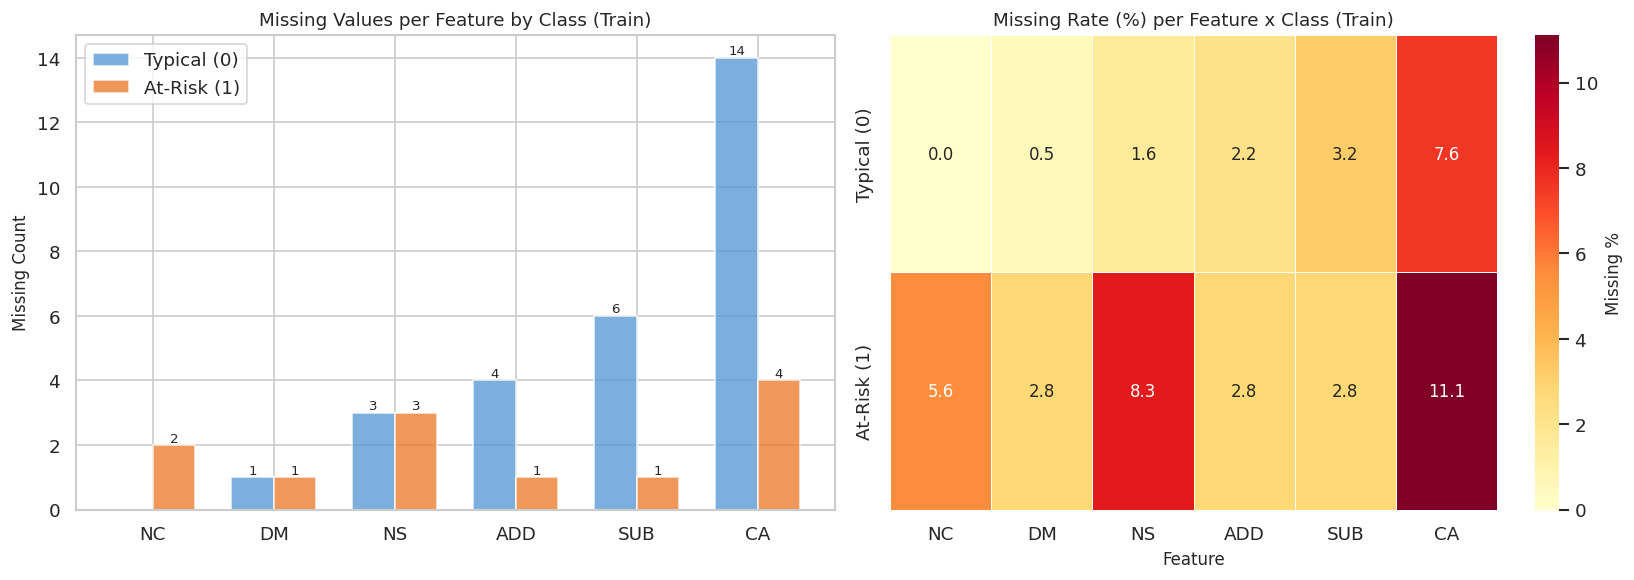


40 missing values found in Train.


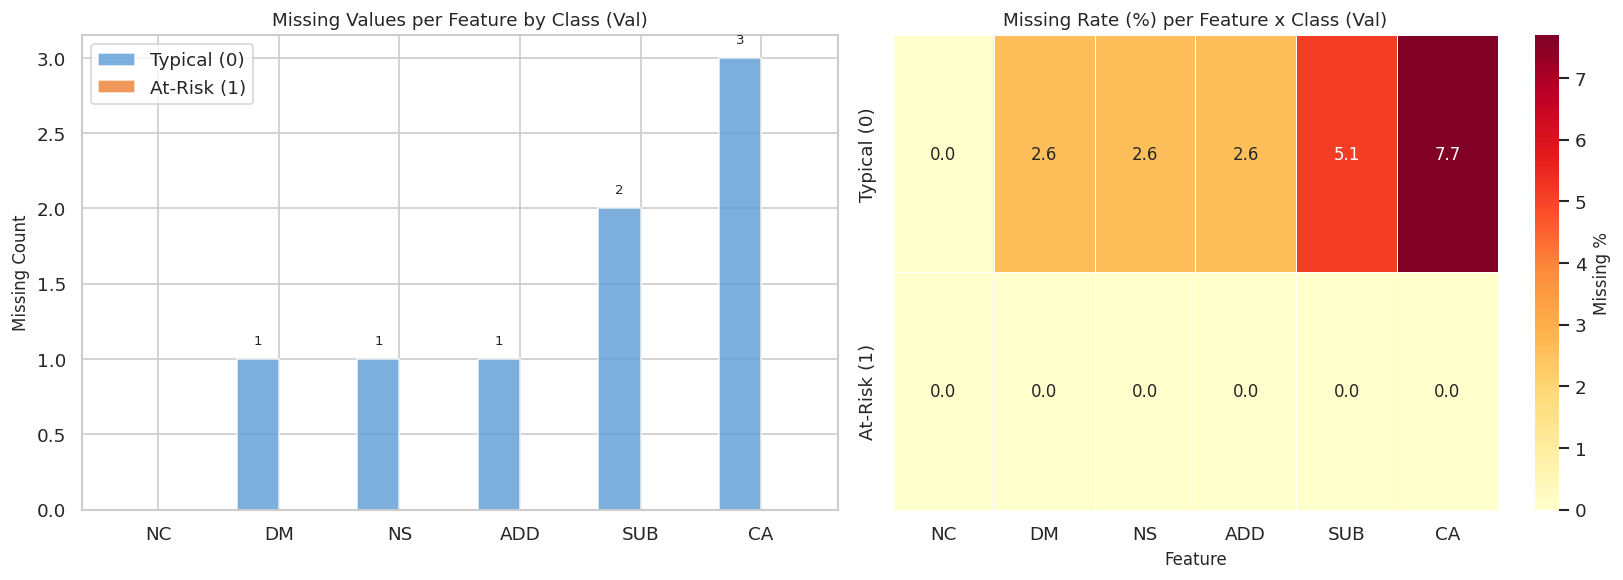


8 missing values found in Val.


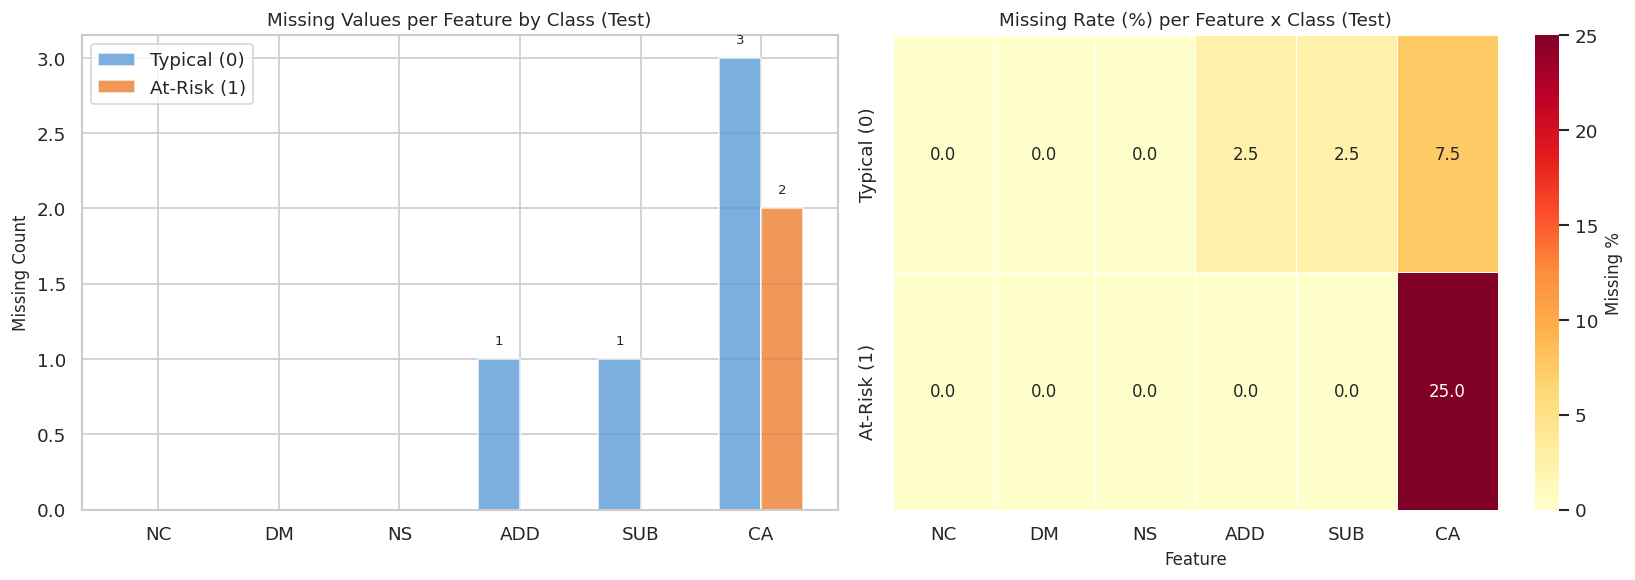


7 missing values found in Test.


In [14]:
print("=== Missing counts per feature per class (train only) ===")
missing_by_class = _missing_counts_by_label(df_train_raw, FEATURE_COLUMNS)

# Display-friendly copy
missing_by_class_display = missing_by_class.copy()
missing_by_class_display.index = ['Typical (0)', 'At-Risk (1)']
print(missing_by_class_display)

print("\n=== Missing rate (%) per feature per class (train only) ===")
missing_rate = _missing_rate_by_label(df_train_raw, FEATURE_COLUMNS)

# Display-friendly copy
missing_rate_display = missing_rate.copy()
missing_rate_display.index = ['Typical (0)', 'At-Risk (1)']
print(missing_rate_display)

MISSING_RATES = _rates_to_dict(missing_rate)

# Save train/val/test/all in ONE json file
missing_rates_all = {
    'train': _rates_to_dict(_missing_rate_by_label(df_train_raw, FEATURE_COLUMNS)),
    'val':   _rates_to_dict(_missing_rate_by_label(df_val_raw, FEATURE_COLUMNS)),
    'test':  _rates_to_dict(_missing_rate_by_label(df_test_raw, FEATURE_COLUMNS)),
    'all':   _rates_to_dict(_missing_rate_by_label(df_base, FEATURE_COLUMNS)),
}

print("\nSaving missing rates (train/val/test/all) in one file...")
MISSING_RATES_SAVEFILE = LOGS_OUTPUTS / "missing_rates.json"
with open(MISSING_RATES_SAVEFILE, "w") as f:
    json.dump(missing_rates_all, f, indent=4)
print(F"Done saving missing rates to {MISSING_RATES_SAVEFILE.relative_to(ROOT_DIR)}.")

# Save graphs for each split
_plot_missingness(df_train_raw, 'Train')
_plot_missingness(df_val_raw, 'Val')
_plot_missingness(df_test_raw, 'Test')

##### 1.3.1.4 Create Missingness Indicator Flags (Split-Safe)

For each feature we add a binary `{feature}_incomplete` flag (1 = absent/did not finish, 0 = completed). Flags are created on each split separately before imputation to preserve the absence signal without leakage.


Students with any incompleteness (train): 25
  Typical: 17
  At-Risk: 8

Flag columns added: ['NC_incomplete', 'DM_incomplete', 'NS_incomplete', 'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete']


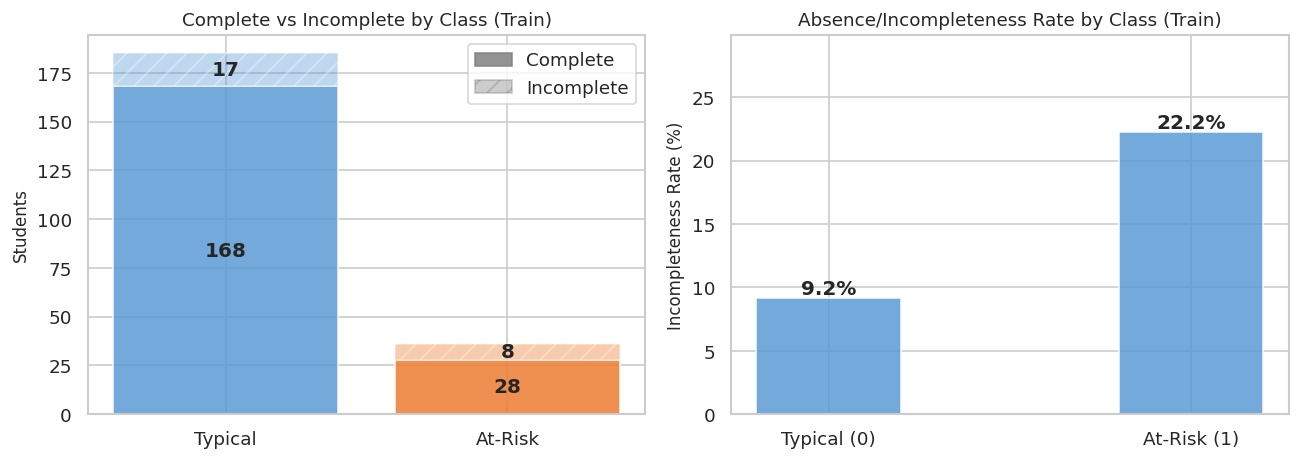

In [15]:
flag_cols = [f'{col}_incomplete' for col in FEATURE_COLUMNS]

df_train_flagged = add_missing_flags(df_train_raw, FEATURE_COLUMNS)
df_val_flagged   = add_missing_flags(df_val_raw, FEATURE_COLUMNS)
df_test_flagged  = add_missing_flags(df_test_raw, FEATURE_COLUMNS)

# Calculate students with any missing features (train only)
any_missing_mask = df_train_flagged[FEATURE_COLUMNS].isna().any(axis=1)

print(f'\nStudents with any incompleteness (train): {any_missing_mask.sum()}')
print(f'  Typical: {any_missing_mask[df_train_flagged["Label"]==0].sum()}')
print(f'  At-Risk: {any_missing_mask[df_train_flagged["Label"]==1].sum()}')
print(f'\nFlag columns added: {flag_cols}')

if any_missing_mask.sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Stacked bar: incomplete vs complete per class
    ax = axes[0]
    for lbl, color, name in [(0, TYPICAL_COLOR, 'Typical'), (1, AT_RIST_COLOR, 'At-Risk')]:
        class_mask = df_train_flagged['Label'] == lbl
        n_inc  = any_missing_mask[class_mask].sum()
        n_comp = class_mask.sum() - n_inc

        ax.bar(name, n_comp, color=color, alpha=0.85)
        ax.bar(name, n_inc,  bottom=n_comp, color=color, alpha=0.4, hatch='//')

        if n_comp > 0:
            ax.text(name, n_comp / 2, str(n_comp), ha='center', va='center', fontweight='bold')
        if n_inc > 0:
            ax.text(name, n_comp + (n_inc / 2), str(n_inc), ha='center', va='center', fontweight='bold')

    ax.set_ylabel('Students')
    ax.set_title('Complete vs Incomplete by Class (Train)')
    handles = [
        plt.Rectangle((0, 0), 1, 1, color='grey', alpha=0.85, label='Complete'),
        plt.Rectangle((0, 0), 1, 1, color='grey', alpha=0.4, hatch='//', label='Incomplete')
    ]
    ax.legend(handles=handles)

    # Incompleteness rate per class
    ax2 = axes[1]
    rates = [
        any_missing_mask[df_train_flagged['Label'] == 0].mean() * 100,
        any_missing_mask[df_train_flagged['Label'] == 1].mean() * 100
    ]
    bars = ax2.bar(['Typical (0)', 'At-Risk (1)'], rates,
                   color=[TYPICAL_COLOR, TYPICAL_COLOR], alpha=0.85, width=0.4)
    ax2.set_ylabel('Incompleteness Rate (%)')
    ax2.set_title('Absence/Incompleteness Rate by Class (Train)')
    ax2.set_ylim(0, max(rates) * 1.3 + 1)
    for bar, rate in zip(bars, rates):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{rate:.1f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(FIGURES_OUTPUTS / 'train_incomplete_per_class.png')
    plt.show()
else:
    print('No missing values in training split — incompleteness chart skipped.')

#### 1.3.3 Missing Values Cleanup

##### 1.3.3.1 Impute NaNs with Training Medians

With the informative absence signals preserved as binary flags, the dataset must now be numerically complete before modeling. Imputation uses **training-only** medians (global, not per class), then applies those fixed values to validation, test, and deployment data to avoid leakage and label dependence.

In [16]:
train_medians = df_train_flagged[FEATURE_COLUMNS].median()
train_medians = train_medians.fillna(0)

df_train_imputed = df_train_flagged.copy()
df_val_imputed   = df_val_flagged.copy()
df_test_imputed  = df_test_flagged.copy()

for df_tmp in (df_train_imputed, df_val_imputed, df_test_imputed):
    df_tmp[FEATURE_COLUMNS] = df_tmp[FEATURE_COLUMNS].fillna(train_medians)

##### 1.3.3.2 IQR Clipping with Training Bounds

Clipping uses IQR bounds computed **only from the training split**, then applies those fixed bounds to train, validation, test, and deployment data. This avoids leakage and label dependence.

In [17]:
def compute_iqr_bounds(df: pd.DataFrame, feature_columns: list, whisker: float = 1.5) -> dict:
    bounds = {}
    for col in feature_columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - whisker * iqr
        upper = q3 + whisker * iqr
        bounds[col] = (lower, upper)
    return bounds

def apply_clip(df: pd.DataFrame, bounds: dict) -> pd.DataFrame:
    df_out = df.copy()
    for col, (lo, hi) in bounds.items():
        df_out[col] = df_out[col].clip(lo, hi)
    return df_out

clip_bounds = compute_iqr_bounds(df_train_flagged, FEATURE_COLUMNS)

df_train_clean = apply_clip(df_train_imputed, clip_bounds).reset_index(drop=True)
df_val_clean   = apply_clip(df_val_imputed, clip_bounds).reset_index(drop=True)
df_test_clean  = apply_clip(df_test_imputed, clip_bounds).reset_index(drop=True)

# Full cleaned dataset for descriptive analysis (train-fitted preprocessing)
df_clean = pd.concat([df_train_clean, df_val_clean, df_test_clean], ignore_index=True)

print('Training-derived clipping bounds applied:')
for col, (lo, hi) in clip_bounds.items():
    print(f'  {col}: [{lo:.2f}, {hi:.2f}]')

Training-derived clipping bounds applied:
  NC: [110.07, 1837.53]
  DM: [84.43, 4196.58]
  NS: [-2.00, 30.00]
  ADD: [-0.50, 75.50]
  SUB: [-3.88, 71.12]
  CA: [-8.50, 51.50]


### 1.4 After Cleaning Exploratory Dataset Analysis

#### 1.4.1 Dataset Exploration

In [18]:
print("=== Dataset Info ===")
print(df_clean.info())

print("\n=== Dataset Head ===")
print(df_clean.head())

print("\n=== Summary Statistics (raw) ===")
print(df_clean.describe().T.round(2))

print("\n=== Missing / Sentinel Values ===")
sentinel_mask = df_clean.isin(DEFAULT_MISSING_VALUES)
print(f"Cells equal to {DEFAULT_MISSING_VALUES}:", sentinel_mask.sum().sum())
print(sentinel_mask.sum()[sentinel_mask.sum() > 0])

print("\n=== Label Distribution ===")
print(df_clean['Label'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316 entries, 0 to 315
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NC              316 non-null    float64
 1   DM              316 non-null    float64
 2   NS              316 non-null    float64
 3   ADD             316 non-null    float64
 4   SUB             316 non-null    float64
 5   CA              316 non-null    float64
 6   Label           316 non-null    int64  
 7   NC_incomplete   316 non-null    int64  
 8   DM_incomplete   316 non-null    int64  
 9   NS_incomplete   316 non-null    int64  
 10  ADD_incomplete  316 non-null    int64  
 11  SUB_incomplete  316 non-null    int64  
 12  CA_incomplete   316 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 32.2 KB
None

=== Dataset Head ===
            NC           DM    NS   ADD   SUB    CA  Label  NC_incomplete  \
0   838.367347  2254.350000  22.0  52.0  54.

#### 1.4.2 Graphs

Feature Distribution


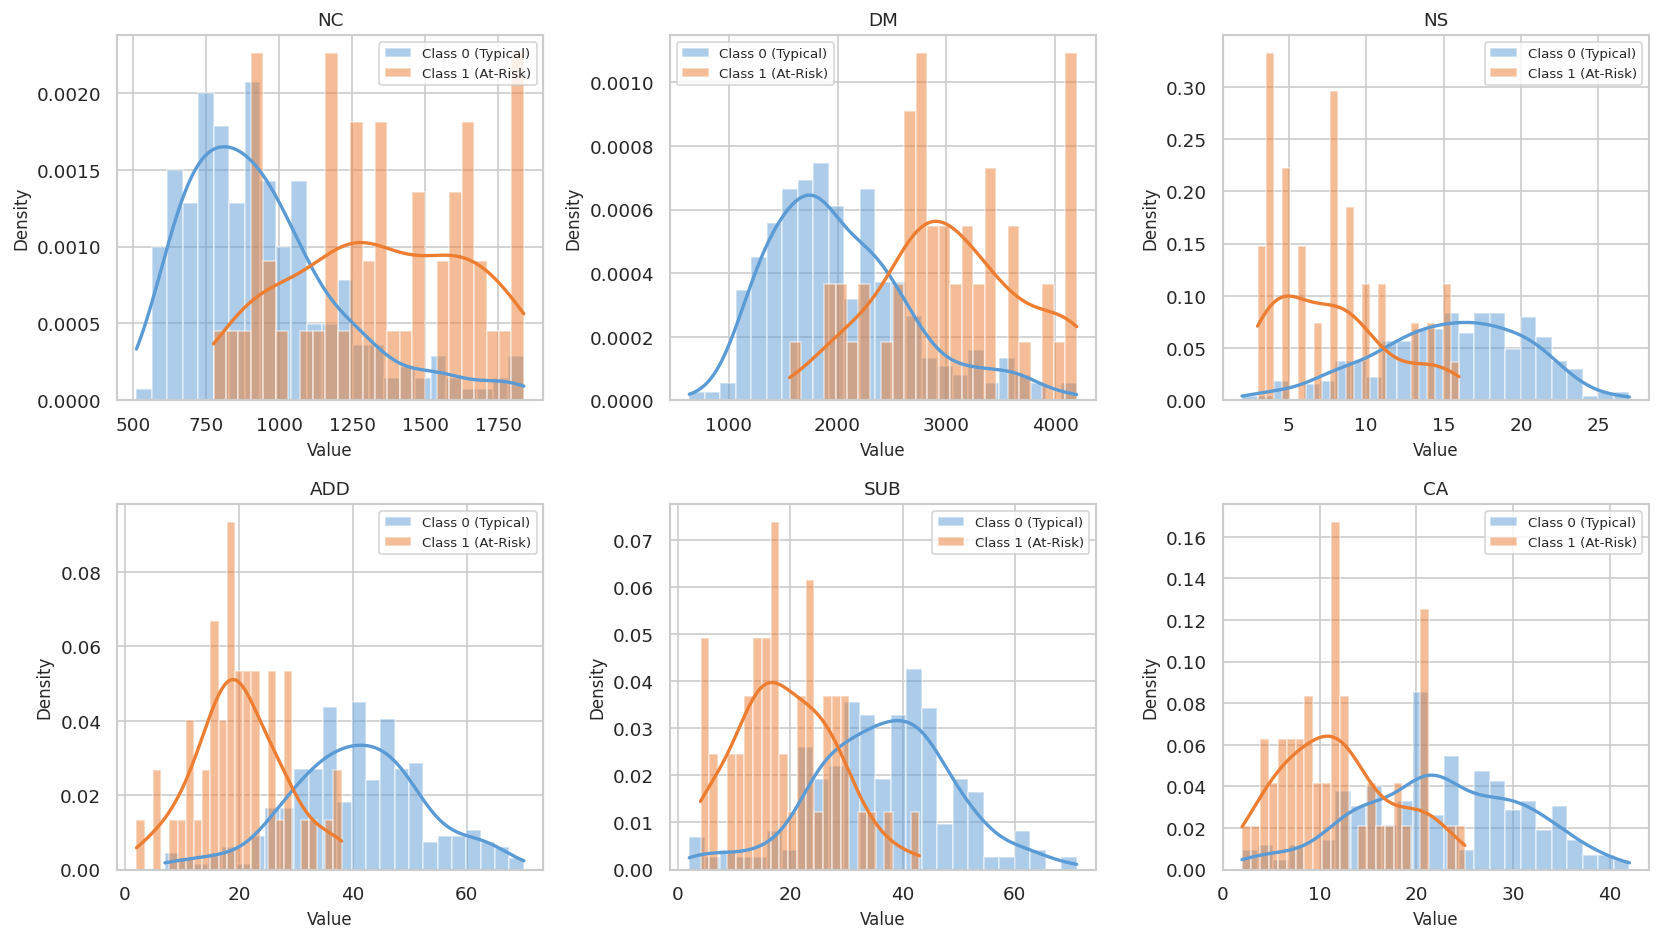

Feature Outliers


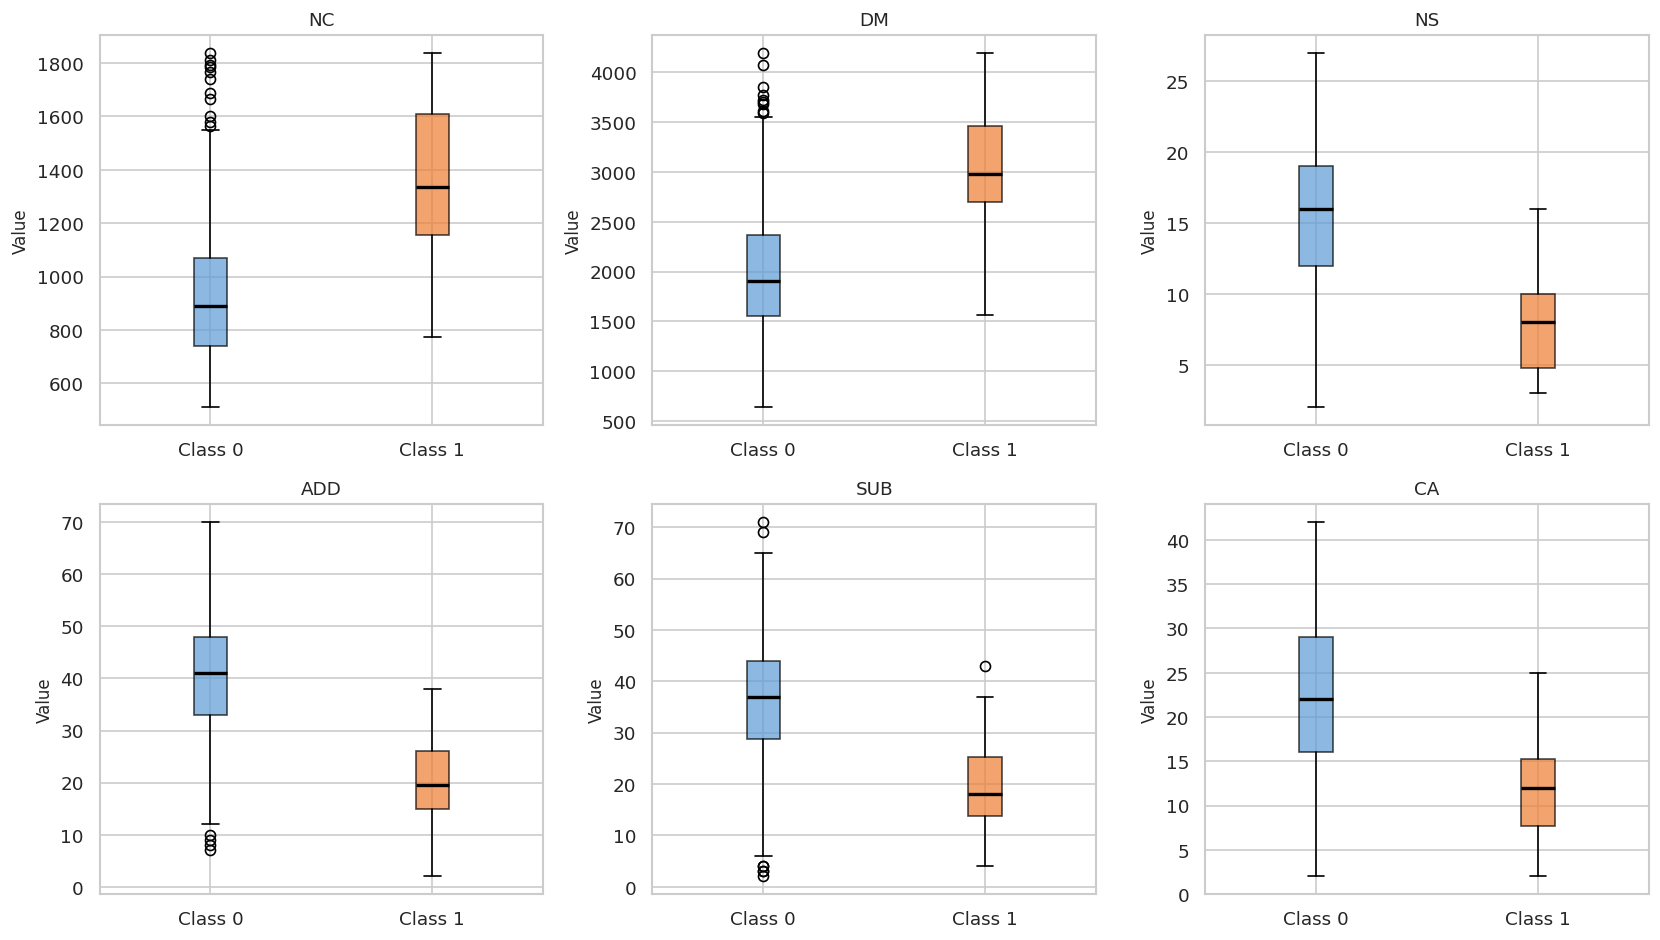

Correlation Matrix


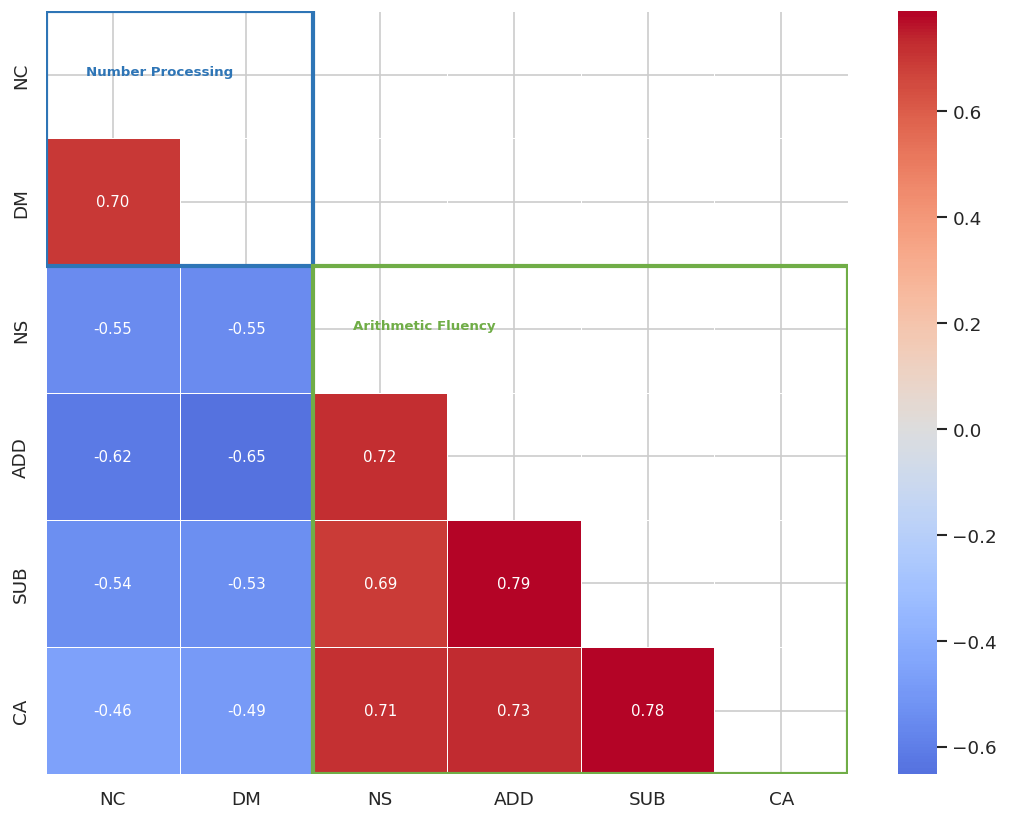

Pairplot


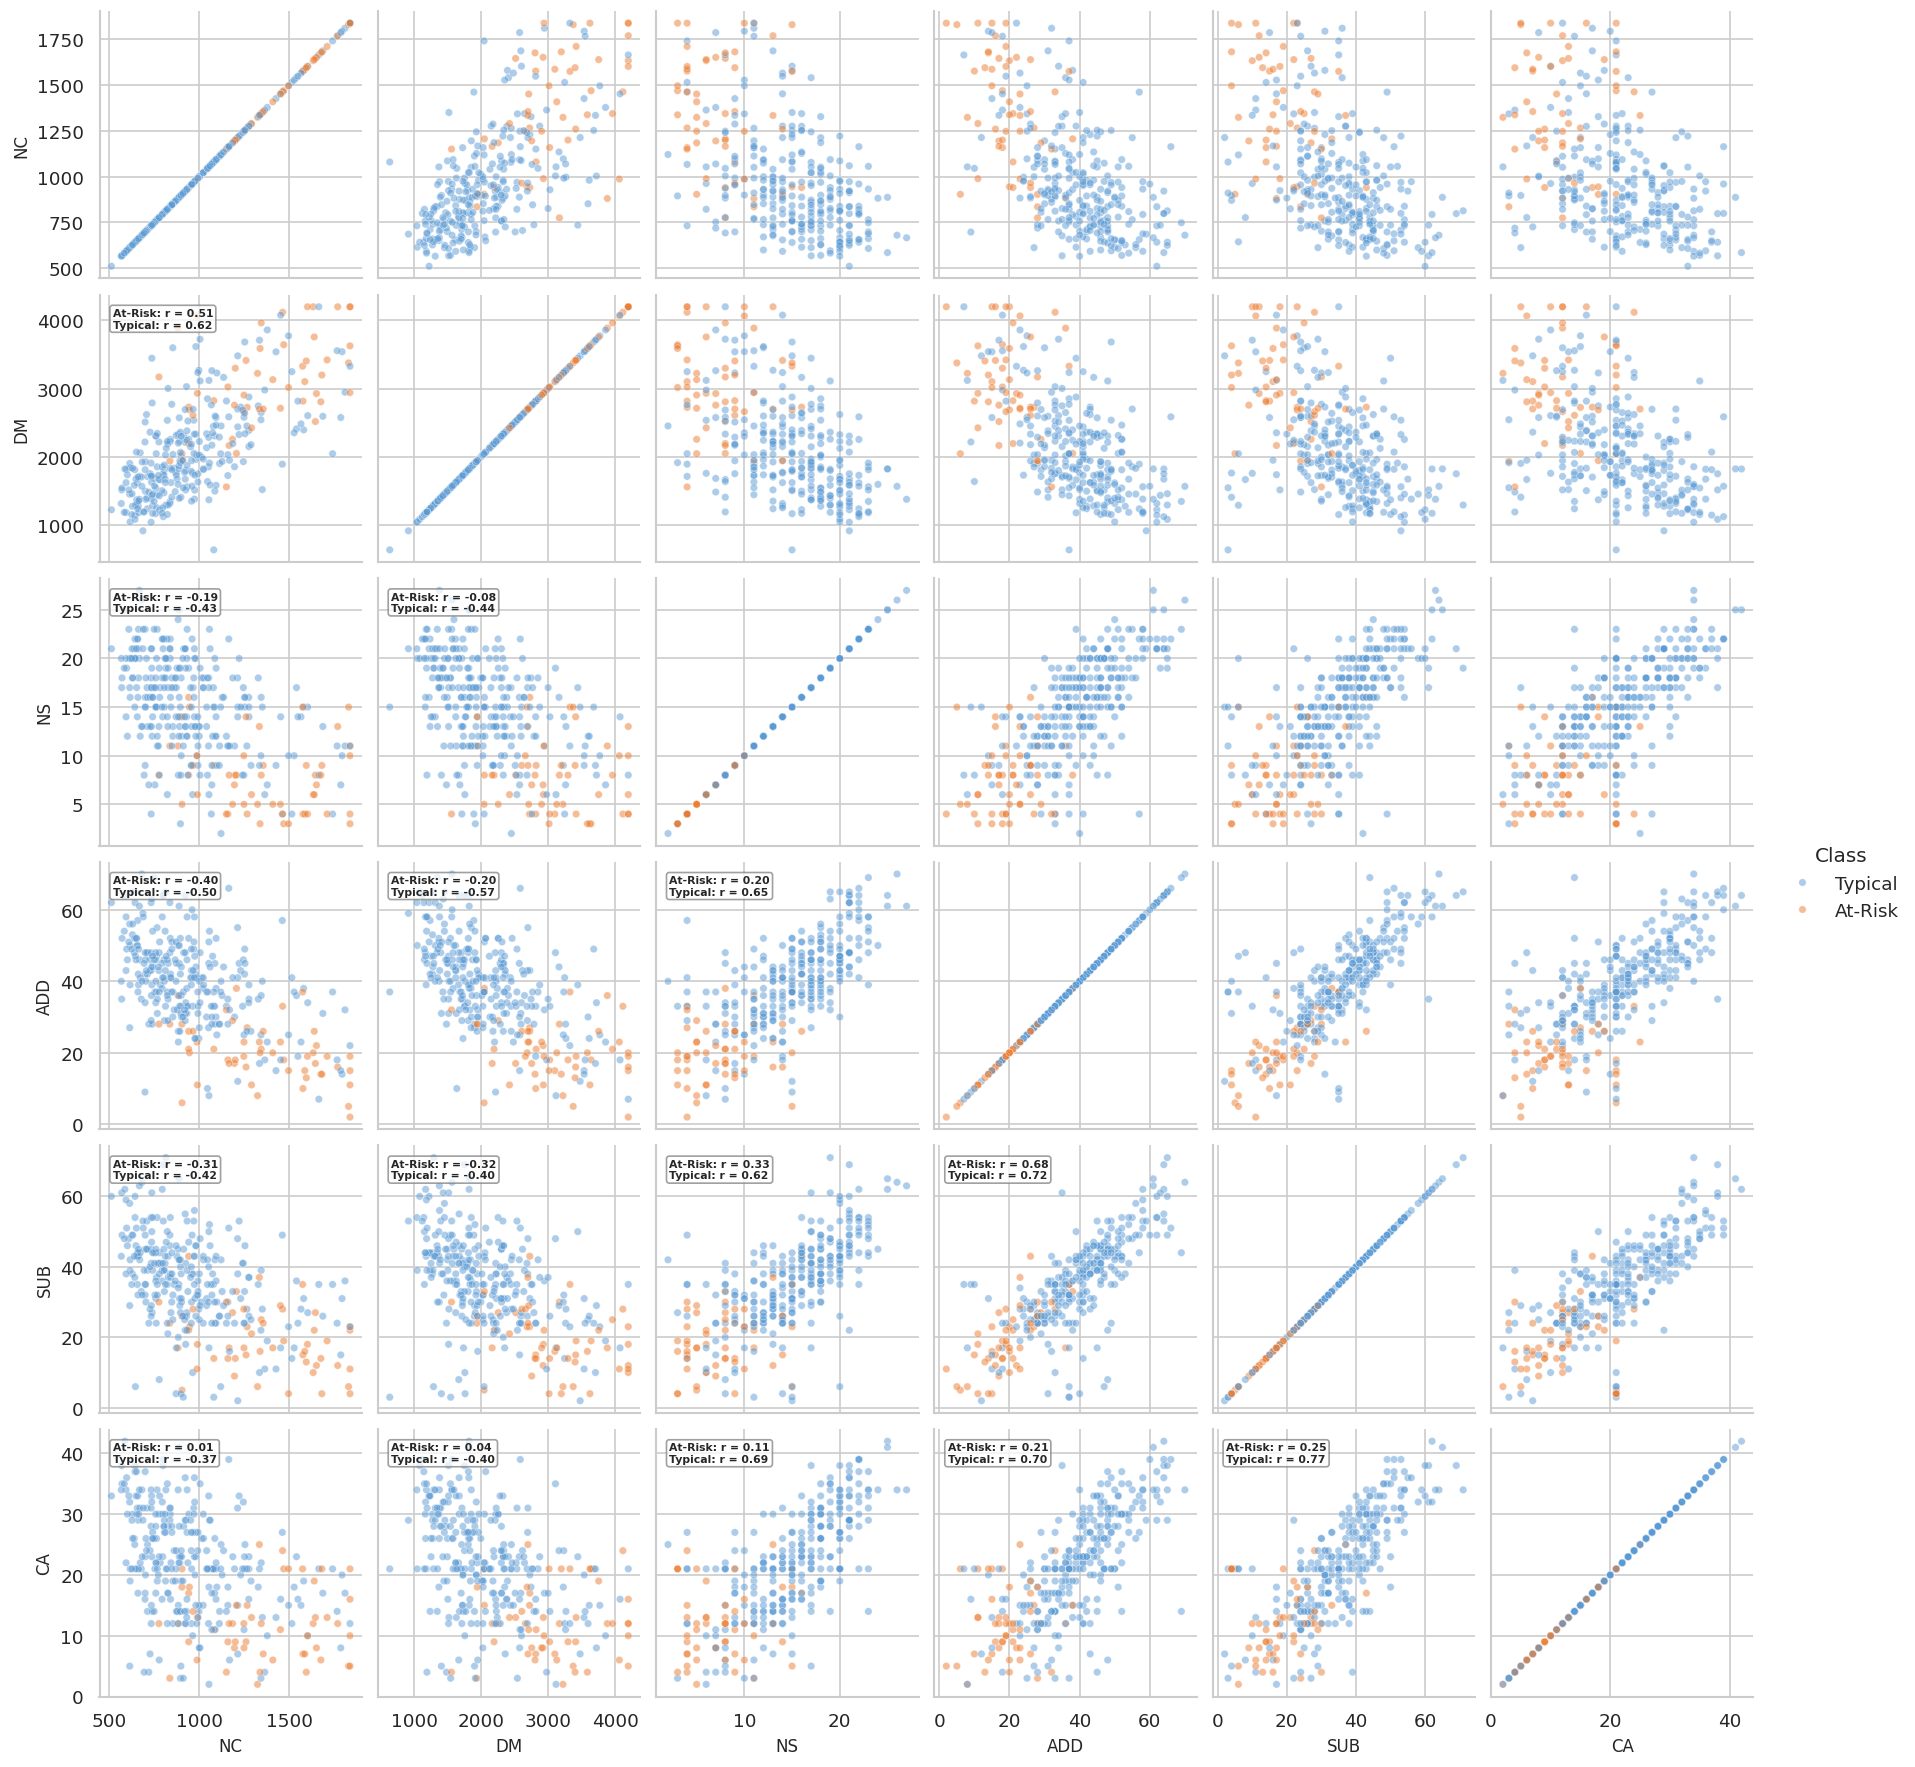

In [19]:
print("Feature Distribution")
show_feature_distribution_plot(df_clean, 'clean', FEATURE_COLUMNS, DEFAULT_MISSING_VALUES)

print("Feature Outliers")
show_feature_class_outliers(df_clean, 'clean', FEATURE_COLUMNS)

print("Correlation Matrix")
show_correlation_matrix(df_clean, 'clean', NUMBER_PROCESSING, ARITHMETIC_FLUENCY)

print("Pairplot")
show_pairplot(df_clean, 'clean', FEATURE_COLUMNS)

### 1.5 Before vs. After Comparison

#### 1.5.1 Numeric Comparison

In [20]:
rows = []
for col in FEATURE_COLUMNS:
    for label, dataset in [('RAW', df_raw), ('CLEAN', df_clean)]:
        s = dataset[col]
        rows.append({
            'Feature': col, 'Dataset': label,
            'Mean': s.mean(), 'Std': s.std(),
            'Min': s.min(), 'Max': s.max(),
            'NaN': s.isna().sum()
        })

comparison = pd.DataFrame(rows).set_index(['Feature', 'Dataset']).round(2)
comparison

Mean     Std     Min      Max  NaN
Feature Dataset                                       
NC      RAW      1005.45  336.81  -99.00  2399.14    0
        CLEAN    1009.07  315.40  510.82  1837.53    0
DM      RAW      2194.31  819.32  -99.00  5217.22    0
        CLEAN    2205.73  760.54  637.50  4196.58    0
NS      RAW        11.57   17.54  -99.00    27.00    0
        CLEAN      14.09    5.45    2.00    27.00    0
ADD     RAW        34.20   24.28  -99.00    70.00    0
        CLEAN      37.21   13.65    2.00    70.00    0
SUB     RAW        29.36   26.94  -99.00    71.00    0
        CLEAN      33.60   13.62    2.00    71.00    0
CA      RAW        10.82   34.13  -99.00    42.00    0
        CLEAN      20.70    8.94    2.00    42.00    0

In [21]:
df_clean.to_csv(PROCESSED_DATASET_DIR / 'cleaned_dataset.csv', index=False)
df_train_clean.to_csv(PROCESSED_DATASET_DIR / 'cleaned_train.csv', index=False)
df_val_clean.to_csv(PROCESSED_DATASET_DIR / 'cleaned_val.csv', index=False)
df_test_clean.to_csv(PROCESSED_DATASET_DIR / 'cleaned_test.csv', index=False)

print('Saved cleaned datasets (train-fitted preprocessing):')
print(f'  cleaned_dataset.csv  — {len(df_clean)} rows')
print(f'  cleaned_train.csv    — {len(df_train_clean)} rows')
print(f'  cleaned_val.csv      — {len(df_val_clean)} rows')
print(f'  cleaned_test.csv     — {len(df_test_clean)} rows')

Saved cleaned datasets (train-fitted preprocessing):
  cleaned_dataset.csv  — 316 rows
  cleaned_train.csv    — 221 rows
  cleaned_val.csv      — 47 rows
  cleaned_test.csv     — 48 rows


## Validator Note: Synthetic Augmentation Scope

Synthetic data generation is included only to address minority-class imbalance in the training set. The synthetic records are generated for the **At-Risk training class only** and are used only in the TRSTR training condition.

The validation and test sets remain fully real. No synthetic samples are added to validation or test evaluation. This design allows the notebook to compare whether synthetic augmentation improves At-Risk sensitivity without contaminating held-out evaluation results.


## 2.0 GAN-Based Synthetic Data Generation and Statistical Validation

These sections cover the use of CopulaGAN and CTGAN to synthetically augment the minority 'At-Risk' class within the strict confines of the training split, and the statistical validation of the resulting samples.

### 2.1 Synthetic Minority Oversampling — CopulaGAN + CTGAN


**Strategy:** GANs are trained strictly on the training minority class to prevent data leakage. Synthetic samples are injected **exclusively into the training split** — validation and test remain 100% real.

**Post-processing pipeline:**
1. Train CopulaGAN + CTGAN on raw features + BC (derived) so the model learns the ADD/SUB/CA joint structure.
2. Quantile-match each feature marginal on the full candidate pool.
3. KNN filter — retain the top 90th-percentile candidates closest to the real minority set.
4. Uniform sample to the required count (avoids centroid bias).
5. Hard assert: selected set must pass all distribution checks before proceeding.
6. Recompute all derived features deterministically from raw features.


#### Validator Note: GAN Training Assumptions

The GAN-based synthesizer should be trained only on real At-Risk samples from the training partition. It should not use At-Risk samples from the validation or test partitions.

The goal of synthetic generation is not to create artificial learner records for interpretation as real students. The goal is limited to controlled minority-class augmentation during model training. Therefore, the synthetic samples are judged by whether they are sufficiently similar for training augmentation, not by whether they are equivalent to real learner observations.


#### 2.1.1 Setup and Missing Rates Import

To preserve the structural integrity of the "absent student" signals identified during the exploratory data analysis, empirical missing rates must be explicitly imported from our output artifacts. Generating synthetic records that strictly reflect the same missing data distributions as the real 'At-Risk' cohort is an essential methodological requirement for maintaining diagnostic validity in the subsequent model.

In [22]:
GAN_FEATURES = FEATURE_COLUMNS + ['BC']

# Load empirical missing rates from file (per label, per feature).
MISSING_RATES = {}
try:
    with open(MISSING_RATES_SAVEFILE, encoding='utf-8') as file:
        loaded_rates = json.load(file)

    # Support both legacy schema (labels at top-level) and split-aware schema.
    if 'train' in loaded_rates:
        loaded_rates = loaded_rates['train']
    else:
        loaded_rates = loaded_rates

    # Normalize label keys to strings so downstream lookup is consistent.
    MISSING_RATES = {str(k): v for k, v in loaded_rates.items()}

    # Validate expected schema: labels -> FEATURE_COLUMNS -> numeric rates in [0, 1].
    for lbl in ['0', '1']:
        if lbl not in MISSING_RATES:
            raise ValueError(f"Missing label key '{lbl}' in {MISSING_RATES_SAVEFILE}")
        for f in FEATURE_COLUMNS:
            if f not in MISSING_RATES[lbl]:
                raise ValueError(f"Missing feature '{f}' under label '{lbl}' in missing_rates.json")
            MISSING_RATES[lbl][f] = float(np.clip(MISSING_RATES[lbl][f], 0.0, 1.0))

    print(f"{MISSING_RATES=}")
except FileNotFoundError:
    print(f"File not found: {MISSING_RATES_SAVEFILE}")
except json.JSONDecodeError:
    print(f"Invalid JSON format: {MISSING_RATES_SAVEFILE}")
except ValueError as err:
    print(f"Invalid missing-rate schema: {err}")

MISSING_RATES={'0': {'NC': 0.0, 'DM': 0.005, 'NS': 0.016, 'ADD': 0.022, 'SUB': 0.032, 'CA': 0.076}, '1': {'NC': 0.056, 'DM': 0.028, 'NS': 0.083, 'ADD': 0.028, 'SUB': 0.028, 'CA': 0.111}}


#### 2.1.2 Helper Functions

A suite of deterministic utility functions is defined to enforce reproducibility, perform exact feature derivations, inject empirical missingness rates, and rigorously validate the statistical distributions of the synthesized data against the real minority cohort.

##### 2.1.2.1 Set Seed Function

To guarantee exact reproducibility of stochastic processes—including GAN initialization, sampling, and KNN filtering—this function uniformly fixes the random seeds across the OS, Python, NumPy, and PyTorch environments.

In [23]:
def set_seed(seed):
    """Global seed for full reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED)
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

print("set_seed helper function loaded.")

set_seed helper function loaded.


##### 2.1.2.2 Compute Derived Features

This function deterministically computes derived diagnostic metrics (e.g., Number Processing, Spatial Number, Arithmetic Facts) from the base clinical features according to the established equations. This ensures the foundational covariance structures are perfectly maintained.

In [24]:
def compute_derived(df: pd.DataFrame) -> pd.DataFrame:
    """Recompute all derived features from raw features deterministically."""
    df_der = df.copy()
    df_der['NP'] = (df_der['NC'] + df_der['DM']) / 2                           # Eq. 3.3
    df_der['SN'] = df_der['NC'] - df_der['DM']                                  # Eq. 3.4
    df_der['AF'] = (df_der['NS'] + df_der['ADD'] + df_der['SUB'] + df_der['CA']) / 4   # Eq. 3.5
    df_der['BC'] = (df_der['ADD'] + df_der['SUB']) / 2 - df_der['CA']              # Eq. 3.6
    df_der['AS'] = df_der['ADD'] - df_der['SUB']                                # Eq. 3.7
    df_der['PF'] = df_der['AF'] / (df_der['NP'] + EPSILON)                     # Eq. 3.8
    return df_der

print("compute_derived helper function loaded.")

compute_derived helper function loaded.


##### 2.1.2.3 Inject Missing Flags and Median Imputation

To preserve the critical "absent-student" diagnostic signal, this function simulates data sparsity in the synthetic records. It precisely mirrors the empirical missing-data distributions of the real 'At-Risk' cohort via pseudo-random binomial masking, subsequently applying median imputation to align with the preprocessing pipeline.

In [25]:
def inject_synthetic_missing(df: pd.DataFrame, missing_rates: dict,
                               features: list, df_min_ref: pd.DataFrame,
                               label_val: int = 1,
                               random_state: int = SEED) -> pd.DataFrame:
    """
    Simulate missing data in SYNTHETIC rows:
      1. Mark rows as missing per empirical rates.
      2. Impute with real minority-class median.
      3. Set <feature>_incomplete = 1.
    """
    print("\nGenerating synthetic incomplete flags...")
    rng = np.random.default_rng(random_state)
    df_der = df.copy()

    # Support both integer and string label keys (e.g., 1 and '1').
    rates = missing_rates.get(str(label_val), missing_rates.get(label_val, {}))

    feature_medians = {f: df_min_ref[f].median() for f in features}
    inc_cols = []
    for f in features:
        col = f + '_incomplete'
        inc_cols.append(col)
        df_der[col] = 0
        rate = float(np.clip(rates.get(f, 0.0), 0.0, 1.0))
        if rate <= 0.0:
            continue
        mask = rng.binomial(1, rate, size=len(df)).astype(bool)
        if mask.sum() == 0:
            continue
        df_der.loc[mask, f] = feature_medians[f]
        df_der.loc[mask, col] = 1
    print("Finished generating synthetic flags.")
    return df_der


print("inject_synthetic_missing helper function loaded.")

inject_synthetic_missing helper function loaded.


##### 2.1.2.4 Synthetic Data Distribution Checker

This module executes a rigorous statistical validation suite to ensure synthetic fidelity. It mandates that candidate synthetic features sequentially pass the Two-Sample Kolmogorov-Smirnov (KS) test, maintain a Jensen-Shannon Divergence (JSD) below threshold, and strictly bound deviations in mean, standard deviation, median, skewness, and kurtosis.

In [26]:
def distribution_check(
    df_syn_min: pd.DataFrame,
    df_train_min_full: pd.DataFrame,
    features: list,
    ks_pval: float = 0.05,
    T_mu: float = 0.10,
    T_sigma: float = 0.15,
    T_med: float = 0.1,
    T_skew: float = 0.75,
    T_kurt: float = 1.5,
    JSD_THRESHOLD: float = 0.10,
    max_moment_fails: int = 2,
    use_soft_accept: bool = True,
) -> tuple:
    """
    Statistical similarity check between real and synthetic minority-class data.

    Returns:
        passed: bool
        results_df: pd.DataFrame
        summary: dict
    """

    hard_pass_global = True
    moment_fail_total = 0
    results = []

    hdr = (
        f"{'Feature':<10} "
        f"{f'KS (p>{ks_pval})':>22} "
        f"{'JSD':>18} "
        f"{'Δμ':>18} "
        f"{'Δσ':>18} "
        f"{'Δmed':>18} "
        f"{'Δskew':>18} "
        f"{'Δkurt':>18} "
        f"{'ALL':>6}"
    )

    print(hdr)
    print("-" * len(hdr))

    for f in features:
        real_f = df_train_min_full[f].dropna().values
        syn_f  = df_syn_min[f].dropna().values

        if len(real_f) < 2 or len(syn_f) < 2:
            raise ValueError(f"Feature {f} has too few valid values for distribution checking.")

        # KS test
        ks_stat, p_value = stats.ks_2samp(real_f, syn_f)
        ks_pass = p_value > ks_pval
        ks_str = f"D={ks_stat:.4f} p={p_value:.4f} {'✓' if ks_pass else '✗'}"

        # Summary statistics
        mean_r, mean_s = np.mean(real_f), np.mean(syn_f)
        std_r,  std_s  = np.std(real_f, ddof=1), np.std(syn_f, ddof=1)
        med_r,  med_s  = np.median(real_f), np.median(syn_f)
        skew_r, skew_s = stats.skew(real_f, bias=False), stats.skew(syn_f, bias=False)
        kurt_r, kurt_s = stats.kurtosis(real_f, bias=False), stats.kurtosis(syn_f, bias=False)

        delta_mu   = abs(mean_s - mean_r) / (abs(mean_r) + EPSILON)
        delta_std  = abs(std_s  - std_r)  / (std_r + EPSILON)
        delta_med  = abs(med_s  - med_r)  / (abs(med_r) + EPSILON)
        delta_skew = abs(skew_s - skew_r)
        delta_kurt = abs(kurt_s - kurt_r)

        mu_pass   = delta_mu   < T_mu
        std_pass  = delta_std  < T_sigma
        med_pass  = delta_med  < T_med
        skew_pass = delta_skew < T_skew
        kurt_pass = delta_kurt < T_kurt

        # JSD using probability counts, not density
        bins = np.histogram_bin_edges(np.concatenate([real_f, syn_f]), bins=20)

        p_real, _ = np.histogram(real_f, bins=bins, density=False)
        p_syn,  _ = np.histogram(syn_f,  bins=bins, density=False)

        p_real = p_real.astype(float) + EPSILON
        p_syn  = p_syn.astype(float) + EPSILON

        p_real = p_real / p_real.sum()
        p_syn  = p_syn / p_syn.sum()

        jsd_val = jensenshannon(p_real, p_syn) ** 2
        jsd_pass = jsd_val < JSD_THRESHOLD

        hard_pass = ks_pass and jsd_pass

        moment_passes = [mu_pass, std_pass, med_pass, skew_pass, kurt_pass]
        moment_fail_count = sum(not ok for ok in moment_passes)
        moment_fail_total += moment_fail_count

        hard_pass_global = hard_pass_global and hard_pass

        stats_pass = all(moment_passes)
        feature_pass = hard_pass and stats_pass

        jsd_s = f"{jsd_val:.4f}<{JSD_THRESHOLD} {'✓' if jsd_pass else '✗'}"
        mu_s  = f"{delta_mu:.4f}<{T_mu} {'✓' if mu_pass else '✗'}"
        sig_s = f"{delta_std:.4f}<{T_sigma} {'✓' if std_pass else '✗'}"
        med_s = f"{delta_med:.4f}<{T_med} {'✓' if med_pass else '✗'}"
        skw_s = f"{delta_skew:.4f}<{T_skew} {'✓' if skew_pass else '✗'}"
        krt_s = f"{delta_kurt:.4f}<{T_kurt} {'✓' if kurt_pass else '✗'}"

        print(
            f"{f:<10} "
            f"{ks_str:>22} "
            f"{jsd_s:>18} "
            f"{mu_s:>18} "
            f"{sig_s:>18} "
            f"{med_s:>18} "
            f"{skw_s:>18} "
            f"{krt_s:>18} "
            f"{'✓' if feature_pass else '✗':>6}"
        )

        results.append(dict(
            feature=f,
            KS_stat=ks_stat,
            KS_p=p_value,
            JSD=jsd_val,
            delta_mu=delta_mu,
            delta_std=delta_std,
            delta_med=delta_med,
            delta_skew=delta_skew,
            delta_kurt=delta_kurt,
            hard_pass=hard_pass,
            moment_failures=moment_fail_count,
            ALL_pass=feature_pass,
        ))

    results_df = pd.DataFrame(results)

    # Threshold-normalized score
    score = (
        (results_df["delta_mu"]   / T_mu).sum() +
        (results_df["delta_std"]  / T_sigma).sum() +
        (results_df["delta_med"]  / T_med).sum() +
        (results_df["delta_skew"] / T_skew).sum() +
        (results_df["delta_kurt"] / T_kurt).sum() +
        (results_df["JSD"]        / JSD_THRESHOLD).sum()
    )

    print("-" * len(hdr))
    print("Hard checks:", "PASS ✓" if hard_pass_global else "FAIL ✗")
    print(f"Moment failures total: {moment_fail_total} (max allowed {max_moment_fails})")
    print(f"Normalized soft score: {score:.4f}")

    if use_soft_accept:
        passed = hard_pass_global and (moment_fail_total <= max_moment_fails)
    else:
        passed = hard_pass_global and (moment_fail_total == 0)

    summary = {
        "hard_pass": hard_pass_global,
        "moment_failures": moment_fail_total,
        "score": score,
        "max_moment_fails": max_moment_fails,
        "soft_accept": passed,
    }

    return passed, results_df, summary

#### Validator Note: Split-Safe Synthetic Data Workflow

The split-safe workflow for this section is:

1. Load the already split training, validation, and test data.
2. Select only real At-Risk rows from the training set for GAN fitting.
3. Generate only the number of synthetic At-Risk rows needed to balance the training set.
4. Combine real training data and synthetic At-Risk rows to create the TRSTR training set.
5. Keep validation and test data real and unchanged.

This ensures that synthetic augmentation does not introduce validation or test information into the training pipeline.


### 2.2 Data Loading & Splitting

The dataset is partitioned into a strictly isolated 70/15/15 split (Train/Validation/Test) stratified by the target label. Synthetic generation targets strictly the training set to prevent data leakage. The `df_min_all` DataFrame isolates the real minority records specifically to supervise the GAN training process. 

In [27]:
df_train = df_train_clean.copy() if df_train_clean is not None else pd.read_csv(PROCESSED_DATASET_DIR / 'cleaned_train.csv')
df_val   = df_val_clean.copy() if df_val_clean is not None else pd.read_csv(PROCESSED_DATASET_DIR / 'cleaned_val.csv')
df_test  = df_test_clean.copy() if df_test_clean is not None else pd.read_csv(PROCESSED_DATASET_DIR / 'cleaned_test.csv')

df_train_raw = df_train[FEATURE_COLUMNS + ['Label']].copy()
df_train_maj = df_train_raw[df_train_raw['Label'] == 0]
df_train_min = df_train_raw[df_train_raw['Label'] == 1]
n_synthetic_needed = len(df_train_maj) - len(df_train_min)

print('Data split (70 / 15 / 15) — train-fitted preprocessing:')
print(f'  Train      : {len(df_train):>4}  (maj={len(df_train_maj)}, min={len(df_train_min)})')
print(f'  Validation : {len(df_val):>4}')
print(f'  Test       : {len(df_test):>4}')
print(f'  Synthetic samples needed to balance train: {n_synthetic_needed}')

# Training minority set — STRICTLY isolated for GAN training
df_min_all = df_train_min[FEATURE_COLUMNS].copy()
df_min_all['BC'] = (df_min_all['ADD'] + df_min_all['SUB']) / 2 - df_min_all['CA']
df_min_ref = df_min_all.copy()   # reference used for all checks

print(f'\nMinority rows available for GAN training: {len(df_min_all)}')

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_min_all)





Data split (70 / 15 / 15) — train-fitted preprocessing:
  Train      :  221  (maj=185, min=36)
  Validation :   47
  Test       :   48
  Synthetic samples needed to balance train: 149

Minority rows available for GAN training: 36


### 2.3 GAN Training and Candidate Selection

Two distinct architectures, `CopulaGANSynthesizer` and `CTGANSynthesizer`, are trained concurrently on the real minority data to capture the multi-dimensional joint distributions of the diagnostic metrics. An iterative hyperparameter search mechanism generates candidate pools from which the most statistically representative samples (via a KNN filter) are selected to perfectly balance the training classes.

#### 2.3.1 GAN Setup, Pipeline Function, and Configs

In [28]:
# Hyperparameter search grid.
# Each entry: (MULTIPLIER, epochs, batch_size, gen_lr, disc_lr)
GAN_SEARCH_GRID = [
    ( 7, 2000, 500, 2e-4, 2e-4),   # baseline
    (10, 2000, 500, 2e-4, 2e-4),   # bigger pool
    (10, 3000, 500, 2e-4, 2e-4),   # more epochs
    (15, 3000, 100, 1e-4, 1e-4),   # lower LR
    (15, 5000, 100, 1e-4, 1e-4),   # high epochs
    (20, 5000, 100, 1e-4, 1e-4),   # max effort
    (30, 5000, 100, 1e-4, 1e-4),   # very high effort
    (50, 5000, 100, 1e-4, 1e-4),   # extreme effort
]

# Relaxed thresholds for the statistical measurements
# Due to small training dataset for the GAN training, we have relaxed the thresholds.
DIST_THRESHOLDS = dict(
    ks_pval = 0.05, T_mu=0.10, T_sigma=0.175, T_med=0.125,
    T_skew=0.75, T_kurt=1.5, JSD_THRESHOLD=0.10
)

# Fit scaler once on real minority data
scaler_global = StandardScaler().fit(df_min_all[GAN_FEATURES])

def run_gan_pipeline(config, seed=SEED, thresholds=None):
    """Train GANs, post-process, filter, and check distribution for one config."""
    if thresholds is None:
        thresholds = DIST_THRESHOLDS
    set_seed(seed)
    MULTIPLIER, epochs, batch_size, gen_lr, disc_lr = config

    n_generate = n_synthetic_needed * MULTIPLIER
    n_copula   = n_generate // 2
    n_ctgan    = n_generate - n_copula

    # Scale training data
    df_scaled = df_min_all.copy()
    df_scaled[GAN_FEATURES] = scaler_global.transform(df_scaled[GAN_FEATURES])

    common_kwargs = dict(
        metadata          = metadata,
        enforce_rounding  = False,
        embedding_dim     = 32,
        generator_dim     = (128, 128),
        discriminator_dim = (128, 128),
        epochs            = epochs,
        batch_size        = min(batch_size, 64),
        generator_lr      = gen_lr / 2,
        discriminator_lr  = disc_lr / 2,
        discriminator_steps = 2,
        pac               = 2,
        verbose           = True,
        enable_gpu        = False,
    )

    copula_synth = CopulaGANSynthesizer(**common_kwargs)
    copula_synth.fit(df_scaled)
    df_copula = copula_synth.sample(num_rows=n_copula)
    df_copula['source'] = 'copula'

    ctgan_synth = CTGANSynthesizer(**common_kwargs)
    ctgan_synth.fit(df_scaled)
    df_ctgan = ctgan_synth.sample(num_rows=n_ctgan)
    df_ctgan['source'] = 'ctgan'

    df_syn_raw = pd.concat([df_copula, df_ctgan], ignore_index=True)
    # ── Inverse scale back ──
    df_syn_raw[GAN_FEATURES] = scaler_global.inverse_transform(df_syn_raw[GAN_FEATURES])

    # ── Clip to observed real range (no redistribution) ──
    df_syn_pp = df_syn_raw[GAN_FEATURES + ['source']].copy()
    for f in GAN_FEATURES:
        lo = df_min_all[f].min()
        hi = df_min_all[f].max()
        df_syn_pp[f] = df_syn_pp[f].clip(lo, hi)

    # ── Round and cast integer features back to int64 ──
    # Must happen before distribution check so checks run on the same
    # dtype that will actually be saved — KS/JSD on floats vs integers
    # of the same values can produce different results.
    INT_FEATURES = ['NS', 'ADD', 'SUB', 'CA']
    for f in INT_FEATURES:
        if f in df_syn_pp.columns:
            df_syn_pp[f] = df_syn_pp[f].round().astype('int64')

    # KNN filter — keep top-90th-percentile candidates
    sc      = StandardScaler().fit(df_min_ref[GAN_FEATURES])
    real_sc = sc.transform(df_min_ref[GAN_FEATURES])
    syn_sc  = sc.transform(df_syn_pp[GAN_FEATURES])
    dists, _ = NearestNeighbors(n_neighbors=5).fit(real_sc).kneighbors(syn_sc)
    df_syn_pp['_knn'] = dists.mean(axis=1)
    thr = np.percentile(df_syn_pp['_knn'], 90)
    df_eligible = df_syn_pp[df_syn_pp['_knn'] <= thr].copy()

    df_selected = (
        df_eligible
        .sample(n=min(n_synthetic_needed, len(df_eligible)), random_state=seed)
        .drop(columns=["_knn", "source", "BC"], errors="ignore")
        .reset_index(drop=True)
    )

    if len(df_selected) < n_synthetic_needed:
        print(
            f"Only {len(df_selected)} eligible synthetic rows available; "
            f"{n_synthetic_needed} required."
        )
        return False, df_selected, df_syn_pp, None, {
            "hard_pass": False,
            "moment_failures": np.inf,
            "score": np.inf,
            "soft_accept": False,
            "reason": "not_enough_eligible_rows",
        }

    passed, df_stats, summary = distribution_check(
        df_syn_min=df_selected,
        df_train_min_full=df_min_ref,
        features=FEATURE_COLUMNS,
        **thresholds,
    )

    return passed, df_selected, df_syn_pp, df_stats, summary

print('GAN pipeline function defined.')





GAN pipeline function defined.


#### 2.3.2 GAN Hyperparameter Search

Auto-selects the best passing config
For every config that passes, a similarity score is computed as the sum of all normalised metric values (lower = closer to real data). The passing config with the lowest score is kept as df_selected.

In [29]:
search_results = []

best_soft_score = np.inf
best_hard_score = np.inf

best_soft_bundle = None
best_hard_bundle = None

for attempt, config in enumerate(GAN_SEARCH_GRID, 1):
    MULTIPLIER, epochs, batch_size, gen_lr, disc_lr = config

    print(
        f"\n[{attempt}/{len(GAN_SEARCH_GRID)}] "
        f"MULTIPLIER={MULTIPLIER}, epochs={epochs}, "
        f"batch={batch_size}, effective_batch={min(batch_size, 64)}, "
        f"lr=({gen_lr:.0e},{disc_lr:.0e})"
    )
    print("-" * 70)

    passed, df_sel_tmp, df_pp_tmp, df_stats_tmp, summary_tmp = run_gan_pipeline(
        config=config,
        seed=SEED,
        thresholds=DIST_THRESHOLDS
    )

    hard_pass = summary_tmp["hard_pass"]
    score = summary_tmp["score"]
    moment_fails = summary_tmp["moment_failures"]

    search_results.append((config, passed, hard_pass, score, moment_fails))

    print(
        f"\n  → soft_pass={passed} | "
        f"hard_pass={hard_pass} | "
        f"moment_fails={moment_fails} | "
        f"score={score:.4f}"
    )

    # Best fully accepted candidate
    if passed and score < best_soft_score:
        best_soft_score = score
        best_soft_bundle = {
            "config": config,
            "df_selected": df_sel_tmp.copy(),
            "df_syn_pp": df_pp_tmp.copy(),
            "df_dist_results": df_stats_tmp.copy() if df_stats_tmp is not None else None,
            "summary": summary_tmp,
        }

    # Best hard-passing fallback candidate
    if hard_pass and score < best_hard_score:
        best_hard_score = score
        best_hard_bundle = {
            "config": config,
            "df_selected": df_sel_tmp.copy(),
            "df_syn_pp": df_pp_tmp.copy(),
            "df_dist_results": df_stats_tmp.copy() if df_stats_tmp is not None else None,
            "summary": summary_tmp,
        }


print("\n" + "=" * 70)
print("Search complete. Summary:")
print("=" * 70)

for cfg, soft_ok, hard_ok, sc, mf in search_results:
    mult, ep, bs, glr, dlr = cfg

    marker = ""
    if best_soft_bundle is not None and cfg == best_soft_bundle["config"]:
        marker = " ← best soft-accepted"
    elif best_soft_bundle is None and best_hard_bundle is not None and cfg == best_hard_bundle["config"]:
        marker = " ← best hard-pass fallback"

    print(
        f"  MULT={mult:>2} ep={ep:>4} bs={bs:>3} "
        f"lr=({glr:.0e},{dlr:.0e}) → "
        f"soft={'✓' if soft_ok else '✗'} "
        f"hard={'✓' if hard_ok else '✗'} "
        f"moment_fails={mf} "
        f"score={sc:.4f}{marker}"
    )


# Prefer soft-accepted model. If none, use best hard-passing fallback.
if best_soft_bundle is not None:
    selected_bundle = best_soft_bundle
    selection_type = "soft-accepted"
elif best_hard_bundle is not None:
    selected_bundle = best_hard_bundle
    selection_type = "hard-pass fallback"
else:
    raise AssertionError(
        "All configs failed hard checks — do not patch the data. "
        "Extend the grid or investigate GAN quality."
    )

best_config = selected_bundle["config"]
best_score = selected_bundle["summary"]["score"]
df_selected = selected_bundle["df_selected"]
df_syn_pp = selected_bundle["df_syn_pp"]
df_dist_results = selected_bundle["df_dist_results"]

df_selected["Label"] = 1

print(f"\n✓ Selection type : {selection_type}")
print(f"✓ Best config    : {best_config}")
print(f"  Best score     : {best_score:.4f}")
print(f"  Moment failures: {selected_bundle['summary']['moment_failures']}")
print(f"  Selected rows  : {df_selected.shape[0]}")


[1/8] MULTIPLIER=7, epochs=2000, batch=500, effective_batch=64, lr=(2e-04,2e-04)
----------------------------------------------------------------------


Gen. (+00.53) | Discrim. (+00.09): 100%|██████████| 2000/2000 [00:38<00:00, 51.72it/s]
Gen. (+00.45) | Discrim. (-00.01): 100%|██████████| 2000/2000 [00:36<00:00, 55.05it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1780 p=0.2767 ✓       0.1556<0.1 ✗       0.0276<0.1 ✓     0.1301<0.175 ✓     0.0008<0.125 ✓      0.2612<0.75 ✓       0.5438<1.5 ✓      ✗
DM            D=0.1411 p=0.5555 ✓       0.0583<0.1 ✓       0.0113<0.1 ✓     0.1179<0.175 ✓     0.0613<0.125 ✓      0.2840<0.75 ✓       0.6166<1.5 ✓      ✓
NS            D=0.1148 p=0.7889 ✓       0.0720<0.1 ✓       0.0046<0.1 ✓     0.2063<0.175 ✗     0.0000<0.125 ✓      0.0747<0.75 ✓       0.7303<1.5 ✓      ✗
ADD           D=0.1432 p=0.5374 ✓       0.1019<0.1 ✗       0.0810<0.1 ✓     0.0404<0.175 ✓     0.1000<0.125 ✓      0.2034<0.75 ✓       0.4824<1.5 ✓      ✗
SUB           D=0.0865 p=0.9652 ✓       0.0729<0.1 ✓       0.0002<0.1 

Gen. (+00.53) | Discrim. (+00.09): 100%|██████████| 2000/2000 [00:36<00:00, 54.87it/s]
Gen. (+00.45) | Discrim. (-00.01): 100%|██████████| 2000/2000 [00:36<00:00, 54.13it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1167 p=0.7739 ✓       0.1403<0.1 ✗       0.0178<0.1 ✓     0.0410<0.175 ✓     0.0358<0.125 ✓      0.0136<0.75 ✓       0.0870<1.5 ✓      ✗
DM            D=0.2343 p=0.0684 ✓       0.0746<0.1 ✓       0.0491<0.1 ✓     0.0777<0.175 ✓     0.1015<0.125 ✓      0.5894<0.75 ✓       0.2283<1.5 ✓      ✓
NS            D=0.1271 p=0.6810 ✓       0.0844<0.1 ✓       0.0310<0.1 ✓     0.1744<0.175 ✓     0.0000<0.125 ✓      0.0964<0.75 ✓       0.5714<1.5 ✓      ✓
ADD           D=0.1096 p=0.8328 ✓       0.1108<0.1 ✗       0.0109<0.1 ✓     0.0078<0.175 ✓     0.1000<0.125 ✓      0.2682<0.75 ✓       0.5336<1.5 ✓      ✗
SUB           D=0.1402 p=0.5638 ✓       0.1007<0.1 ✗       0.0467<0.1 

...

Gen. (+00.45) | Discrim. (-00.15): 100%|██████████| 5000/5000 [01:34<00:00, 52.70it/s]
Gen. (+00.31) | Discrim. (+00.15): 100%|██████████| 5000/5000 [01:31<00:00, 54.81it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1243 p=0.7066 ✓       0.1566<0.1 ✗       0.0163<0.1 ✓     0.1071<0.175 ✓     0.0025<0.125 ✓      0.0211<0.75 ✓       0.1470<1.5 ✓      ✗
DM            D=0.1739 p=0.3023 ✓       0.0589<0.1 ✓       0.0316<0.1 ✓     0.0544<0.175 ✓     0.0718<0.125 ✓      0.3119<0.75 ✓       0.4003<1.5 ✓      ✓
NS            D=0.1350 p=0.6091 ✓       0.1065<0.1 ✗       0.0005<0.1 ✓     0.2220<0.175 ✗     0.0000<0.125 ✓      0.2392<0.75 ✓       0.1151<1.5 ✓      ✗
ADD           D=0.1270 p=0.6832 ✓       0.1075<0.1 ✗       0.0413<0.1 ✓     0.0740<0.175 ✓     0.1500<0.125 ✗      0.2544<0.75 ✓       0.2365<1.5 ✓      ✗
SUB           D=0.0975 p=0.9157 ✓       0.0810<0.1 ✓       0.0514<0.1 

Gen. (+00.45) | Discrim. (-00.15): 100%|██████████| 5000/5000 [01:27<00:00, 57.47it/s]
Gen. (+00.31) | Discrim. (+00.15): 100%|██████████| 5000/5000 [01:24<00:00, 58.89it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1202 p=0.7434 ✓       0.1328<0.1 ✗       0.0140<0.1 ✓     0.0555<0.175 ✓     0.0514<0.125 ✓      0.0763<0.75 ✓       0.0007<1.5 ✓      ✗
DM            D=0.1078 p=0.8461 ✓       0.0504<0.1 ✓       0.0265<0.1 ✓     0.0003<0.175 ✓     0.0498<0.125 ✓      0.1075<0.75 ✓       0.4921<1.5 ✓      ✓
NS            D=0.1109 p=0.8223 ✓       0.0614<0.1 ✓       0.0071<0.1 ✓     0.1798<0.175 ✗     0.0000<0.125 ✓      0.1203<0.75 ✓       0.2447<1.5 ✓      ✗
ADD           D=0.0865 p=0.9652 ✓       0.1025<0.1 ✗       0.0249<0.1 ✓     0.0739<0.175 ✓     0.0000<0.125 ✓      0.0853<0.75 ✓       0.3508<1.5 ✓      ✗
SUB           D=0.1670 p=0.3485 ✓       0.0896<0.1 ✓       0.1244<0.1 

AssertionError: All configs failed hard checks — do not patch the data. Extend the grid or investigate GAN quality.

### 2.4 Derived Features & Missing Flags

Having obtained a statistically sound, raw synthetic dataset, this section reconstructs the expanded feature space. Derived features are computed deterministically, and missingness flags are strategically injected to match the empirical profile of real subjects with Dyscalculia.

In [ ]:
# Recompute all derived features deterministically from raw features
df_selected_full = compute_derived(df_selected)

# Inject missing flags into synthetic rows
df_selected_full = inject_synthetic_missing(
    df            = df_selected_full,
    missing_rates = MISSING_RATES,
    features      = FEATURE_COLUMNS,
    df_min_ref    = df_min_ref,
    label_val     = 1,
    random_state  = SEED,
)

df_selected_full['is_synthetic'] = 1

inc_cols = [f + '_incomplete' for f in FEATURE_COLUMNS]
print('Derived features recomputed and missing flags injected.')
any_missing_mask = df_selected_full[inc_cols].sum(axis=1) > 0
print(f'  Rows with incomplete data : {any_missing_mask.sum()}')
print(f'  Final columns ({len(df_selected_full.columns)}): {list(df_selected_full.columns)}')
display(df_selected_full.head())






Generating synthetic incomplete flags...
Finished generating synthetic flags.
Derived features recomputed and missing flags injected.
  Rows with incomplete data : 40
  Final columns (20): ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA', 'Label', 'NP', 'SN', 'AF', 'BC', 'AS', 'PF', 'NC_incomplete', 'DM_incomplete', 'NS_incomplete', 'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete', 'is_synthetic']


,NC,DM,NS,ADD,SUB,CA,Label,NP,SN,AF,BC,AS,PF,NC_incomplete,DM_incomplete,NS_incomplete,ADD_incomplete,SUB_incomplete,CA_incomplete,is_synthetic
0,930.154441,2109.001249,7,34,29.0,15,1,1519.577845,-1178.846808,21.25,16.5,5,0.013984,0,0,0,0,0,0,1
1,1503.820950,2707.071118,13,24,19.0,2,1,2105.446034,-1203.250168,14.50,19.5,5,0.006887,0,0,0,0,0,0,1
2,1181.417246,1743.406489,6,35,39.0,21,1,1462.411868,-561.989243,25.25,16.0,-4,0.017266,0,0,0,0,0,0,1
3,1773.010110,3450.663901,12,16,8.0,3,1,2611.837005,-1677.653791,9.75,9.0,8,0.003733,0,0,0,0,0,0,1
4,1610.671151,2526.720284,9,21,4.0,11,1,2068.695718,-916.049133,11.25,1.5,17,0.005438,0,0,0,0,0,0,1


### 2.5 Assemble Balanced Training Set

The structurally validated and post-processed synthetic minority records are concatenated with the original, unadulterated training dataset. The outcome is a perfectly balanced, leakage-free training environment properly equipped for subsequent classification models.

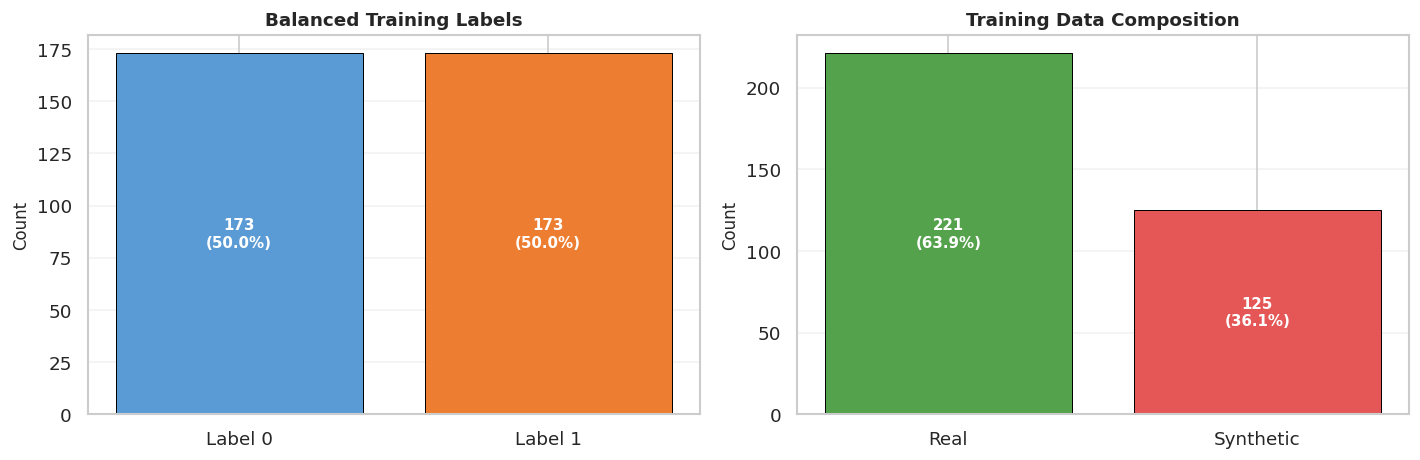

Balanced training set:
  Total      : 346
  Label = 0  : 173
  Label = 1  : 173
  Synthetic  : 125


,NC,DM,NS,ADD,SUB,CA,Label,NC_incomplete,DM_incomplete,NS_incomplete,ADD_incomplete,SUB_incomplete,CA_incomplete,NP,SN,AF,BC,AS,PF,is_synthetic
0,1601.166667,4408.462247,4.0,19.0,18.0,10.0,1,0,0,0,0,0,0,3004.814457,-2807.295580,12.75,8.5,1.0,0.004243,0
1,972.000000,2331.000000,14.0,41.0,35.0,23.0,0,0,0,0,0,0,0,1651.500000,-1359.000000,28.25,15.0,6.0,0.017106,0
2,666.500000,1378.125000,27.0,61.0,63.0,34.0,0,0,0,0,0,0,0,1022.312500,-711.625000,46.25,28.0,-2.0,0.045241,0
3,1052.000000,2284.000000,18.0,45.0,40.0,33.0,0,0,0,0,0,0,0,1668.000000,-1232.000000,34.00,9.5,5.0,0.020384,0
4,1053.276596,3118.500000,6.0,8.0,17.0,2.0,0,0,0,0,0,0,0,2085.888298,-2065.223404,8.25,10.5,-9.0,0.003955,0


In [ ]:
df_train_full = compute_derived(df_train)
df_train_full['is_synthetic'] = 0

# Concatenate real and synthetic training rows into one balanced training set.
df_train_balanced = pd.concat([df_train_full, df_selected_full], ignore_index=True)
counts = df_train_balanced['Label'].value_counts().sort_index()
source_counts = df_train_balanced['is_synthetic'].value_counts().sort_index()
total_rows = len(df_train_balanced)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label balance (0 vs 1)
label_vals = [counts.get(0, 0), counts.get(1, 0)]
label_bars = axes[0].bar(['Label 0', 'Label 1'], label_vals,
                         color=[TYPICAL_COLOR, AT_RIST_COLOR], edgecolor='black', linewidth=0.6)
axes[0].set_title('Balanced Training Labels', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.25)

# Real vs Synthetic composition
source_vals = [source_counts.get(0, 0), source_counts.get(1, 0)]
source_bars = axes[1].bar(['Real', 'Synthetic'], source_vals,
                          color=[REAL_COLOR, SYNTHETIC_COLOR], edgecolor='black', linewidth=0.6)
axes[1].set_title('Training Data Composition', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.25)

# Annotate bars with count + percentage in the middle
for ax, values, bars in [
    (axes[0], label_vals, label_bars),
    (axes[1], source_vals, source_bars),
]:
    for value, bar in zip(values, bars):
        pct = (value / total_rows * 100) if total_rows else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'{value}\n({pct:.1f}%)',
            ha='center',
            va='center',
            fontsize=9,
            fontweight='bold',
            color='white',
        )

plt.tight_layout()
plt.savefig(FIGURES_OUTPUTS / "training_label_distribution.png")
plt.show()

print('Balanced training set:')
print(f'  Total      : {len(df_train_balanced)}')
print(f'  Label = 0  : {counts.get(0, 0)}')
print(f'  Label = 1  : {counts.get(1, 0)}')
print(f'  Synthetic  : {source_counts.get(1, 0)}')

display(df_train_balanced.head())

#### Validator Note: Statistical Validation Criteria for Synthetic Samples

The synthetic At-Risk samples are evaluated against real At-Risk training samples using distributional and summary-statistic checks. The following checks support the decision to use synthetic records for training augmentation:

- **Kolmogorov-Smirnov test:** compares feature-level distributional similarity.
- **Jensen-Shannon Divergence:** measures distributional distance between real and synthetic feature values.
- **Summary statistics:** compares mean, standard deviation, median, skewness, and kurtosis.
- **Visual checks:** histograms, Q-Q plots, and correlation heatmaps help identify obvious synthetic-data artifacts.

The interpretation should remain cautious: passing these checks supports the use of synthetic samples for controlled augmentation, but it does not prove that synthetic records are equivalent to real learner records.


### 2.6 Synthetic vs Training Comparison

To empirically verify the quality and structural integrity of the synthetic minority class against the real minority distribution, a suite of four diagnostic visual analyses are performed: 
1. **Overlaid histograms** — marginal distribution match per raw feature
2. **Q-Q plots** — quantile-level alignment per raw feature
3. **Correlation heatmaps** — feature relationship preservation
4. **Distribution check summary heatmap** — all metrics at a glance

#### 2.6.1 Overlaid Histograms

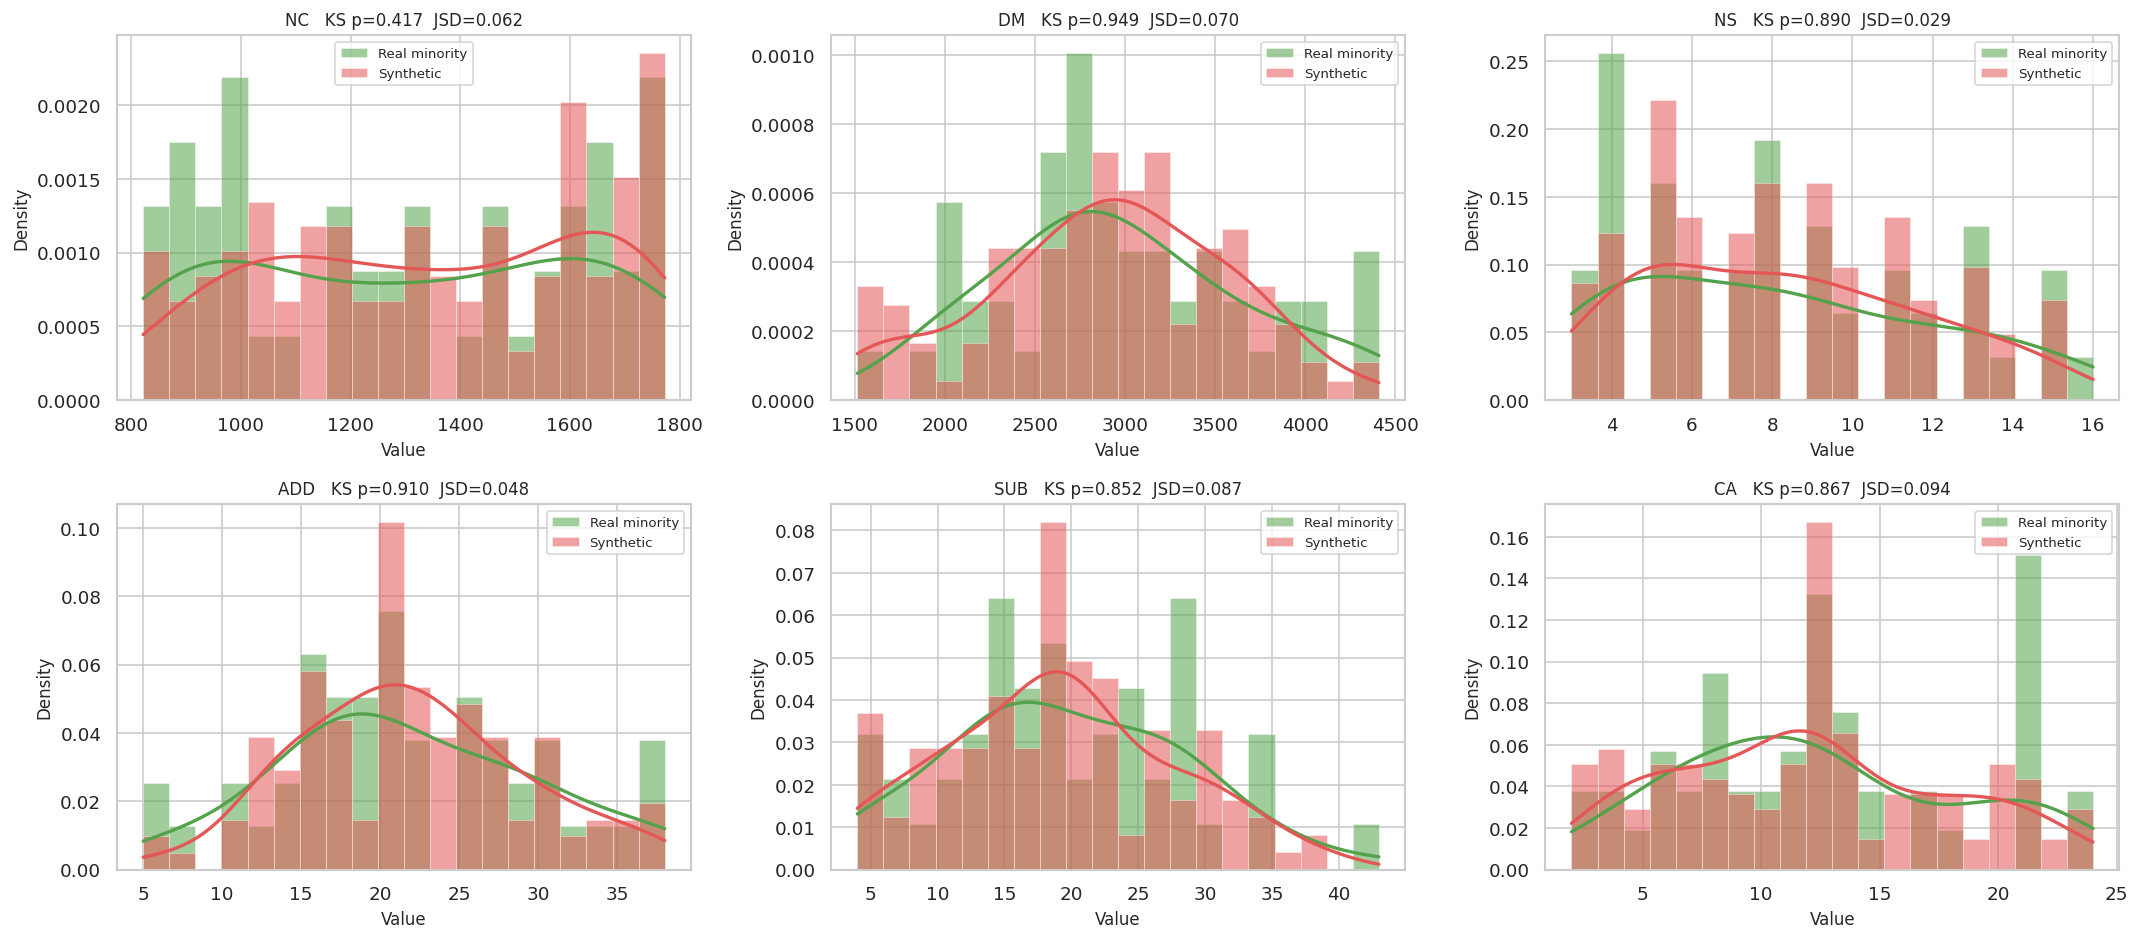

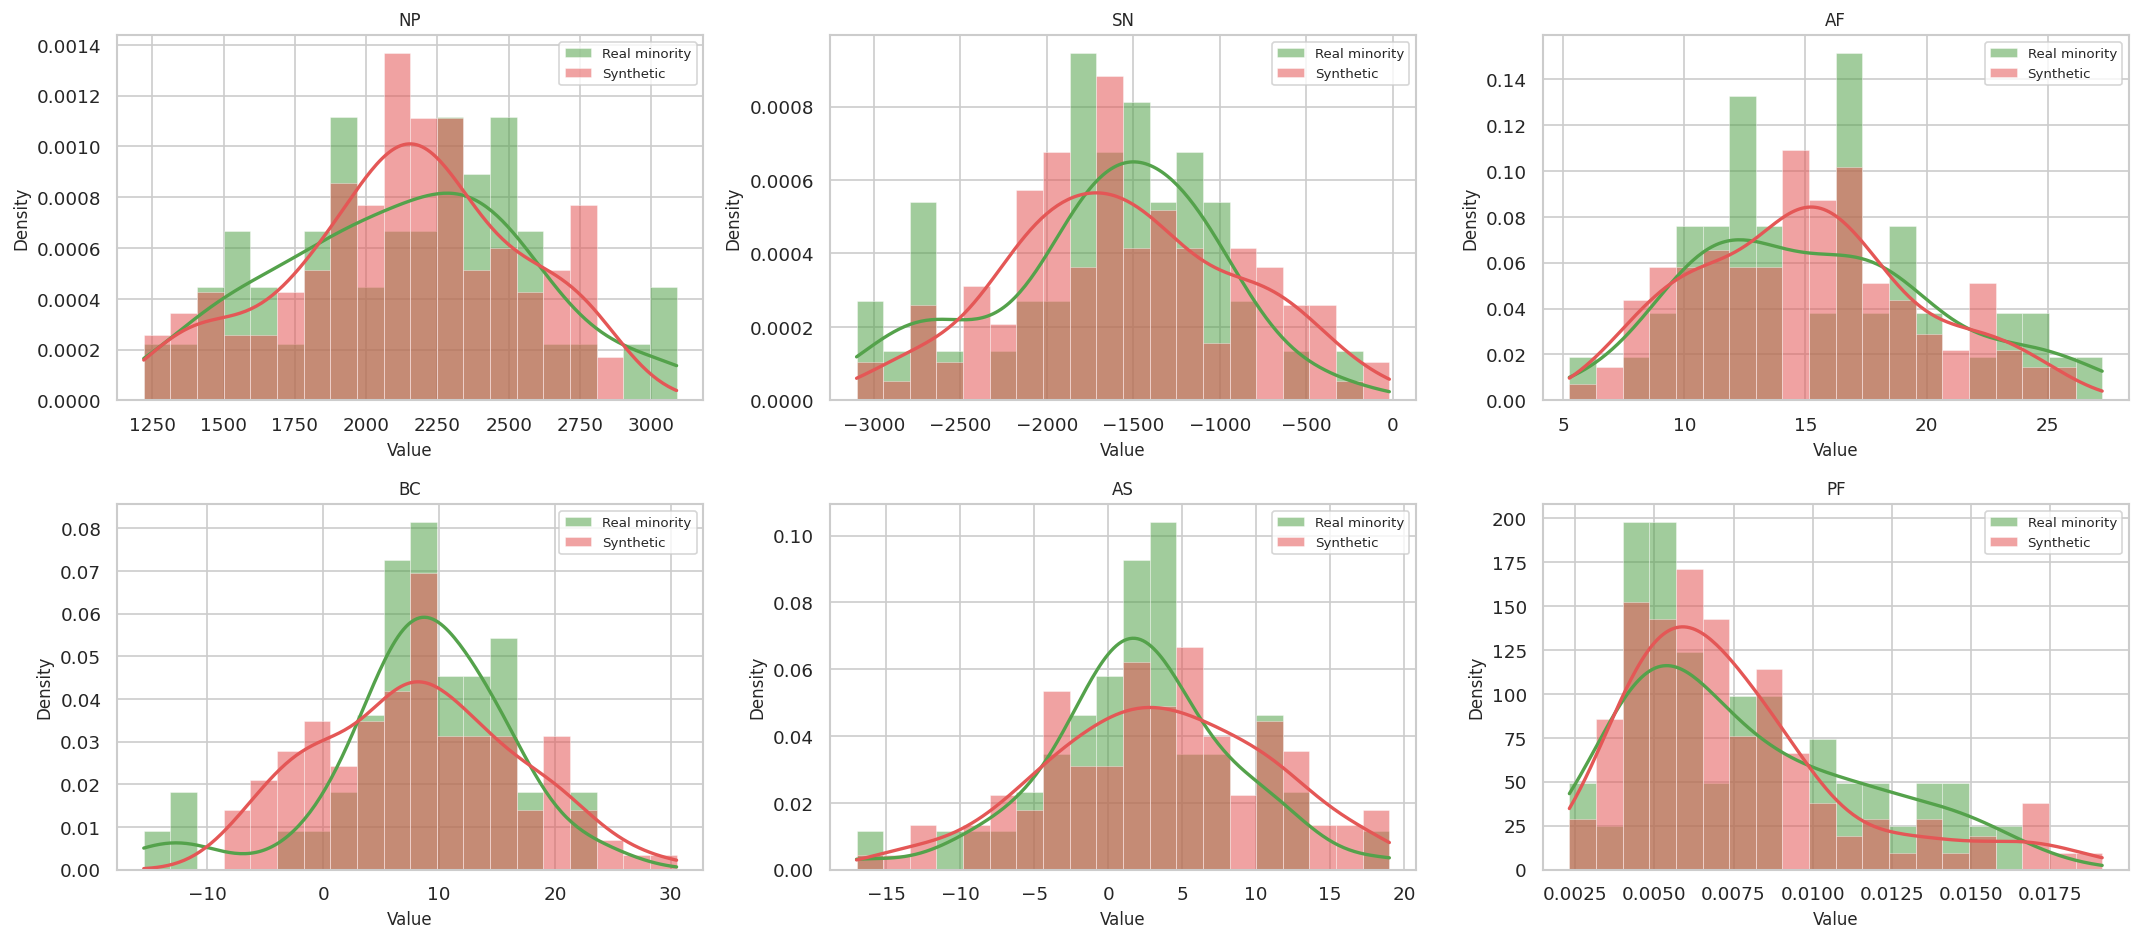

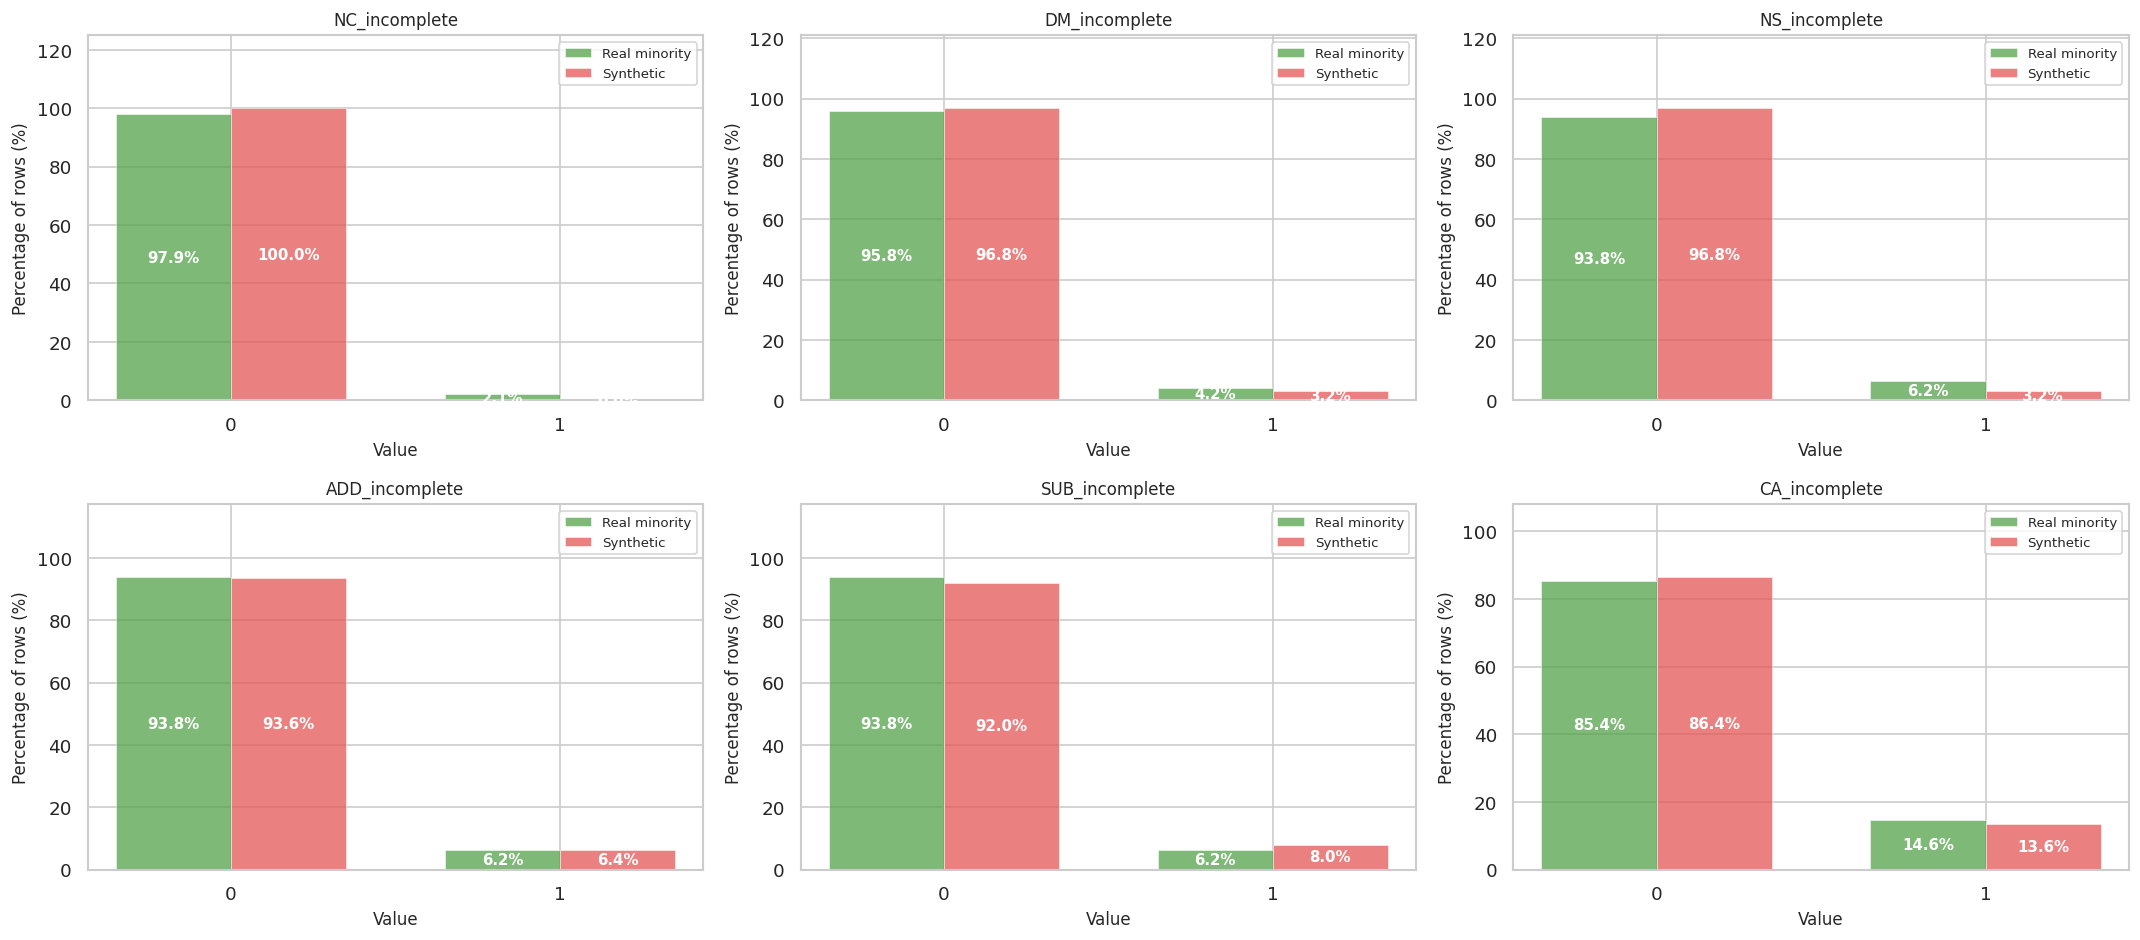

In [ ]:
FEATURE_GROUPS = {
    'Raw Features': FEATURE_COLUMNS,
    'Derived Features': DERIVED_FEATURES,
    'Incomplete Flags': [f + '_incomplete' for f in FEATURE_COLUMNS],
}
df_train_vis = df_train_full[df_train_full['Label'] == 1]

for group_name, feature_list in FEATURE_GROUPS.items():
    ncols = 3
    nrows = int(np.ceil(len(feature_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).ravel()

    for i, f in enumerate(feature_list):
        ax = axes[i]
        real_vals = df_train_vis[f]
        syn_vals  = df_selected_full[f]

        if f.endswith('_incomplete'):
            categories = np.array([0, 1])
            real_pct = [((real_vals == value).mean() * 100) for value in categories]
            syn_pct  = [((syn_vals == value).mean() * 100) for value in categories]
            x = np.arange(len(categories))
            width = 0.35

            real_bars = ax.bar(x - width / 2, real_pct, width,
                               color=REAL_COLOR, alpha=0.75,
                               label='Real minority', edgecolor='white', linewidth=0.4)
            syn_bars = ax.bar(x + width / 2, syn_pct, width,
                              color=SYNTHETIC_COLOR, alpha=0.75,
                              label='Synthetic', edgecolor='white', linewidth=0.4)

            ax.set_xticks(x)
            ax.set_xticklabels(['0', '1'])
            ax.set_ylabel('Percentage of rows (%)')
            ax.set_ylim(0, max(real_pct + syn_pct) * 1.25 if (real_pct + syn_pct) else 1)

            for bars in (real_bars, syn_bars):
                for bar in bars:
                    h = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width() / 2, h / 2,
                            f'{h:.1f}%', ha='center', va='center',
                            fontsize=9, fontweight='bold', color='white')
        else:
            bins = np.histogram_bin_edges(np.concatenate([real_vals, syn_vals]), bins=20)

            ax.hist(real_vals, bins=bins, alpha=0.55, color=REAL_COLOR,
                    label='Real minority', density=True, edgecolor='white', linewidth=0.4)
            ax.hist(syn_vals,  bins=bins, alpha=0.55, color=SYNTHETIC_COLOR,
                    label='Synthetic',    density=True, edgecolor='white', linewidth=0.4)

            # KDE curves for non-degenerate distributions
            if len(np.unique(real_vals)) > 1 and len(np.unique(syn_vals)) > 1:
                xgrid = np.linspace(bins[0], bins[-1], 200)
                ax.plot(xgrid, gaussian_kde(real_vals)(xgrid), color=REAL_COLOR, lw=2)
                ax.plot(xgrid, gaussian_kde(syn_vals)(xgrid),  color=SYNTHETIC_COLOR,    lw=2)

            ax.set_ylabel('Density')

        # Keep KS/JSD annotation only for raw features
        if df_dist_results is not None and f in FEATURE_COLUMNS:
            row = df_dist_results[df_dist_results['feature'] == f].iloc[0]
            ax.set_title(f"{f}   KS p={row['KS_p']:.3f}  JSD={row['JSD']:.3f}", fontsize=10)
        else:
            ax.set_title(f, fontsize=10)

        ax.set_xlabel('Value')
        ax.legend(fontsize=8)

    for j in range(len(feature_list), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(GAN_FIGURES / f'{group_name}_syn_real_histograms.png')
    plt.show()





#### 2.6.2 Q-Q Plots

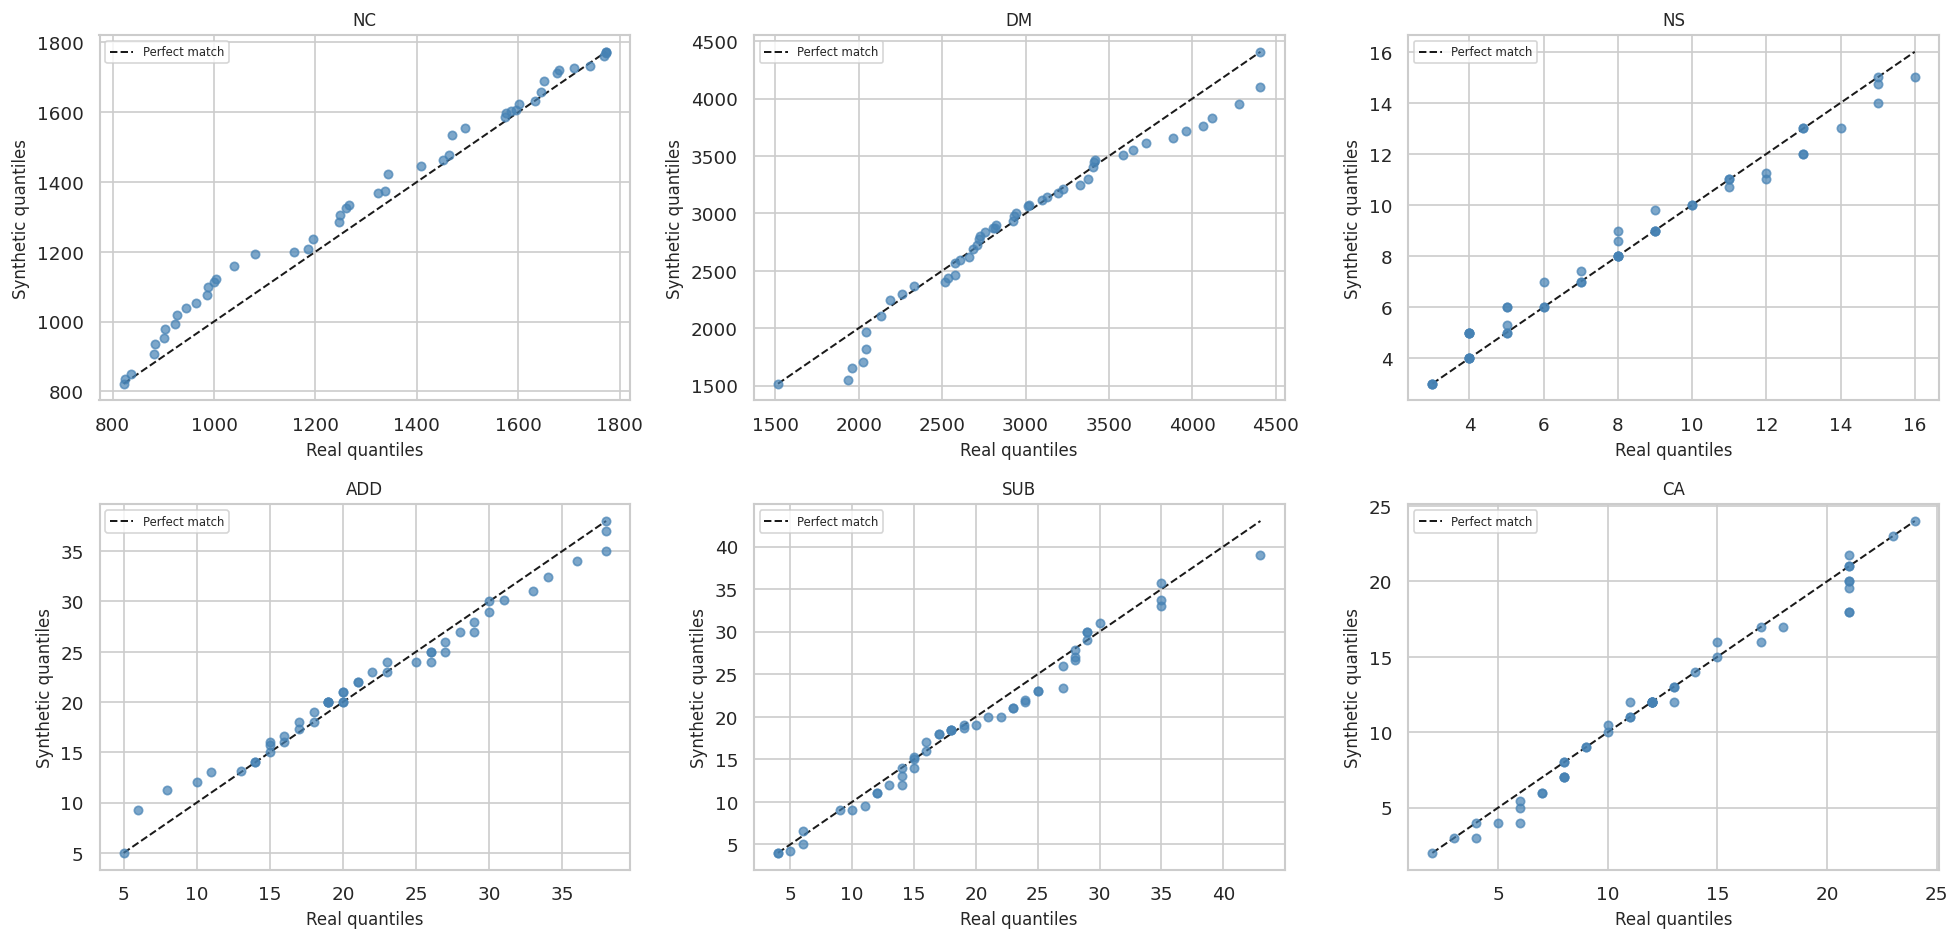

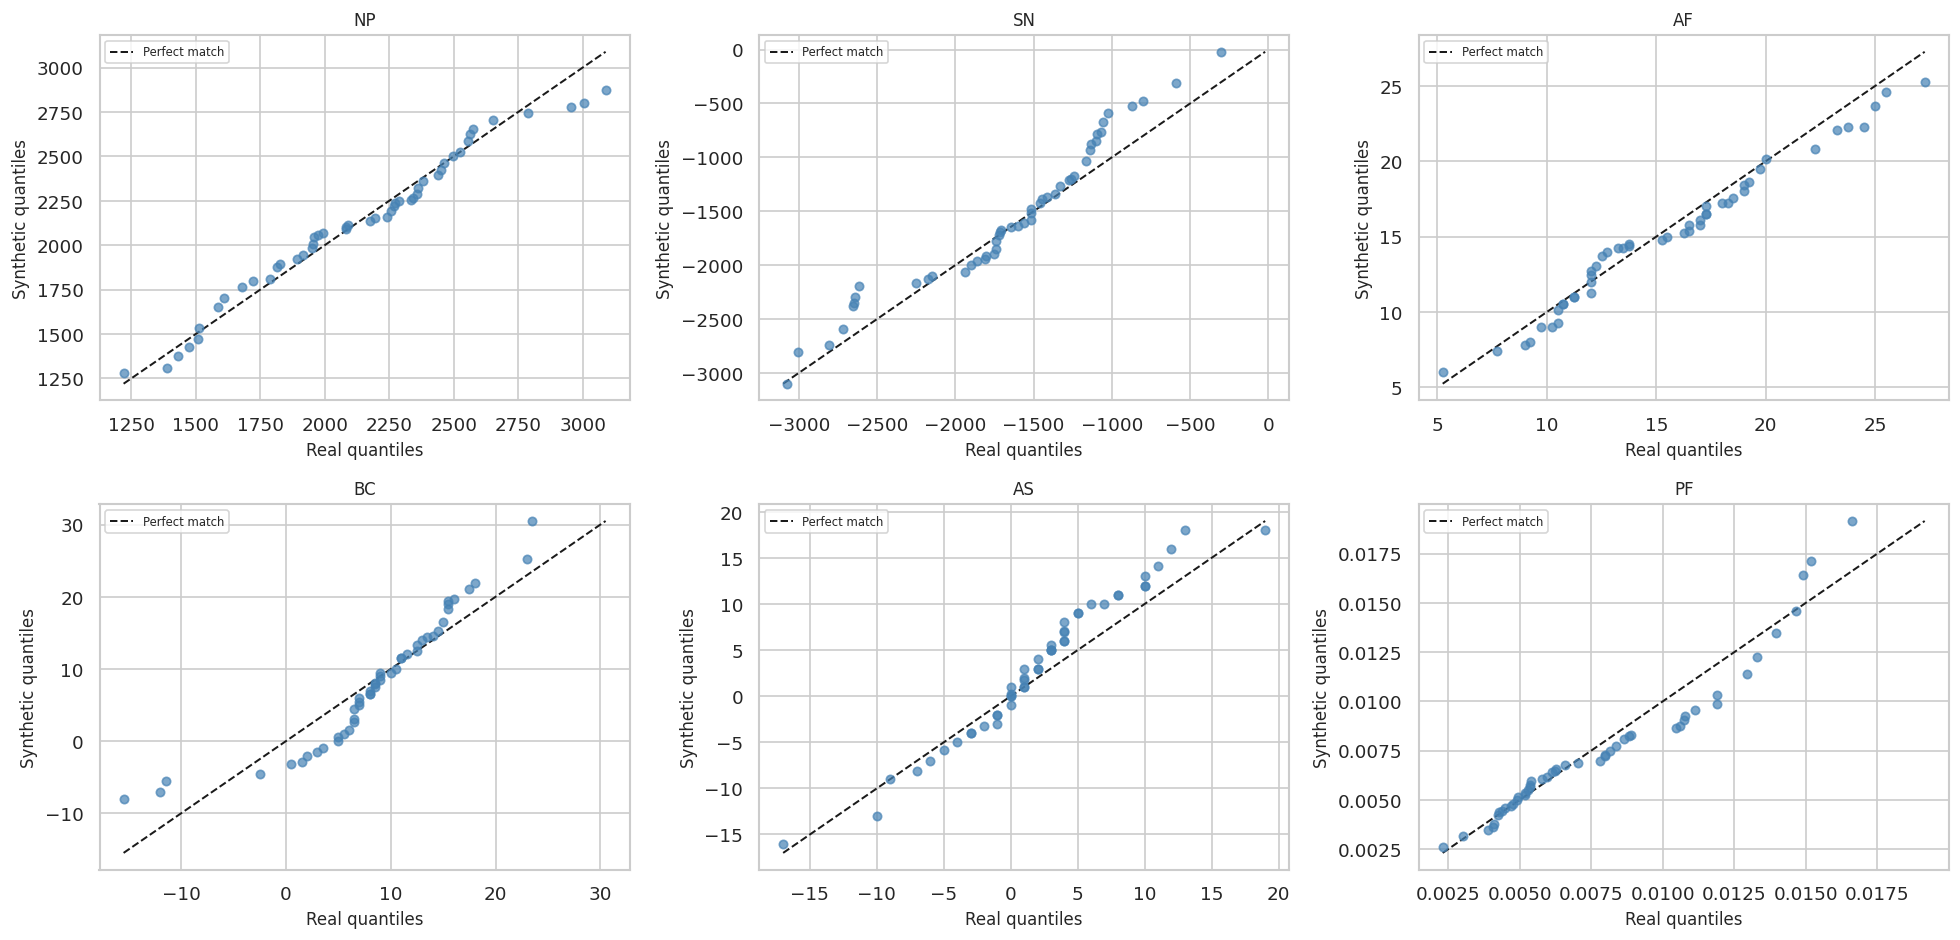

In [ ]:
QQ_FEATURE_GROUPS = {
    'Raw Features': FEATURE_COLUMNS,
    'Derived Features': DERIVED_FEATURES
}
df_train_vis = df_train_full[df_train_full['Label'] == 1]

for group_name, feature_list in QQ_FEATURE_GROUPS.items():
    ncols = 3
    nrows = int(np.ceil(len(feature_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows))
    axes = np.array(axes).ravel()

    for i, f in enumerate(feature_list):
        ax = axes[i]
        real_sorted = np.sort(df_train_vis[f].values)
        syn_sorted  = np.sort(df_selected_full[f].values)

        # Interpolate to common quantile grid
        quantiles = np.linspace(0, 1, min(len(real_sorted), len(syn_sorted)))
        real_q = np.quantile(real_sorted, quantiles)
        syn_q  = np.quantile(syn_sorted,  quantiles)

        ax.scatter(real_q, syn_q, color='steelblue', alpha=0.7, s=25, zorder=3)

        # Perfect-match reference line
        lo = min(real_q.min(), syn_q.min())
        hi = max(real_q.max(), syn_q.max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='Perfect match')

        ax.set_title(f, fontsize=10)
        ax.set_xlabel('Real quantiles')
        ax.set_ylabel('Synthetic quantiles')
        ax.legend(fontsize=7)

    for j in range(len(feature_list), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(GAN_FIGURES / f'{group_name}_syn_real_qq_plots.png')
    plt.show()





#### 2.6.3 Correlation Matrix Heatmaps

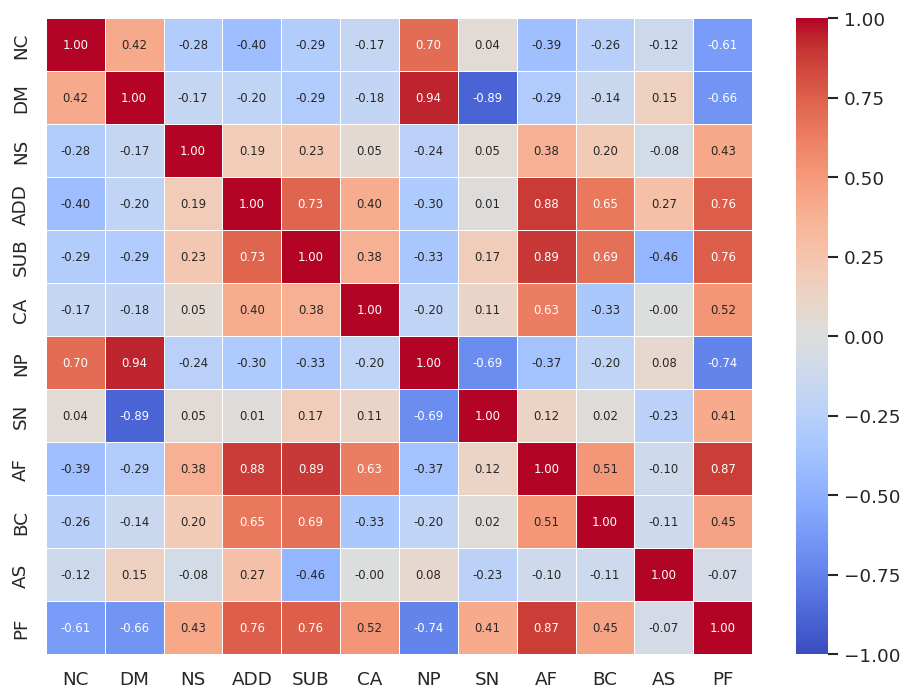

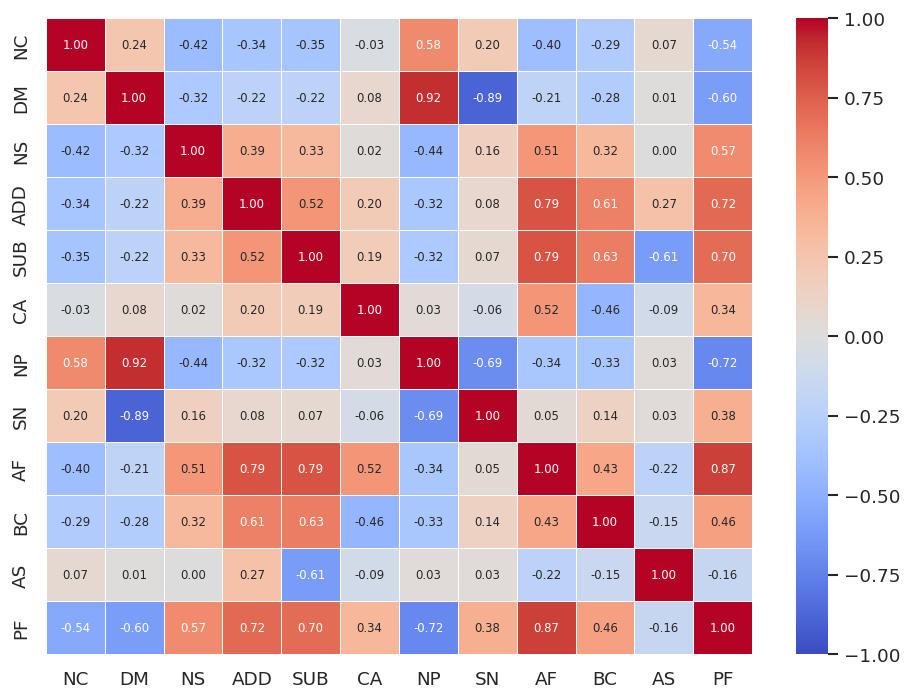

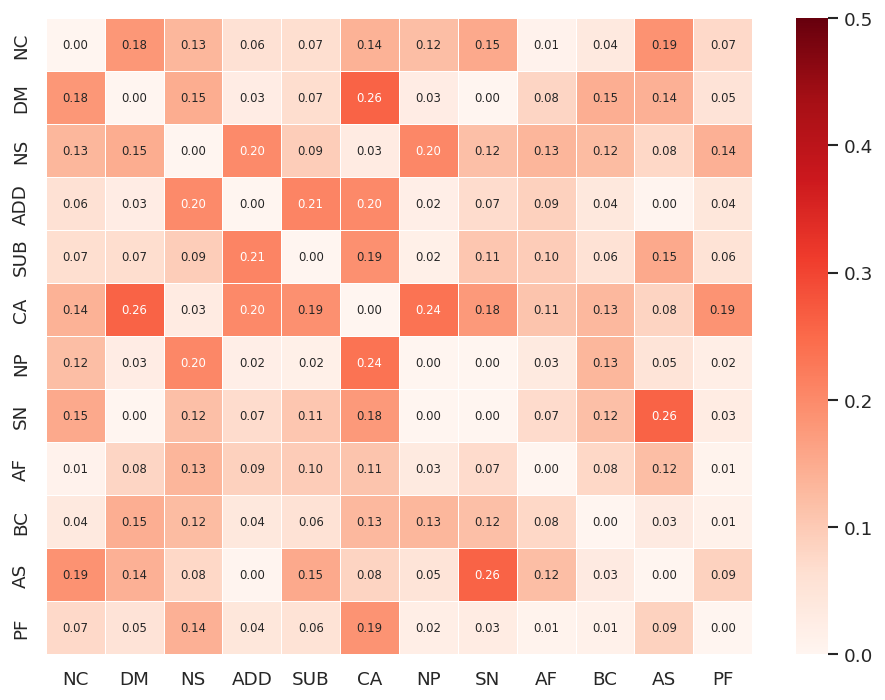

In [ ]:
ALL_FEATURES = FEATURE_COLUMNS + DERIVED_FEATURES

corr_real = df_train_full[df_train_full['Label'] == 1][ALL_FEATURES].corr()
corr_syn  = df_selected_full[ALL_FEATURES].corr()
corr_diff = (corr_syn - corr_real).abs()

# Common heatmap settings for correlation matrices
kw = dict(
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={'size': 7}
)

# ---- 1. Real Minority Correlation Matrix ----
plt.figure(figsize=(8, 6))
sns.heatmap(corr_real, **kw)
plt.tight_layout()
plt.savefig(GAN_FIGURES / 'real_minority_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# ---- 2. Synthetic Correlation Matrix ----
plt.figure(figsize=(8, 6))
sns.heatmap(corr_syn, **kw)
plt.tight_layout()
plt.savefig(GAN_FIGURES / 'synthetic_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# ---- 3. Absolute Difference Correlation Matrix ----
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_diff,
    annot=True,
    fmt='.2f',
    cmap='Reds',
    vmin=0,
    vmax=0.5,
    linewidths=0.3,
    annot_kws={'size': 7}
)
plt.tight_layout()
plt.savefig(GAN_FIGURES / 'correlation_difference_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

#### 2.6.4 Distribution Check Summary

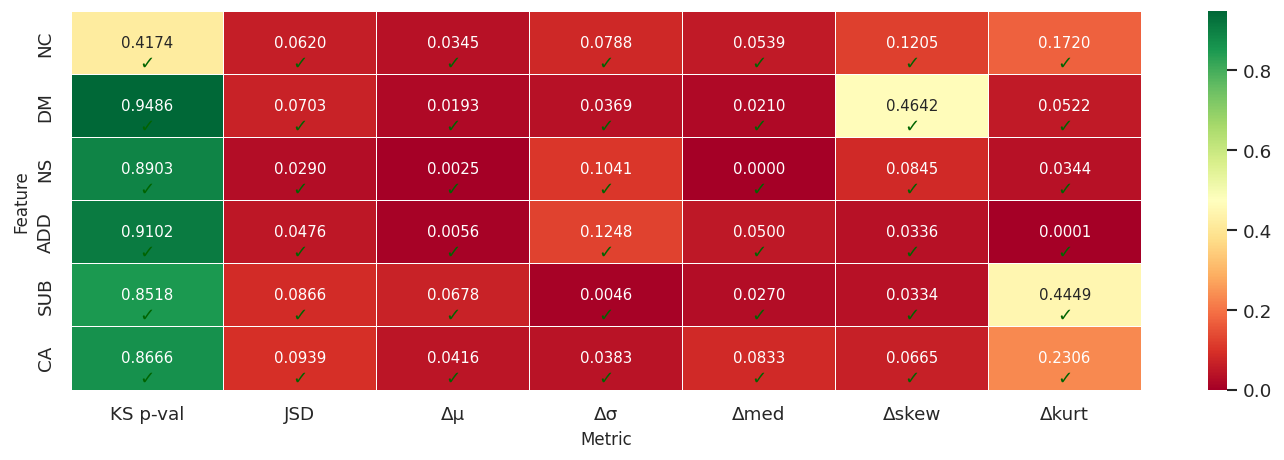

In [ ]:
if df_dist_results is not None:
    metrics   = ['KS_p', 'JSD', 'delta_mu', 'delta_std', 'delta_med', 'delta_skew', 'delta_kurt']
    thresholds = {
        'KS_p'      : (DIST_THRESHOLDS['ks_pval'], True),
        'JSD'       : (DIST_THRESHOLDS['JSD_THRESHOLD'], False),
        'delta_mu'  : (DIST_THRESHOLDS['T_mu'],   False),
        'delta_std' : (DIST_THRESHOLDS['T_sigma'], False),
        'delta_med' : (DIST_THRESHOLDS['T_med'],   False),
        'delta_skew': (DIST_THRESHOLDS['T_skew'],  False),
        'delta_kurt': (DIST_THRESHOLDS['T_kurt'],  False),
    }
    labels = ['KS p-val', 'JSD', 'Δμ', 'Δσ', 'Δmed', 'Δskew', 'Δkurt']

    heat_val  = df_dist_results.set_index('feature')[metrics]

    # Build pass/fail mask
    pass_mask = pd.DataFrame(index=heat_val.index, columns=metrics)
    for m, (thr, higher) in thresholds.items():
        if higher:
            pass_mask[m] = heat_val[m] > thr
        else:
            pass_mask[m] = heat_val[m] < thr

    fig, ax = plt.subplots(figsize=(12, 4))
    heat_display = heat_val.copy()
    heat_display.columns = labels

    sns.heatmap(
        heat_display.astype(float),
        ax=ax, annot=True, fmt='.4f',
        cmap='RdYlGn', linewidths=0.5, linecolor='white',
        annot_kws={'size': 9},
    )

    # Overlay ✓/✗ on each cell
    for row_i, feat in enumerate(heat_val.index):
        for col_j, m in enumerate(metrics):
            ok = pass_mask.loc[feat, m]
            ax.text(col_j + 0.5, row_i + 0.82, '✓' if ok else '✗',
                    ha='center', va='center', fontsize=11,
                    color='darkgreen' if ok else 'darkred', fontweight='bold')

    ax.set_xlabel('Metric')
    ax.set_ylabel('Feature')

    plt.tight_layout()
    plt.savefig(GAN_FIGURES / 'syn_real_distribution_check.png')
    plt.show()

### 2.7 Save GAN Data

The finalised splits—now featuring a selectively balanced training set alongside untouched, purely real validation and test sets—are exported to persistent storage. This ensures a clean, auditable hand-off to the predictive modeling pipeline.

In [ ]:
df_val_full  = compute_derived(df_val)
df_test_full = compute_derived(df_test)

DATASETS_FILENAMES = {
    'train': PROCESSED_DATASET_DIR / 'train.csv',
    's_train': PROCESSED_DATASET_DIR / 's_train.csv',
    'val': PROCESSED_DATASET_DIR / 'val.csv',
    'test': PROCESSED_DATASET_DIR / 'test.csv'
}

# Real Train Data only (both labels 0 and 1)
df_train_full.drop(columns=["is_synthetic"]).to_csv(DATASETS_FILENAMES['train'], index=False)

# Synthetic Train Data (label 1 only)
df_selected_full.drop(columns=["is_synthetic"]).to_csv(DATASETS_FILENAMES['s_train'], index=False)

# Validation and Test Data
df_val_full.to_csv(DATASETS_FILENAMES['val'],   index=False)
df_test_full.to_csv(DATASETS_FILENAMES['test'], index=False)

print(f"Files saved to {PROCESSED_DATASET_DIR.relative_to(ROOT_DIR)}:")
print(f"  {DATASETS_FILENAMES['train'].relative_to(ROOT_DIR)}    — {len(df_train_full)} rows (real only, labels 0 and 1)")
print(f"  {DATASETS_FILENAMES['s_train'].relative_to(ROOT_DIR)}  — {len(df_selected_full[df_selected_full["Label"] == 1])} rows (synthetic only, label 1)")
print(f"  {DATASETS_FILENAMES['val'].relative_to(ROOT_DIR)}      — {len(df_val_full)} rows (real only)")
print(f"  {DATASETS_FILENAMES['test'].relative_to(ROOT_DIR)}     — {len(df_test_full)} rows (real only)")





Files saved to datasets/processed:
  datasets/processed/train.csv    — 221 rows (real only, labels 0 and 1)
  datasets/processed/s_train.csv  — 125 rows (synthetic only, label 1)
  datasets/processed/val.csv      — 47 rows (real only)
  datasets/processed/test.csv     — 48 rows (real only)


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

ROOT_DIR = Path().resolve().parent
PROCESSED_DATASET_DIR = ROOT_DIR / 'datasets' / 'processed'
LOGS_OUTPUTS = ROOT_DIR / 'outputs' / 'logs_and_metrics'

FUNA_DB_DOMAIN_MAPPING = {
    'NC':  'Number Comparison',
    'DM':  'Digit-Dot Matching',
    'NP':  'Overall Processing Efficiency',
    'SN':  'Symbolic vs. Non-Symbolic Processing Difference',
    'NS':  'Number Series',
    'ADD': 'Single-Digit Addition',
    'SUB': 'Single-Digit Subtraction',
    'CA':  'Multi-Digit Addition and Subtraction',
    'AF':  'Overall Arithmetic Fluency',
    'BC':  'Basic vs. Complex Arithmetic Contrast',
    'AS':  'Addition vs. Subtraction Asymmetry',
    'PF':  'Processing-Fluency Integration',
}

real_train_export = pd.read_csv(PROCESSED_DATASET_DIR / 'train.csv')
synthetic_train_export = pd.read_csv(PROCESSED_DATASET_DIR / 's_train.csv')

real_at_risk = real_train_export.loc[real_train_export['Label'] == 1].copy()
synthetic_at_risk = synthetic_train_export.loc[synthetic_train_export['Label'] == 1].copy()

allowed_features = list(FUNA_DB_DOMAIN_MAPPING.keys())

candidate_cols = [
    col for col in real_at_risk.columns
    if col in synthetic_at_risk.columns
    and col not in {'Label', 'is_synthetic'}
    and not col.startswith('Unnamed')
    and not col.endswith('_incomplete')
    and col in allowed_features
 ]

candidate_cols = [col for col in allowed_features if col in candidate_cols]

real_numeric = real_at_risk[candidate_cols].apply(pd.to_numeric, errors='coerce')
synthetic_numeric = synthetic_at_risk[candidate_cols].apply(pd.to_numeric, errors='coerce')

shared_feature_cols = [
    col for col in candidate_cols
    if real_numeric[col].notna().any() and synthetic_numeric[col].notna().any()
 ]

if not shared_feature_cols:
    raise ValueError('No shared numeric feature columns were found between the exported At-Risk tables.')

real_features = real_numeric[shared_feature_cols].copy()
synthetic_features = synthetic_numeric[shared_feature_cols].copy()

real_medians = real_features.median()
real_features = real_features.fillna(real_medians)
synthetic_features = synthetic_features.fillna(real_medians)

scaler = StandardScaler()
real_scaled = scaler.fit_transform(real_features)
synthetic_scaled = scaler.transform(synthetic_features)

wasserstein_df = pd.DataFrame({
    'feature': shared_feature_cols,
    'wasserstein_distance': [
        stats.wasserstein_distance(real_scaled[:, idx], synthetic_scaled[:, idx])
        for idx in range(len(shared_feature_cols))
    ]
}).sort_values('wasserstein_distance', ascending=False).reset_index(drop=True)

if len(real_scaled) < 2:
    raise ValueError('Need at least two real At-Risk records to compute Nearest-Neighbor Distance Ratio.')

nn_model = NearestNeighbors(n_neighbors=2)
nn_model.fit(real_scaled)
nearest_distances, _ = nn_model.kneighbors(synthetic_scaled)
closest_distance = nearest_distances[:, 0]
second_distance = nearest_distances[:, 1]
nndr = closest_distance / np.maximum(second_distance, 1e-12)

real_signature = pd.DataFrame(
    np.round(real_features.to_numpy(dtype=float), 6),
    columns=shared_feature_cols,
 )
synthetic_signature = pd.DataFrame(
    np.round(synthetic_features.to_numpy(dtype=float), 6),
    columns=shared_feature_cols,
 )

identical_matches = synthetic_signature.merge(
    real_signature.drop_duplicates(),
    on=shared_feature_cols,
    how='inner',
 )
identical_match_rate = (len(identical_matches) / len(synthetic_signature) * 100) if len(synthetic_signature) else np.nan

summary_df = pd.DataFrame([{
    'n_real_at_risk': len(real_features),
    'n_synthetic_at_risk': len(synthetic_features),
    'n_shared_features': len(shared_feature_cols),
    'wasserstein_mean': wasserstein_df['wasserstein_distance'].mean(),
    'wasserstein_median': wasserstein_df['wasserstein_distance'].median(),
    'nndr_mean': float(np.mean(nndr)),
    'nndr_median': float(np.median(nndr)),
    'dcr_mean': float(np.mean(closest_distance)),
    'dcr_median': float(np.median(closest_distance)),
    'identical_match_rate_pct': identical_match_rate,
}])

LOGS_OUTPUTS.mkdir(parents=True, exist_ok=True)
wasserstein_df.to_csv(LOGS_OUTPUTS / 'gan_wasserstein_by_feature.csv', index=False)
summary_df.to_csv(LOGS_OUTPUTS / 'gan_real_vs_synthetic_similarity.csv', index=False)

print('### 2.8 GAN similarity metrics on exported At-Risk splits')
print(f"Real At-Risk rows      : {len(real_features)}")
print(f"Synthetic At-Risk rows : {len(synthetic_features)}")
print(f"Shared feature columns  : {len(shared_feature_cols)}")
print('Wasserstein distances are computed on standardized shared features.')
print('Identical Match Rate uses rounded original values across the shared feature columns.')
print(f"Metrics saved to        : {LOGS_OUTPUTS.relative_to(ROOT_DIR)}")
display(summary_df)
display(wasserstein_df)

### 2.8 GAN similarity metrics on exported At-Risk splits
Real At-Risk rows      : 48
Synthetic At-Risk rows : 125
Shared feature columns  : 12
Wasserstein distances are computed on standardized shared features.
Identical Match Rate uses rounded original values across the shared feature columns.
Metrics saved to        : outputs/logs_and_metrics


,n_real_at_risk,n_synthetic_at_risk,n_shared_features,wasserstein_mean,wasserstein_median,nndr_mean,nndr_median,dcr_mean,dcr_median,identical_match_rate_pct
0,48,125,12,0.174094,0.149173,0.857616,0.894061,1.99363,1.947854,0.0


,feature,wasserstein_distance
0,BC,0.309863
1,AS,0.287583
2,SN,0.229467
3,PF,0.185217
4,AF,0.169805
5,DM,0.150501
6,NC,0.147845
7,ADD,0.142404
8,NP,0.137244
9,SUB,0.124504


### 2.9 GAN Similarity Visual Summary

A compact figure helps inspect the multivariate relationship between the real At-Risk and synthetic At-Risk distributions after the exported splits are saved.

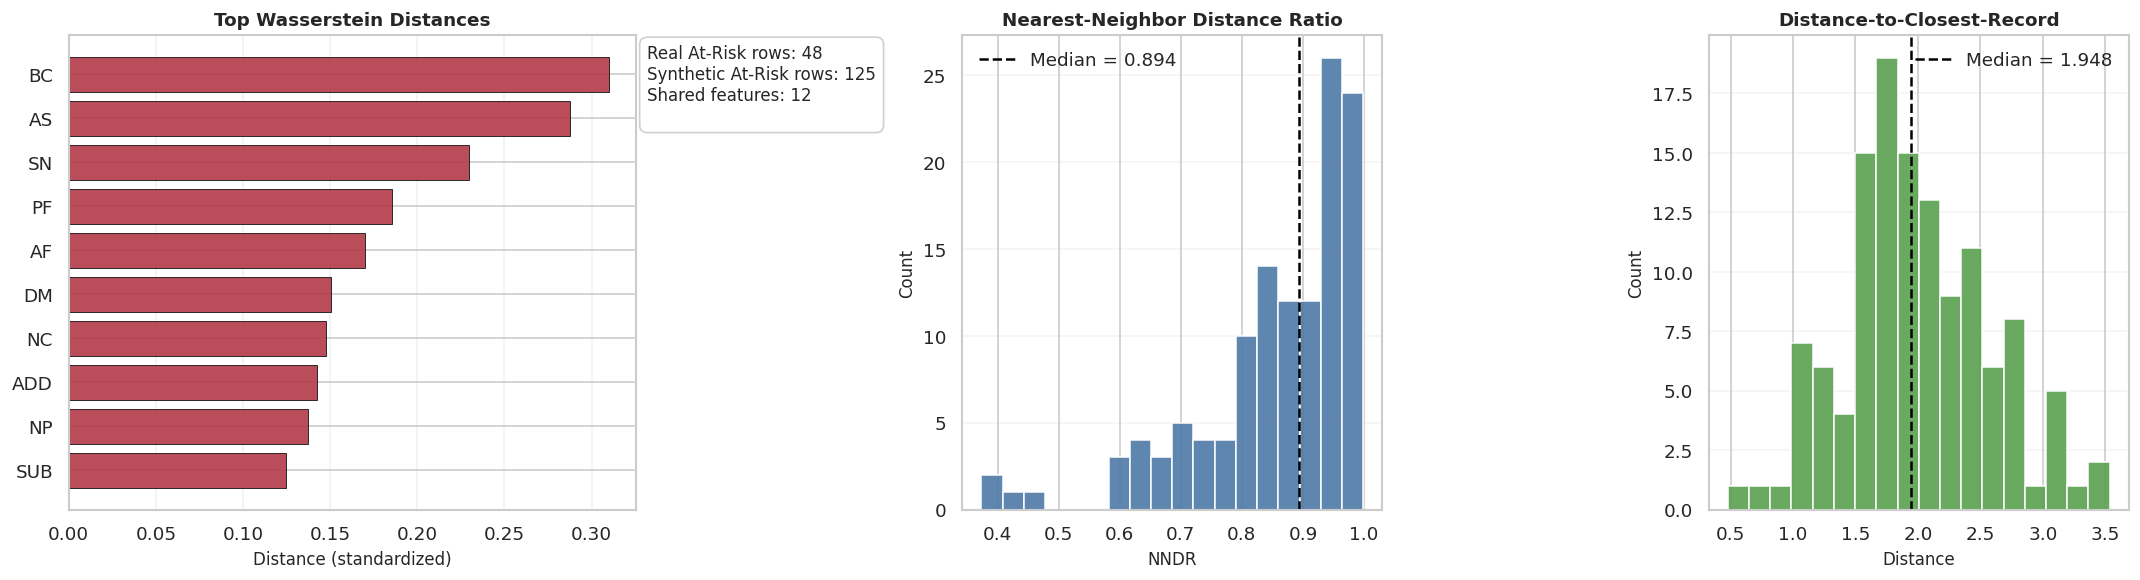

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={'width_ratios': [1.35, 1.0, 1.0]})

top_wasserstein = wasserstein_df.head(10).sort_values('wasserstein_distance', ascending=True)
axes[0].barh(
    top_wasserstein['feature'],
    top_wasserstein['wasserstein_distance'],
    color='#B23A48',
    edgecolor='black',
    linewidth=0.5,
    alpha=0.9,
 )
axes[0].set_title('Top Wasserstein Distances', fontweight='bold')
axes[0].set_xlabel('Distance (standardized)')
axes[0].grid(axis='x', alpha=0.25)

axes[1].hist(nndr, bins=18, color='#4E79A7', edgecolor='white', alpha=0.9)
axes[1].axvline(np.median(nndr), color='black', linestyle='--', linewidth=1.5, label=f'Median = {np.median(nndr):.3f}')
axes[1].set_title('Nearest-Neighbor Distance Ratio', fontweight='bold')
axes[1].set_xlabel('NNDR')
axes[1].set_ylabel('Count')
axes[1].legend(frameon=False)
axes[1].grid(axis='y', alpha=0.2)

axes[2].hist(closest_distance, bins=18, color='#59A14F', edgecolor='white', alpha=0.9)
axes[2].axvline(np.median(closest_distance), color='black', linestyle='--', linewidth=1.5, label=f'Median = {np.median(closest_distance):.3f}')
axes[2].set_title('Distance-to-Closest-Record', fontweight='bold')
axes[2].set_xlabel('Distance')
axes[2].set_ylabel('Count')
axes[2].legend(frameon=False)
axes[2].grid(axis='y', alpha=0.2)

summary_text = (
    f"Real At-Risk rows: {int(summary_df.loc[0, 'n_real_at_risk'])}\n"
    f"Synthetic At-Risk rows: {int(summary_df.loc[0, 'n_synthetic_at_risk'])}\n"
    f"Shared features: {int(summary_df.loc[0, 'n_shared_features'])}\n"
    # f"Identical Match Rate: {summary_df.loc[0, 'identical_match_rate_pct']:.2f}%\n\n"
    # f"Wasserstein mean: {summary_df.loc[0, 'wasserstein_mean']:.4f}\n"
    # f"NNDR mean: {summary_df.loc[0, 'nndr_mean']:.4f}\n"
    # f"DCR mean: {summary_df.loc[0, 'dcr_mean']:.4f}"
 )
axes[0].text(
    1.02, 0.98,
    summary_text,
    transform=axes[0].transAxes,
    ha='left',
    va='top',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.45', facecolor='white', edgecolor='#D0D0D0'),
 )

plt.tight_layout()
plt.show()

## Validator Note: Model Training and Evaluation Design

This section evaluates two training conditions:

- **TRTR:** Train on real training data and test on real held-out data.
- **TRSTR:** Train on real training data plus synthetic At-Risk training samples, then test on real held-out data.

The purpose of this comparison is to determine whether synthetic augmentation improves sensitivity to At-Risk learners. For a fair comparison, both conditions must use the same real validation and test sets. Synthetic records must be restricted to the TRSTR training set only.


## 3.0 Model Training and Evaluation

These sections compare the TRTR (Train-Real-Test-Real) and TRSTR (Train-Real-Synthetic-Test-Real) methodologies.

### 3.1 TRSTR vs TRTR Evaluation Pipeline

**Strategy:** This notebook compares a model trained on Real-only data (TRTR) versus Real + Synthetic data (TRSTR).

**Pipeline:**
1. Hyperparameter tuning
2. Cross-validation comparisons
3. Outlier fold investigation
4. Final test set evaluation
5. Feature importance analysis
6. Deployment CSV export


#### 3.1.1 Configs

In [ ]:
# Features that signal missing/incomplete data.
# The tree may still split on these (they carry real signal),
# but we exclude them from diagnostic z-score severity so that
# "timed out" is never conflated with "performed poorly".
INCOMPLETE_FLAGS = {
    "NC_incomplete", "DM_incomplete", "NS_incomplete",
    "ADD_incomplete", "SUB_incomplete", "CA_incomplete"
}

FUNA_DB_RAW_FEATURES: List[str] = FEATURE_COLUMNS + list(INCOMPLETE_FLAGS)
FUNA_DB_DIAGNOSTIC_FEATURES: List[str] = FUNA_DB_RAW_FEATURES + DERIVED_FEATURES

PARAM_GRID = {
    # CF in [0.10, 0.50]; sampled because confidence factor is continuous.
    'conf_fact':        np.round(np.arange(0.10, 0.51, 0.05), 2).tolist(),
    # n_min in {x | x in N, 10 <= x <= 50}
    'min_samples_leaf': list(range(10, 51)),
    # d_max in {x | x in N, 5 <= x <= 15}
    'max_depth':        list(range(5, 16)),
}

THRESHOLDS = np.arange(0.35, 0.76, 0.05).round(2)

N_JOBS = min(os.cpu_count() or 1, 12)
JOBLIB_BACKEND = 'loky'
GRID_SEARCH_EXPORT_COLS = [
    'fbeta', 'recall', 'precision', 'f1', 'accuracy', 'auc', 'rmse',
    *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves'
]
VALIDATION_SELECTION_METRIC_COLS = ['fbeta', 'recall', 'precision', 'f1', 'accuracy']
BEST_SELECTION_SORT_COLS = [
    *VALIDATION_SELECTION_METRIC_COLS,
]
TIE_RESOLUTION_SORT_COLS = [
    'cv_mean_fbeta', 'cv_mean_recall', 'cv_mean_precision', 'cv_mean_f1', 'cv_mean_accuracy',
    *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves'
]

#### 3.1.2 Helper Functions

In [ ]:
def split_xy(df: pd.DataFrame, label_col: str = 'Label'):
    X = df[FUNA_DB_DIAGNOSTIC_FEATURES]
    y = df[label_col]
    return X, y

def get_preds(tree, X: pd.DataFrame) -> List[int]:
    return [int(pred) for pred in tree.predict(X)]

def get_probs(tree, X: pd.DataFrame) -> np.ndarray:
    """Predict probability of the At-Risk class from reached leaf distributions."""
    return tree.predict_proba(X, positive_class=1)

def probs_to_preds(probs: List[float], threshold: float) -> List[int]:
    return [1 if p >= threshold else 0 for p in probs]

def safe_roc_auc(y_true, probs) -> float:
    y_numeric = np.asarray(y_true).astype(int)
    if len(np.unique(y_numeric)) < 2:
        return np.nan
    return roc_auc_score(y_numeric, probs)

def compute_metrics(y_true, preds, probs=None) -> dict:
    y_numeric = np.asarray(y_true).astype(int)
    metrics = {
        'f1':        f1_score(y_numeric, preds, zero_division=0),
        'fbeta':     fbeta_score(y_numeric, preds, beta=2, zero_division=0),
        'recall':    recall_score(y_numeric, preds, zero_division=0),
        'precision': precision_score(y_numeric, preds, zero_division=0),
        'accuracy':  accuracy_score(y_numeric, preds),
    }
    if probs is not None:
        metrics['auc'] = safe_roc_auc(y_numeric, probs)
        metrics['rmse'] = np.sqrt(mean_squared_error(y_numeric, probs))
    return metrics

def run_cv(X_train: pd.DataFrame, y_train: pd.Series, label: str,
           best_params: dict,
           n_real: Optional[int] = None, threshold: Optional[float] = None) -> tuple[dict, list[dict]]:

    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    cv_f1, cv_fbeta, cv_recall, cv_precision, cv_accuracy = [], [], [], [], []
    cv_auc, cv_rmse = [], []
    fold_records = []

    if n_real is not None:
        X_real  = X_train.iloc[:n_real].reset_index(drop=True)
        y_real  = y_train.iloc[:n_real].reset_index(drop=True)
        X_synth = X_train.iloc[n_real:].reset_index(drop=True)
        y_synth = y_train.iloc[n_real:].reset_index(drop=True)
    else:
        X_real, y_real = X_train.reset_index(drop=True), y_train.reset_index(drop=True)
        X_synth, y_synth = X_train.iloc[:0], y_train.iloc[:0]

    print(f'\nStarting 5-Fold Cross-Validation [{label}]...')
    if n_real is not None:
        print(f'  (folding over {len(X_real)} real samples; '
              f'{len(X_synth)} synthetic rows pinned to every train fold)')

    for fold, (train_index, val_index) in enumerate(skf.split(X_real, y_real), 1):

        X_val_fold = X_real.iloc[val_index]
        y_val_fold = y_real.iloc[val_index]

        X_trn_fold = pd.concat([X_real.iloc[train_index], X_synth], ignore_index=True)
        y_trn_fold = pd.concat([y_real.iloc[train_index], y_synth], ignore_index=True)

        tree = C45DecisionTree(**best_params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
        tree.fit(X_trn_fold, y_trn_fold,
                 raw_features=FUNA_DB_RAW_FEATURES)

        if threshold is not None:
            probs_val = get_probs(tree, X_val_fold)
            preds     = probs_to_preds(probs_val, threshold)
            m         = compute_metrics(y_val_fold, preds, probs_val)
        else:
            preds = get_preds(tree, X_val_fold)
            probs = get_probs(tree, X_val_fold)
            m     = compute_metrics(y_val_fold, preds, probs)

        cv_f1.append(m['f1'])
        cv_fbeta.append(m['fbeta'])
        cv_recall.append(m['recall'])
        cv_precision.append(m['precision'])
        cv_accuracy.append(m['accuracy'])
        cv_auc.append(m['auc'])
        cv_rmse.append(m['rmse'])

        fold_records.append({
            'fold': fold,
            'recall': m['recall'],
            'fbeta': m['fbeta'],
            'auc': m['auc'],
            'rmse': m['rmse'],
            'tree_depth': tree.get_depth(),
            'tree_leaves': tree.get_leaves_num(),
            'n_train':       len(X_trn_fold),
            'class_0_train': int((y_trn_fold == 0).sum()),
            'class_1_train': int((y_trn_fold == 1).sum()),
            'n_val':         len(X_val_fold),
            'class_0_val':   int((y_val_fold == 0).sum()),
            'class_1_val':   int((y_val_fold == 1).sum()),
        })

        print(f'  Fold {fold}: F1={m["f1"]:.4f}, F2={m["fbeta"]:.4f}, Recall={m["recall"]:.4f}, AUC={m["auc"]:.4f}, RMSE={m["rmse"]:.4f}')

    aggregated = {
        'mean_f1': np.mean(cv_f1), 'std_f1': np.std(cv_f1),
        'mean_fbeta': np.mean(cv_fbeta), 'std_fbeta': np.std(cv_fbeta),
        'mean_recall': np.mean(cv_recall), 'std_recall': np.std(cv_recall),
        'mean_precision': np.mean(cv_precision), 'std_precision': np.std(cv_precision),
        'mean_accuracy': np.mean(cv_accuracy), 'std_accuracy': np.std(cv_accuracy),
        'mean_auc': np.nanmean(cv_auc), 'std_auc': np.nanstd(cv_auc),
        'mean_rmse': np.mean(cv_rmse), 'std_rmse': np.std(cv_rmse),
    }

    return aggregated, fold_records

def print_cv_results(label: str, metrics: dict, threshold: Optional[float] = None):
    print(f'\n=== Cross-Validation Performance [{label}] (5-Fold) ===')
    print(f'  Recall:    {metrics["mean_recall"]:.4f} +/- {metrics["std_recall"]:.4f}')
    print(f'  Precision: {metrics["mean_precision"]:.4f} +/- {metrics["std_precision"]:.4f}')
    print(f'  F1-Score:  {metrics["mean_f1"]:.4f} +/- {metrics["std_f1"]:.4f}')
    print(f'  F2-Score:  {metrics["mean_fbeta"]:.4f} +/- {metrics["std_fbeta"]:.4f}')
    print(f'  Accuracy:  {metrics["mean_accuracy"]:.4f} +/- {metrics["std_accuracy"]:.4f}')
    print(f'  AUC-ROC:   {metrics["mean_auc"]:.4f} +/- {metrics["std_auc"]:.4f}')
    print(f'  RMSE:      {metrics["mean_rmse"]:.4f} +/- {metrics["std_rmse"]:.4f}')
    if threshold is not None:
        print(f'\n  Note: Metrics evaluated at threshold = {threshold}')

def print_variance_inspection(label: str, fold_records: list[dict]):
    df = pd.DataFrame(fold_records)
    mean_recall = df['recall'].mean()
    std_recall  = df['recall'].std()

    print(f'\n--- Fold Variance Inspection [{label}] ---')
    print(f'{"Fold":>5} {"N_train":>8} {"C0_tr":>6} {"C1_tr":>6} '
          f'{"N_val":>6} {"C0_val":>7} {"C1_val":>7} '
          f'{"Depth":>6} {"Leaves":>7} {"Recall":>8} {"F2":>8} {"Flag"}')
    print('-' * 95)

    for _, row in df.iterrows():
        flag = (
            ' HIGH' if row['recall'] > mean_recall + std_recall else
            ' LOW' if row['recall'] < mean_recall - std_recall else
            ''
        )
        print(f'{int(row["fold"]):>5} {int(row["n_train"]):>8} {int(row["class_0_train"]):>6} '
              f'{int(row["class_1_train"]):>6} {int(row["n_val"]):>6} '
              f'{int(row["class_0_val"]):>7} {int(row["class_1_val"]):>7} '
              f'{int(row["tree_depth"]):>6} {int(row["tree_leaves"]):>7} '
              f'{row["recall"]:>8.4f} {row["fbeta"]:>8.4f}{flag}')

    print(f'\n  Recall range : {df["recall"].min():.4f} - {df["recall"].max():.4f}')
    print(f'  Recall mean  : {mean_recall:.4f} +/- {std_recall:.4f}')

    corr_c1    = df['class_1_train'].corr(df['recall'])
    corr_depth = df['tree_depth'].corr(df['recall'])
    print(f'\n  Correlation: class_1_train vs recall = {corr_c1:+.3f}')
    print(f'  Correlation: tree_depth     vs recall = {corr_depth:+.3f}')
    if abs(corr_c1) > 0.6:
        print('  Strong correlation with positive-class count in training fold.')
        print('    Synthetic data may not be uniformly covering all subgroups.')

def iter_param_grid(param_grid: dict):
    keys = list(param_grid.keys())
    for values in product(*(param_grid[k] for k in keys)):
        yield dict(zip(keys, values))





### 3.2 Load Datasets and Prepare Training Sets

In [ ]:
print('Loading 70/15/15 Datasets...')

r_train = pd.read_csv(PROCESSED_DATASET_DIR / "train.csv")
s_train = pd.read_csv(PROCESSED_DATASET_DIR / "s_train.csv")
val_df  = pd.read_csv(PROCESSED_DATASET_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DATASET_DIR / "test.csv")

train_trtr = r_train.copy()                                     # TRTR: real only
train_trstr = pd.concat([r_train, s_train], ignore_index=True)  # TRSTR: real + synthetic

print(f'TRTR Train shape (Real 70%):         {train_trtr.shape}')
print(f'TRSTR Train shape (Real + Synth):     {train_trstr.shape}')
print(f'Validation shape (Real 15%):         {val_df.shape}')
print(f'Test shape (Real 15%):               {test_df.shape}')

print(f'\nSynthetic data class distribution:')
print(s_train['Label'].value_counts().rename({0: 'Typical (0)', 1: 'At-Risk (1)'}).to_string())

X_train_trtr, y_train_trtr = split_xy(train_trtr)
X_train_trstr, y_train_trstr = split_xy(train_trstr)
X_val,  y_val  = split_xy(val_df)
X_test, y_test = split_xy(test_df)

Loading 70/15/15 Datasets...
TRTR Train shape (Real 70%):         (221, 19)
TRSTR Train shape (Real + Synth):     (346, 19)
Validation shape (Real 15%):         (47, 19)
Test shape (Real 15%):               (48, 19)

Synthetic data class distribution:
Label
At-Risk (1)    125


### 3.3 Hyperparameter Search

Train one tree per hyperparameter candidate and evaluate the tree's native class predictions. The selected setting is the best hyperparameter set by validation F2.

**Note on model selection:** The grid is large relative to the validation size, so the best validation setting may be optimistic. Treat validation-tuned results as exploratory, or consider nested/repeated CV to reduce selection bias.

#### 3.3.1 Search Helpers

In [ ]:
def _evaluate_candidate(candidate_no, params, X_train, y_train, X_val, y_val, thresholded: bool = False):
    tree = C45DecisionTree(**params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
    tree.fit(X_train, y_train, raw_features=FUNA_DB_RAW_FEATURES)

    val_probs = get_probs(tree, X_val)
    tree_depth = tree.get_depth()
    tree_leaves = tree.get_leaves_num()

    if thresholded:
        candidate_records = []
        for threshold in THRESHOLDS:
            preds = probs_to_preds(val_probs, threshold)
            metrics = compute_metrics(y_val, preds, val_probs)
            candidate_records.append({
                **params,
                'candidate_no': candidate_no,
                'threshold': threshold,
                'f1': metrics['f1'],
                'fbeta': metrics['fbeta'],
                'recall': metrics['recall'],
                'precision': metrics['precision'],
                'accuracy': metrics['accuracy'],
                'auc': metrics['auc'],
                'rmse': metrics['rmse'],
                'tree_depth': tree_depth,
                'tree_leaves': tree_leaves,
            })
        return candidate_records

    preds = get_preds(tree, X_val)
    metrics = compute_metrics(y_val, preds, val_probs)
    return {
        **params,
        'candidate_no': candidate_no,
        'f1': metrics['f1'],
        'fbeta': metrics['fbeta'],
        'recall': metrics['recall'],
        'precision': metrics['precision'],
        'accuracy': metrics['accuracy'],
        'auc': metrics['auc'],
        'rmse': metrics['rmse'],
        'tree_depth': tree_depth,
        'tree_leaves': tree_leaves,
    }

def _as_python_scalar(value):
    return value.item() if hasattr(value, 'item') else value

def _grid_search_export_cols(thresholded: bool):
    threshold_col = ['threshold'] if thresholded else []
    return [
        'fbeta', 'recall', 'precision', 'f1', 'accuracy', 'auc', 'rmse',
        *threshold_col, *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves'
    ]

def save_grid_search_results(search_df, label: str, thresholded: bool):
    suffix = 'thresholded' if thresholded else 'no_threshold'
    output_path = GRIDSEARCH_OUTPUTS / f'{label.lower()}_{suffix}_grid_search_results.csv'
    search_df[_grid_search_export_cols(thresholded)].to_csv(output_path, index=False)
    print(f'[{label} | {suffix}] Saved full grid search results ({len(search_df)} rows): {output_path}')
    return output_path

def _params_from_row(row):
    params = {k: _as_python_scalar(row[k]) for k in PARAM_GRID.keys()}
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    params['max_depth'] = int(params['max_depth'])
    return params

def _validation_best_ties(search_df, thresholded: bool):
    top_row = search_df.iloc[0]
    tied_mask = np.logical_and.reduce([
        np.isclose(search_df[col], top_row[col])
        for col in VALIDATION_SELECTION_METRIC_COLS
    ])

    threshold_cols = ['threshold'] if thresholded else []
    tied_cols = [
        *VALIDATION_SELECTION_METRIC_COLS,
        *threshold_cols,
        *PARAM_GRID.keys(),
        'tree_depth',
        'tree_leaves'
    ]
    subset_cols = [*threshold_cols, *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves']
    return search_df.loc[tied_mask, tied_cols].drop_duplicates(
        subset=subset_cols
    ).reset_index(drop=True)

def _evaluate_tied_candidate(row, X_train, y_train, label, thresholded: bool, n_real=None):
    params = _params_from_row(row)
    threshold = float(row['threshold']) if thresholded else None

    cv_metrics, _ = run_cv(
        X_train, y_train, label, params,
        n_real=n_real,
        threshold=threshold
    )

    record = {
        **{f'val_{col}': float(row[col]) for col in VALIDATION_SELECTION_METRIC_COLS},
        **{f'cv_{key}': float(value) for key, value in cv_metrics.items()},
        **params,
        'tree_depth': int(row['tree_depth']),
        'tree_leaves': int(row['tree_leaves']),
    }
    if thresholded:
        record['threshold'] = threshold
    return record

def resolve_validation_ties_with_cv(search_df, X_train, y_train, label, thresholded: bool, n_real=None):
    suffix = 'thresholded' if thresholded else 'no_threshold'
    tied_df = _validation_best_ties(search_df, thresholded)
    print(f'\n[{label} | {suffix}] Validation-best tied candidates: {len(tied_df)}')

    tie_records = []
    for candidate_no, (_, row) in enumerate(tied_df.iterrows(), 1):
        threshold_text = f'threshold={float(row["threshold"]):.2f}, ' if thresholded else ''
        print(f'\n[{label} | {suffix}] Tie candidate {candidate_no}/{len(tied_df)}: '
              f'{threshold_text}params={_params_from_row(row)}')
        tie_records.append(_evaluate_tied_candidate(
            row, X_train, y_train, label, thresholded=thresholded, n_real=n_real
        ))

    sort_cols = [
        'cv_mean_fbeta', 'cv_mean_recall', 'cv_mean_precision', 'cv_mean_f1', 'cv_mean_accuracy',
        *(['threshold'] if thresholded else []),
        *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves'
    ]
    tie_results_df = pd.DataFrame(tie_records).sort_values(
        by=sort_cols,
        ascending=False,
    )

    output_path = GRIDSEARCH_OUTPUTS / f'{label.lower()}_{suffix}_validation_tie_cv_results.csv'
    tie_results_df.to_csv(output_path, index=False)
    print(f'[{label} | {suffix}] Saved validation-tie CV results ({len(tie_results_df)} rows): {output_path}')

    best_row = tie_results_df.iloc[0]
    best_params = _params_from_row(best_row)
    best_threshold = float(best_row['threshold']) if thresholded else None

    print(f'\n[{label} | {suffix}] Selected after validation-tie CV resolution:')
    print(f'  Params: {best_params}')
    if thresholded:
        print(f'  Threshold: {best_threshold:.2f}')
    print(f'  CV F2={best_row["cv_mean_fbeta"]:.4f}, '
          f'CV Recall={best_row["cv_mean_recall"]:.4f}, '
          f'CV Precision={best_row["cv_mean_precision"]:.4f}')

    if thresholded:
        return best_params, best_threshold, tie_results_df
    return best_params, tie_results_df

def tune_params(X_train, y_train, X_val, y_val, label: str, thresholded: bool = False):
    suffix = 'thresholded' if thresholded else 'no_threshold'
    candidates = list(enumerate(iter_param_grid(PARAM_GRID), 1))
    n_candidates = len(candidates)

    print(f'\n[{label} | {suffix}] Parallel search: {n_candidates} param combos')
    if thresholded:
        print(f'[{label} | {suffix}] Threshold grid: {THRESHOLDS.tolist()}')

    search_records = Parallel(
        n_jobs=N_JOBS,
        backend=JOBLIB_BACKEND,
        prefer='processes',
        verbose=10,
        batch_size=1,
        pre_dispatch='2*n_jobs',
    )(
        delayed(_evaluate_candidate)(candidate_no, params, X_train, y_train, X_val, y_val, thresholded)
        for candidate_no, params in candidates
    )

    if thresholded:
        search_records = [row for candidate_rows in search_records for row in candidate_rows]

    if not search_records:
        raise RuntimeError(f'[{label} | {suffix}] No search records were generated.')

    search_df = pd.DataFrame(search_records).sort_values(
        by=BEST_SELECTION_SORT_COLS,
        ascending=False,
    )

    save_grid_search_results(search_df, label, thresholded=thresholded)

    best_row = search_df.iloc[0]
    best_params = _params_from_row(best_row)
    best_threshold = float(best_row['threshold']) if thresholded else None

    best_metrics = {
        'f1': float(best_row['f1']),
        'fbeta': float(best_row['fbeta']),
        'recall': float(best_row['recall']),
        'precision': float(best_row['precision']),
        'accuracy': float(best_row['accuracy']),
    }

    print(f'\n[{label} | {suffix}] Top validation candidates:')
    print(search_df[_grid_search_export_cols(thresholded)].head(10).to_string(index=False))

    print(f'\n[{label} | {suffix}] Selected validation setting:')
    print(f'  Params: {best_params}')
    if thresholded:
        print(f'  Threshold: {best_threshold:.2f}')
    print(f'  F2={best_metrics["fbeta"]:.4f}, '
          f'Recall={best_metrics["recall"]:.4f}, '
          f'Precision={best_metrics["precision"]:.4f}')

    if thresholded:
        return best_params, best_threshold, search_df
    return best_params, search_df





#### 3.3.2 Main Search

In [ ]:
print('\n' + '=' * 60)
print('PHASE 1: Hyperparameter Search — No Threshold and Thresholded')
print('=' * 60)

print('\nSearch grid:')
for param_name, values in PARAM_GRID.items():
    print(f'  {param_name}: {values}')
print(f'  thresholds: {THRESHOLDS.tolist()}')
print(f'  parallel jobs: {N_JOBS} ({JOBLIB_BACKEND})')

# ---- A. No-threshold validation search ----
BEST_PARAMS_TRTR_NT, SEARCH_RESULTS_TRTR_NT = tune_params(
    X_train_trtr, y_train_trtr, X_val, y_val, 'TRTR', thresholded=False
)
BEST_PARAMS_TRSTR_NT, SEARCH_RESULTS_TRSTR_NT = tune_params(
    X_train_trstr, y_train_trstr, X_val, y_val, 'TRSTR', thresholded=False
)

BEST_PARAMS_TRTR_NT, TIE_RESULTS_TRTR_NT = resolve_validation_ties_with_cv(
    SEARCH_RESULTS_TRTR_NT, X_train_trtr, y_train_trtr, 'TRTR', thresholded=False
)
BEST_PARAMS_TRSTR_NT, TIE_RESULTS_TRSTR_NT = resolve_validation_ties_with_cv(
    SEARCH_RESULTS_TRSTR_NT, X_train_trstr, y_train_trstr, 'TRSTR', thresholded=False,
    n_real=len(r_train)
)

# ---- B. Thresholded validation search ----
BEST_PARAMS_TRTR_TH, BEST_THRESHOLD_TRTR, SEARCH_RESULTS_TRTR_TH = tune_params(
    X_train_trtr, y_train_trtr, X_val, y_val, 'TRTR', thresholded=True
)
BEST_PARAMS_TRSTR_TH, BEST_THRESHOLD_TRSTR, SEARCH_RESULTS_TRSTR_TH = tune_params(
    X_train_trstr, y_train_trstr, X_val, y_val, 'TRSTR', thresholded=True
)

BEST_PARAMS_TRTR_TH, BEST_THRESHOLD_TRTR, TIE_RESULTS_TRTR_TH = resolve_validation_ties_with_cv(
    SEARCH_RESULTS_TRTR_TH, X_train_trtr, y_train_trtr, 'TRTR', thresholded=True
)
BEST_PARAMS_TRSTR_TH, BEST_THRESHOLD_TRSTR, TIE_RESULTS_TRSTR_TH = resolve_validation_ties_with_cv(
    SEARCH_RESULTS_TRSTR_TH, X_train_trstr, y_train_trstr, 'TRSTR', thresholded=True,
    n_real=len(r_train)
)

# Backward-compatible aliases used by later cells / deployment code.
BEST_PARAMS_TRTR = BEST_PARAMS_TRTR_TH
BEST_PARAMS_TRSTR = BEST_PARAMS_TRSTR_TH






PHASE 1: Hyperparameter Search — No Threshold and Thresholded

Search grid:
  conf_fact: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
  min_samples_leaf: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
  max_depth: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  thresholds: [0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]
  parallel jobs: 12 (loky)

[TRTR | no_threshold] Parallel search: 4059 param combos


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    4.6s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:    5.8s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    8.9s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:   10.2s
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:   12.4s
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:   15.4s
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:   18.1s
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:   20.5s
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed:   23.6s
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed:   25.9s
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed:   29.0s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:   31.5s
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed:   34.4s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   37.6s
[Parallel(n_jobs=12)]: Done 197 tasks      | elapsed:  

[TRTR | no_threshold] Saved full grid search results (4059 rows): /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/outputs/grid_search/trtr_no_threshold_grid_search_results.csv

[TRTR | no_threshold] Top validation candidates:
   fbeta  recall  precision   f1  accuracy      auc     rmse  conf_fact  min_samples_leaf  max_depth  tree_depth  tree_leaves
0.652174     0.6        1.0 0.75  0.914894 0.864865 0.285977       0.15                10          5           5            8
0.652174     0.6        1.0 0.75  0.914894 0.864865 0.285977       0.15                10          6           5            8
0.652174     0.6        1.0 0.75  0.914894 0.864865 0.285977       0.15                10          7           5            8
0.652174     0.6        1.0 0.75  0.914894 0.864865 0.285977       0.15                10          8           5            8
0.652174     0.6        1.0 0.75  0.914894 0.864865 0.285977       0.15                10          9           5            8
0.652174  

[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    3.0s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:    4.7s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    8.9s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:   11.6s
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:   14.9s
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:   19.3s
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:   23.1s
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:   27.1s
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed:   31.3s
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed:   35.2s
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed:   39.0s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:   43.8s
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed:   48.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   52.6s
[Parallel(n_jobs=12)]: Done 197 tasks      | elapsed:   57.2s
[Parallel(n_jobs=12)]: Done 218 tasks      | elapsed:  1.0min
[Paralle

[TRSTR | no_threshold] Saved full grid search results (4059 rows): /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/outputs/grid_search/trstr_no_threshold_grid_search_results.csv

[TRSTR | no_threshold] Top validation candidates:
   fbeta  recall  precision       f1  accuracy      auc     rmse  conf_fact  min_samples_leaf  max_depth  tree_depth  tree_leaves
0.803571     0.9   0.562500 0.692308  0.829787 0.922973 0.330107       0.10                16          5           5            6
0.803571     0.9   0.562500 0.692308  0.829787 0.922973 0.330107       0.15                16          5           5            6
0.803571     0.9   0.562500 0.692308  0.829787 0.922973 0.330107       0.20                16          5           5            6
0.803571     0.9   0.562500 0.692308  0.829787 0.922973 0.330107       0.25                16          5           5            6
0.803571     0.9   0.562500 0.692308  0.829787 0.922973 0.330107       0.30                16          5         

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    4.0s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:    5.0s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    7.4s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    9.3s
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:   11.7s
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:   14.5s
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:   17.6s
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:   20.4s
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed:   23.4s
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed:   26.5s
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed:   30.5s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:   33.0s
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed:   36.3s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   39.3s
[Parallel(n_jobs=12)]: Done 197 tasks      | elapsed:  

[TRTR | thresholded] Saved full grid search results (36531 rows): /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/outputs/grid_search/trtr_thresholded_grid_search_results.csv

[TRTR | thresholded] Top validation candidates:
   fbeta  recall  precision       f1  accuracy      auc     rmse  threshold  conf_fact  min_samples_leaf  max_depth  tree_depth  tree_leaves
0.769231     0.8   0.666667 0.727273   0.87234 0.864865 0.285977       0.35       0.15                10          5           5            8
0.769231     0.8   0.666667 0.727273   0.87234 0.864865 0.285977       0.40       0.15                10          5           5            8
0.769231     0.8   0.666667 0.727273   0.87234 0.864865 0.285977       0.35       0.15                10          6           5            8
0.769231     0.8   0.666667 0.727273   0.87234 0.864865 0.285977       0.40       0.15                10          6           5            8
0.769231     0.8   0.666667 0.727273   0.87234 0.864865 0.28597

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    3.9s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:    5.6s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:   10.6s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:   14.0s
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:   19.6s
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:   24.3s
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:   29.7s
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:   34.5s
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed:   39.4s
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed:   43.8s
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed:   49.6s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:   54.8s
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed:  1.0min
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:  1.1min
[Parallel(n_jobs=12)]: Done 197 tasks      | elapsed:  

[TRSTR | thresholded] Saved full grid search results (36531 rows): /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/outputs/grid_search/trstr_thresholded_grid_search_results.csv

[TRSTR | thresholded] Top validation candidates:
   fbeta  recall  precision       f1  accuracy      auc     rmse  threshold  conf_fact  min_samples_leaf  max_depth  tree_depth  tree_leaves
0.803571     0.9     0.5625 0.692308  0.829787 0.922973 0.330107       0.35        0.1                16          5           5            6
0.803571     0.9     0.5625 0.692308  0.829787 0.922973 0.330107       0.40        0.1                16          5           5            6
0.803571     0.9     0.5625 0.692308  0.829787 0.922973 0.330107       0.45        0.1                16          5           5            6
0.803571     0.9     0.5625 0.692308  0.829787 0.922973 0.330107       0.50        0.1                16          5           5            6
0.803571     0.9     0.5625 0.692308  0.829787 0.922973 0.33

#### Validator Note: Cross-Validation Interpretation

Cross-validation is used for internal model-selection and stability inspection. Validation folds should contain real samples only. In the TRSTR condition, synthetic samples are restricted to the training side of the fold and should not be evaluated as validation records.

If synthetic samples are generated once from the full training partition before cross-validation, the CV results should be interpreted as internal training diagnostics rather than as a fully independent external validation. Final claims should rely primarily on the real validation set and the held-out real test set.


### 3.4 TRTR vs TRSTR Cross-Validation

TRSTR folds only over real samples; synthetic rows are pinned to every training fold

In [ ]:
print('\n' + '=' * 60)
print('PHASE 2: TRTR vs TRSTR Cross-Validation — No Threshold and Thresholded')
print('=' * 60)

# ---- A. No-threshold CV ----
cv_metrics_trtr_nt, fold_records_trtr_nt = run_cv(
    X_train_trtr, y_train_trtr, 'TRTR | no_threshold', BEST_PARAMS_TRTR_NT
)
cv_metrics_trstr_nt, fold_records_trstr_nt = run_cv(
    X_train_trstr, y_train_trstr, 'TRSTR | no_threshold', BEST_PARAMS_TRSTR_NT,
    n_real=len(r_train)
)

print_cv_results('TRTR | no_threshold', cv_metrics_trtr_nt)
print_cv_results('TRSTR | no_threshold', cv_metrics_trstr_nt)

# ---- B. Thresholded CV ----
cv_metrics_trtr_th, fold_records_trtr_th = run_cv(
    X_train_trtr, y_train_trtr, 'TRTR | thresholded', BEST_PARAMS_TRTR_TH,
    threshold=BEST_THRESHOLD_TRTR
)
cv_metrics_trstr_th, fold_records_trstr_th = run_cv(
    X_train_trstr, y_train_trstr, 'TRSTR | thresholded', BEST_PARAMS_TRSTR_TH,
    n_real=len(r_train),
    threshold=BEST_THRESHOLD_TRSTR
)

print_cv_results('TRTR | thresholded', cv_metrics_trtr_th, BEST_THRESHOLD_TRTR)
print_cv_results('TRSTR | thresholded', cv_metrics_trstr_th, BEST_THRESHOLD_TRSTR)

# Backward-compatible aliases: use thresholded results as the selected deployment path.
cv_metrics_trtr, fold_records_trtr = cv_metrics_trtr_th, fold_records_trtr_th
cv_metrics_trstr, fold_records_trstr = cv_metrics_trstr_th, fold_records_trstr_th






PHASE 2: TRTR vs TRSTR Cross-Validation — No Threshold and Thresholded

Starting 5-Fold Cross-Validation [TRTR | no_threshold]...
  Fold 1: F1=0.6667, F2=0.6863, Recall=0.7000, AUC=0.8486, RMSE=0.3267
  Fold 2: F1=0.5000, F2=0.4348, Recall=0.4000, AUC=0.6706, RMSE=0.3872
  Fold 3: F1=0.5833, F2=0.6481, Recall=0.7000, AUC=0.8500, RMSE=0.3523
  Fold 4: F1=0.7500, F2=0.6977, Recall=0.6667, AUC=0.8190, RMSE=0.2921
  Fold 5: F1=0.5217, F2=0.6000, Recall=0.6667, AUC=0.7873, RMSE=0.4118

Starting 5-Fold Cross-Validation [TRSTR | no_threshold]...
  (folding over 221 real samples; 125 synthetic rows pinned to every train fold)
  Fold 1: F1=0.7143, F2=0.8621, Recall=1.0000, AUC=0.9286, RMSE=0.3487
  Fold 2: F1=0.5517, F2=0.6780, Recall=0.8000, AUC=0.7926, RMSE=0.4658
  Fold 3: F1=0.6452, F2=0.8197, Recall=1.0000, AUC=0.8368, RMSE=0.4334
  Fold 4: F1=0.8421, F2=0.8696, Recall=0.8889, AUC=0.9492, RMSE=0.2605
  Fold 5: F1=0.6429, F2=0.8182, Recall=1.0000, AUC=0.8556, RMSE=0.4083

=== Cross-Validat

#### 3.4.1 Side-by-side CV Summary

In [ ]:
print('\n' + '=' * 60)
print('PHASE 3: CV Summary Comparison — No Threshold and Thresholded')
print('=' * 60)

metrics_labels = [
    ('Recall',    'mean_recall',    'std_recall'),
    ('Precision', 'mean_precision', 'std_precision'),
    ('F1-Score',  'mean_f1',        'std_f1'),
    ('F2-Score',  'mean_fbeta',     'std_fbeta'),
    ('Accuracy',  'mean_accuracy',  'std_accuracy'),
    ('AUC-ROC',   'mean_auc',       'std_auc'),
    ('RMSE',      'mean_rmse',      'std_rmse'),
]

def print_cv_comparison_table(title, trtr_metrics, trstr_metrics):
    print(f'\n--- {title} ---')
    print(f'\n{"Metric":>12}  {"TRTR (mean+/-std)":>26}  {"TRSTR (mean+/-std)":>26}  {"D (TRSTR-TRTR)":>15}')
    print('-' * 85)
    for name, mean_key, std_key in metrics_labels:
        trtr_val = trtr_metrics[mean_key]
        trstr_val = trstr_metrics[mean_key]
        delta    = trstr_val - trtr_val
        sign     = '+' if delta >= 0 else ''
        print(f'{name:>12}  '
              f'{trtr_val:.4f} +/- {trtr_metrics[std_key]:.4f}         '
              f'{trstr_val:.4f} +/- {trstr_metrics[std_key]:.4f}         '
              f'{sign}{delta:.4f}')

print_cv_comparison_table('No-threshold CV', cv_metrics_trtr_nt, cv_metrics_trstr_nt)
print_cv_comparison_table('Thresholded CV', cv_metrics_trtr_th, cv_metrics_trstr_th)






PHASE 3: CV Summary Comparison — No Threshold and Thresholded

--- No-threshold CV ---

      Metric           TRTR (mean+/-std)          TRSTR (mean+/-std)   D (TRSTR-TRTR)
-------------------------------------------------------------------------------------
      Recall  0.6267 +/- 0.1143         0.9378 +/- 0.0812         +0.3111
   Precision  0.6177 +/- 0.1481         0.5453 +/- 0.1344         -0.0725
    F1-Score  0.6043 +/- 0.0930         0.6792 +/- 0.0964         +0.0749
    F2-Score  0.6134 +/- 0.0956         0.8095 +/- 0.0691         +0.1961
    Accuracy  0.8189 +/- 0.0560         0.7963 +/- 0.0777         -0.0226
     AUC-ROC  0.7951 +/- 0.0663         0.8725 +/- 0.0583         +0.0774
        RMSE  0.3540 +/- 0.0425         0.3833 +/- 0.0724         +0.0293

--- Thresholded CV ---

      Metric           TRTR (mean+/-std)          TRSTR (mean+/-std)   D (TRSTR-TRTR)
-------------------------------------------------------------------------------------
      Recall  0.6667 +/-

#### 3.4.2 Fold Variance Inspection

In [ ]:
print('\n' + '=' * 60)
print('PHASE 4: Fold Variance Inspection — No Threshold and Thresholded')
print('=' * 60)

print_variance_inspection('TRTR | no_threshold', fold_records_trtr_nt)
print_variance_inspection('TRSTR | no_threshold', fold_records_trstr_nt)
print_variance_inspection('TRTR | thresholded', fold_records_trtr_th)
print_variance_inspection('TRSTR | thresholded', fold_records_trstr_th)






PHASE 4: Fold Variance Inspection — No Threshold and Thresholded

--- Fold Variance Inspection [TRTR | no_threshold] ---
 Fold  N_train  C0_tr  C1_tr  N_val  C0_val  C1_val  Depth  Leaves   Recall       F2 Flag
-----------------------------------------------------------------------------------------------
    1      176    138     38     45      35      10      3       4   0.7000   0.6863
    2      177    139     38     44      34      10      1       2   0.4000   0.4348 LOW
    3      177    139     38     44      34      10      5       6   0.7000   0.6481
    4      177    138     39     44      35       9      1       2   0.6667   0.6977
    5      177    138     39     44      35       9      4       5   0.6667   0.6000

  Recall range : 0.4000 - 0.7000
  Recall mean  : 0.6267 +/- 0.1278

  Correlation: class_1_train vs recall = +0.286
  Correlation: tree_depth     vs recall = +0.612

--- Fold Variance Inspection [TRSTR | no_threshold] ---
 Fold  N_train  C0_tr  C1_tr  N_val  C0

##### 3.4.2.1 TRSTR Outlier Fold Investigation

Dynamically identifies the lowest-recall TRSTR fold and inspects the real at-risk cases in its val split to surface subgroups the synthetic data may not be covering well.

In [ ]:
# Detect outlier fold from the thresholded TRSTR CV path used as the deployment-oriented setting.
trstr_fold_df     = pd.DataFrame(fold_records_trstr_th)
outlier_fold_no  = int(trstr_fold_df.loc[trstr_fold_df['recall'].idxmin(), 'fold'])
outlier_recall   = trstr_fold_df.loc[trstr_fold_df['recall'].idxmin(), 'recall']
mean_trstr_recall = trstr_fold_df['recall'].mean()

print('\n' + '=' * 60)
print(f'PHASE 4b: Thresholded TRSTR Fold {outlier_fold_no} Outlier Investigation')
print('=' * 60)

print(f'\n  Outlier fold: Fold {outlier_fold_no} '
      f'(recall={outlier_recall:.4f} vs mean={mean_trstr_recall:.4f})')

# Re-run the same split used in Phase 2 to recover val indices.
# CV in Phase 2 folded over real samples only — replicate that here.
X_real_inv = X_train_trstr.iloc[:len(r_train)].reset_index(drop=True)
y_real_inv = y_train_trstr.iloc[:len(r_train)].reset_index(drop=True)

skf_inv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold_i, (_, val_idx) in enumerate(skf_inv.split(X_real_inv, y_real_inv), 1):
    if fold_i == outlier_fold_no:
        outlier_val_idx = val_idx
        break

# Recover real val rows for the outlier fold
real_val_fold_df = r_train.iloc[outlier_val_idx].copy()
score_cols       = ["NC", "DM", "NS", "ADD", "SUB", "CA"]

print(f'\n  Val split composition for Fold {outlier_fold_no}:')
print(f'    Real samples: {len(real_val_fold_df)}  '
      f'(class 0: {int((real_val_fold_df["Label"]==0).sum())}  '
      f'class 1: {int((real_val_fold_df["Label"]==1).sum())})')
print(f'    Synthetic samples: 0  (all synthetic pinned to train — Option A)')

real_pos_val = real_val_fold_df[real_val_fold_df['Label'] == 1]

if len(real_pos_val) > 0:
    print(f'\n  Real at-risk cases in Fold {outlier_fold_no} val (n={len(real_pos_val)}):')
    print(f'  {"Feature":>6} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
    print('  ' + '-' * 44)
    for col in score_cols:
        if col in real_pos_val.columns:
            vals = real_pos_val[col]
            print(f'  {col:>6} {vals.mean():>8.3f} {vals.std():>8.3f} '
                  f'{vals.min():>8.3f} {vals.max():>8.3f}')

    real_pos_train = r_train.iloc[
        [i for i in range(len(r_train)) if i not in outlier_val_idx]
    ]
    real_pos_train = real_pos_train[real_pos_train['Label'] == 1]

    if len(real_pos_train) > 0:
        print(f'\n  Real at-risk cases in Fold {outlier_fold_no} training (n={len(real_pos_train)}):')
        print(f'  {"Feature":>6} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
        print('  ' + '-' * 44)
        for col in score_cols:
            if col in real_pos_train.columns:
                vals = real_pos_train[col]
                print(f'  {col:>6} {vals.mean():>8.3f} {vals.std():>8.3f} '
                      f'{vals.min():>8.3f} {vals.max():>8.3f}')

    print(f'\n  If the val group has systematically different feature ranges,')
    print(f'  those subgroups are underrepresented in your synthetic data.')
else:
    print(f'\n  No real at-risk cases in Fold {outlier_fold_no} val split.')
    print(f'  Recall = 0 is expected — no positive examples to predict.')






PHASE 4b: Thresholded TRSTR Fold 4 Outlier Investigation

  Outlier fold: Fold 4 (recall=0.8889 vs mean=0.9578)

  Val split composition for Fold 4:
    Real samples: 44  (class 0: 35  class 1: 9)
    Synthetic samples: 0  (all synthetic pinned to train — Option A)

  Real at-risk cases in Fold 4 val (n=9):
  Feature     Mean      Std      Min      Max
  --------------------------------------------
      NC 1305.742  345.115  835.500 1740.667
      DM 2655.137  552.733 1937.122 3411.081
      NS    8.444    4.667    3.000   15.000
     ADD   19.889   10.055    8.000   38.000
     SUB   18.444   10.406    4.000   35.000
      CA   12.222    8.438    2.000   23.000

  Real at-risk cases in Fold 4 training (n=39):
  Feature     Mean      Std      Min      Max
  --------------------------------------------
      NC 1301.598  319.561  821.737 1773.011
      DM 3039.677  715.208 1515.675 4408.462
      NS    8.128    3.643    3.000   16.000
     ADD   22.205    7.948    5.000   38.000
     

#### Validator Note: Final Test Evaluation Assumptions

The held-out test set is used only for final reporting. It remains fully real and is not used for preprocessing fitting, synthetic-data generation, hyperparameter search, or threshold selection.

For screening-oriented interpretation, the most important test metrics are At-Risk recall and F2-score. Precision, accuracy, and AUC should still be reported and interpreted as trade-offs. An increase in recall or F2-score is valuable only when the corresponding increase in false positives remains acceptable for teacher-in-the-loop review.


### 3.5 Final Test Set Evaluation

Train on full TRTR / TRSTR and evaluate the tree's native class predictions on the held-out test set.

In [ ]:
print('\n' + '=' * 60)
print('PHASE 5: Final Test Set Evaluation — No Threshold and Thresholded')
print('=' * 60)

TEST_RUNS = {
    'no_threshold': {
        'TRTR': {'params': BEST_PARAMS_TRTR_NT, 'threshold': None, 'X_train': X_train_trtr, 'y_train': y_train_trtr},
        'TRSTR': {'params': BEST_PARAMS_TRSTR_NT, 'threshold': None, 'X_train': X_train_trstr, 'y_train': y_train_trstr},
    },
    'thresholded': {
        'TRTR': {'params': BEST_PARAMS_TRTR_TH, 'threshold': BEST_THRESHOLD_TRTR, 'X_train': X_train_trtr, 'y_train': y_train_trtr},
        'TRSTR': {'params': BEST_PARAMS_TRSTR_TH, 'threshold': BEST_THRESHOLD_TRSTR, 'X_train': X_train_trstr, 'y_train': y_train_trstr},
    }
}

test_results = {}
final_trees = {}

for mode, run_map in TEST_RUNS.items():
    print(f'\n--- {mode.upper()} TEST EVALUATION ---')
    test_results[mode] = {}
    final_trees[mode] = {}

    for label in ['TRTR', 'TRSTR']:
        cfg = run_map[label]
        print(f'\n  [{label} | {mode}] Locked params: {cfg["params"]}')
        if cfg['threshold'] is not None:
            print(f'  [{label} | {mode}] Locked threshold: {cfg["threshold"]:.2f}')

        final_tree = C45DecisionTree(**cfg['params'], feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
        final_tree.fit(cfg['X_train'], cfg['y_train'], raw_features=FUNA_DB_RAW_FEATURES)

        test_probs = get_probs(final_tree, X_test)
        if cfg['threshold'] is None:
            test_preds = get_preds(final_tree, X_test)
        else:
            test_preds = probs_to_preds(test_probs, cfg['threshold'])

        m = compute_metrics(y_test, test_preds, test_probs)
        test_results[mode][label] = m
        final_trees[mode][label] = final_tree

        print(f'\n  [{label} | {mode}] Test Set Results:')
        print(f'    Recall:    {m["recall"]:.4f}')
        print(f'    Precision: {m["precision"]:.4f}')
        print(f'    F1-Score:  {m["f1"]:.4f}')
        print(f'    F2-Score:  {m["fbeta"]:.4f}')
        print(f'    Accuracy:  {m["accuracy"]:.4f}')
        print(f'    AUC-ROC:   {m["auc"]:.4f}')
        print(f'    RMSE:      {m["rmse"]:.4f}')

# Compact side-by-side comparison for each mode
metrics_labels_test = [
    ('Recall',    'recall'),
    ('Precision', 'precision'),
    ('F1-Score',  'f1'),
    ('F2-Score',  'fbeta'),
    ('Accuracy',  'accuracy'),
    ('AUC-ROC',   'auc'),
    ('RMSE',      'rmse'),
]

for mode in ['no_threshold', 'thresholded']:
    print(f'\n--- {mode.upper()} TEST COMPARISON ---')
    print(f'{"Metric":>12} {"TRTR (test)":>14} {"TRSTR (test)":>14} {"D (TRSTR-TRTR)":>15}')
    print('-' * 58)
    for name, key in metrics_labels_test:
        trtr_val = test_results[mode]['TRTR'][key]
        trstr_val = test_results[mode]['TRSTR'][key]
        delta    = trstr_val - trtr_val
        sign     = '+' if delta >= 0 else ''
        print(f'{name:>12}  {trtr_val:>12.4f}  {trstr_val:>12.4f}  {sign}{delta:.4f}')

# Direct no-threshold vs thresholded comparison per training condition
print(f'\n--- NO-THRESHOLD VS THRESHOLDED TEST COMPARISON ---')
for label in ['TRTR', 'TRSTR']:
    print(f'\n[{label}]')
    print(f'{"Metric":>12} {"No threshold":>14} {"Thresholded":>14} {"D (TH-NT)":>12}')
    print('-' * 58)
    for name, key in metrics_labels_test:
        nt_val = test_results['no_threshold'][label][key]
        th_val = test_results['thresholded'][label][key]
        delta  = th_val - nt_val
        sign   = '+' if delta >= 0 else ''
        print(f'{name:>12}  {nt_val:>12.4f}  {th_val:>12.4f}  {sign}{delta:.4f}')

# CV vs Test consistency check
print(f'\n--- CV vs Test Consistency Check ---')
CV_BY_MODE = {
    'no_threshold': {'TRTR': cv_metrics_trtr_nt, 'TRSTR': cv_metrics_trstr_nt},
    'thresholded': {'TRTR': cv_metrics_trtr_th, 'TRSTR': cv_metrics_trstr_th},
}
for mode in ['no_threshold', 'thresholded']:
    for label in ['TRTR', 'TRSTR']:
        cv_m = CV_BY_MODE[mode][label]
        test_m = test_results[mode][label]
        recall_drift = test_m['recall'] - cv_m['mean_recall']
        f2_drift     = test_m['fbeta']  - cv_m['mean_fbeta']
        sign_r = '+' if recall_drift >= 0 else ''
        sign_f = '+' if f2_drift     >= 0 else ''
        print(f'  [{label} | {mode}] Recall drift (test - CV mean): {sign_r}{recall_drift:.4f}  |  '
              f'F2 drift: {sign_f}{f2_drift:.4f}')
        if abs(recall_drift) > 0.10:
            print(f'    Recall drift > 0.10 -- possible overfitting or distribution mismatch.')

# Backward-compatible aliases: Phase 6 uses the selected thresholded TRSTR tree.
results = test_results['thresholded']
trstr_final_tree = final_trees['thresholded']['TRSTR']






PHASE 5: Final Test Set Evaluation — No Threshold and Thresholded

--- NO_THRESHOLD TEST EVALUATION ---

  [TRTR | no_threshold] Locked params: {'conf_fact': 0.5, 'min_samples_leaf': 10, 'max_depth': 15}

  [TRTR | no_threshold] Test Set Results:
    Recall:    0.2727
    Precision: 0.5000
    F1-Score:  0.3529
    F2-Score:  0.3000
    Accuracy:  0.7708
    AUC-ROC:   0.8501
    RMSE:      0.3679

  [TRSTR | no_threshold] Locked params: {'conf_fact': 0.5, 'min_samples_leaf': 16, 'max_depth': 5}

  [TRSTR | no_threshold] Test Set Results:
    Recall:    0.8182
    Precision: 0.4500
    F1-Score:  0.5806
    F2-Score:  0.7031
    Accuracy:  0.7292
    AUC-ROC:   0.8722
    RMSE:      0.4044

--- THRESHOLDED TEST EVALUATION ---

  [TRTR | thresholded] Locked params: {'conf_fact': 0.5, 'min_samples_leaf': 10, 'max_depth': 15}
  [TRTR | thresholded] Locked threshold: 0.35

  [TRTR | thresholded] Test Set Results:
    Recall:    0.6364
    Precision: 0.5385
    F1-Score:  0.5833
    F2-Sco

#### Validator Note: Interpreting TRTR vs TRSTR Results

When comparing TRTR and TRSTR, the main question is whether adding synthetic At-Risk training samples improves the model's ability to identify real At-Risk learners in the held-out test set.

A valid interpretation should include both benefits and trade-offs:

- If TRSTR improves At-Risk recall and F2-score, this supports improved screening sensitivity.
- If TRSTR reduces precision, this indicates more false positives and should be discussed as a trade-off.
- If accuracy or AUC decreases, this should not be ignored; it should be interpreted in relation to the screening goal.
- The model should be described as a decision-support tool for educator review, not as an automated diagnosis.


### 3.6 Global Feature Importance Analysis

Uses the TRSTR final tree from Phase 5. Split into (a) incomplete flags and (b) task features to
answer two questions:
1. Are incomplete flags genuinely used as split criteria?
2. Which task features drive the tree's decisions?

Note: dropping incomplete flags is model-specific; a different hyperparameter setting or future retraining may re-use these flags.

In [ ]:
print('\n' + '=' * 70)
print('PHASE 6: Global Feature Importance for All Final Trees')
print('=' * 70)

FLAG_IMPORTANCE_CUTOFF = 0.01

all_tree_importance_results = {}

for mode in final_trees:
    all_tree_importance_results[mode] = {}

    for label in final_trees[mode]:
        tree_model = final_trees[mode][label]

        print('\n' + '=' * 70)
        print(f'Feature Importance: {label} | {mode}')
        print('=' * 70)

        importance = tree_model.get_feature_importance()

        flag_importance = {
            k: v for k, v in importance.items()
            if k in INCOMPLETE_FLAGS
        }

        task_importance = {
            k: v for k, v in importance.items()
            if k not in INCOMPLETE_FLAGS
        }

        flag_importance = dict(
            sorted(flag_importance.items(), key=lambda x: x[1], reverse=True)
        )

        task_importance = dict(
            sorted(task_importance.items(), key=lambda x: x[1], reverse=True)
        )

        total_flag_share = sum(flag_importance.values())

        used_flags = [
            f for f, s in flag_importance.items()
            if s >= FLAG_IMPORTANCE_CUTOFF
        ]

        unused_flags = [
            f for f, s in flag_importance.items()
            if s < FLAG_IMPORTANCE_CUTOFF
        ]

        # If no incomplete flag was used at all, treat all flags as unused.
        if not flag_importance:
            unused_flags = list(INCOMPLETE_FLAGS)
            used_flags = []

        all_tree_importance_results[mode][label] = {
            'importance': importance,
            'flag_importance': flag_importance,
            'task_importance': task_importance,
            'total_flag_share': total_flag_share,
            'used_flags': used_flags,
            'unused_flags': unused_flags,
        }

        print('\n  Incomplete flag importance:')
        if flag_importance:
            for feat, score in flag_importance.items():
                bar = '#' * int(score * 40)
                print(f'    {feat:<20} {score:.4f}  {bar}')

            print(f'\n  -> Flags account for {total_flag_share:.2%} of total tree importance.')

            if total_flag_share > 0.05:
                print('  [OK] Incomplete flags carry meaningful split weight -- retain them as features.')
            else:
                print('  [i]  Flags have negligible split weight -- the tree largely ignores them.')
        else:
            print('    (none -- the tree did not split on any incomplete flag)')
            print('  [i]  Incomplete flags were never chosen as split nodes.')

        print('\n  Task feature importance excluding incomplete flags:')
        if task_importance:
            for feat, score in task_importance.items():
                bar = '#' * int(score * 40)
                print(f'    {feat:<20} {score:.4f}  {bar}')
        else:
            print('    (none)')

        print('\n  Deployment flag decision for this tree:')
        if not flag_importance:
            print('    Drop all incomplete flags for this tree.')
        elif not unused_flags:
            print('    All incomplete flags carry meaningful split weight.')
            print('    No incomplete flag columns should be dropped for this tree.')
        else:
            print(f'    Unused incomplete flags importance < {FLAG_IMPORTANCE_CUTOFF:.0%}:')
            for f in unused_flags:
                print(f'      - {f}  (importance={flag_importance.get(f, 0.0):.4f})')

            if used_flags:
                print(f'\n    Retained incomplete flags importance >= {FLAG_IMPORTANCE_CUTOFF:.0%}:')
                for f in used_flags:
                    print(f'      + {f}  (importance={flag_importance.get(f, 0.0):.4f})')


PHASE 6: Global Feature Importance for All Final Trees

Feature Importance: TRTR | no_threshold

  Incomplete flag importance:
    (none -- the tree did not split on any incomplete flag)
  [i]  Incomplete flags were never chosen as split nodes.

  Task feature importance excluding incomplete flags:
    ADD                  0.6599  ##########################
    NS                   0.2189  ########
    NC                   0.0625  ##
    CA                   0.0587  ##

  Deployment flag decision for this tree:
    Drop all incomplete flags for this tree.

Feature Importance: TRSTR | no_threshold

  Incomplete flag importance:
    (none -- the tree did not split on any incomplete flag)
  [i]  Incomplete flags were never chosen as split nodes.

  Task feature importance excluding incomplete flags:
    ADD                  0.5463  #####################
    NS                   0.2562  ##########
    SUB                  0.1096  ####
    CA                   0.0505  ##
    NC            

In [ ]:
print('\n' + '=' * 60)
print('PHASE 6b: Deployment CSV Export')
print('=' * 60)

if not flag_importance:
    # Tree never split on any flag — drop all of them
    unused_flags = list(INCOMPLETE_FLAGS)
    used_flags   = []
elif not unused_flags:
    print('\n  All incomplete flags carry meaningful split weight.')
    print('  No columns dropped — deployment CSVs not generated.')
else:
    print(f'\n  Unused incomplete flags (importance < {FLAG_IMPORTANCE_CUTOFF:.0%}):')
    for f in unused_flags:
        print(f'    - {f}  (importance={flag_importance.get(f, 0.0):.4f})')
    if used_flags:
        print(f'\n  Retained incomplete flags (importance >= {FLAG_IMPORTANCE_CUTOFF:.0%}):')
        for f in used_flags:
            print(f'    + {f}  (importance={flag_importance.get(f, 0.0):.4f})')

# ── Save deployment CSVs whenever there are flags to drop ──
if unused_flags:
    cols_to_drop = [f for f in unused_flags if f in r_train.columns]
    dataset_map  = {
        "train":   r_train,
        "s_train": s_train,
        "val":     val_df,
        "test":    test_df,
    }
    print(f'\n  Dropping {len(cols_to_drop)} unused flag column(s): {cols_to_drop}')
    print(f'  Saving deployment CSVs...')
    for name, df in dataset_map.items():
        drop_present = [c for c in cols_to_drop if c in df.columns]
        if not drop_present:
            print(f'    [{name}] No matching columns to drop — skipped.')
            continue
        deployment_df   = df.drop(columns=drop_present)
        deployment_path = PROCESSED_DATASET_DIR / f"{name}_deployment.csv"
        deployment_df.to_csv(deployment_path, index=False)
        print(f'    [{name}] Saved → {deployment_path.name}  '
              f'(shape: {df.shape} → {deployment_df.shape})')
    print('\n  ✔ Deployment CSVs written to:', PROCESSED_DATASET_DIR)


PHASE 6b: Deployment CSV Export

  Dropping 6 unused flag column(s): ['SUB_incomplete', 'NC_incomplete', 'CA_incomplete', 'DM_incomplete', 'ADD_incomplete', 'NS_incomplete']
  Saving deployment CSVs...
    [train] Saved → train_deployment.csv  (shape: (221, 19) → (221, 13))
    [s_train] Saved → s_train_deployment.csv  (shape: (125, 19) → (125, 13))
    [val] Saved → val_deployment.csv  (shape: (47, 19) → (47, 13))
    [test] Saved → test_deployment.csv  (shape: (48, 19) → (48, 13))

  ✔ Deployment CSVs written to: /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/datasets/processed


In [ ]:
from graphviz import Digraph

def export_tree_svg(tree_model: C45DecisionTree, base_filename: str) -> None:
    """Exports the trained tree as an SVG visualization using Graphviz."""
    dot = Digraph(comment='C4.5 Decision Tree')
    dot.attr(dpi='300', nodesep='0.8', ranksep='1.2')
    dot.attr('node', shape='box', style='rounded,filled', fontname='helvetica', fontsize='14', fillcolor='#f8f9fa', margin='0.3,0.15')
    dot.attr('edge', fontname='helvetica', fontsize='12', penwidth='1.2')

    def add_nodes_edges(node, dot, parent_id=None, edge_label=""):
        if node is None:
            return
            
        node_id = str(id(node))
        
        if node.type == "leaf":
            class_label = "At-Risk" if str(node.label) == "1" else "Typical"
            fillcolor = '#ffcccb' if class_label == 'At-Risk' else '#d4edda'
            
            count_0 = node.distribution.get(0, node.distribution.get('0', 0))
            count_1 = node.distribution.get(1, node.distribution.get('1', 0))
            
            label = f"Class: {class_label}\\n"
            label += f"Samples: {node.samples}\\n"
            label += f"Dist: [0: {count_0}, 1: {count_1}]"
            dot.node(node_id, label, fillcolor=fillcolor, shape='ellipse')
        else:
            label = f"{node.feature} <= {node.threshold:.2f}\\n"
            label += f"Samples: {node.samples}\\n"
            label += f"Gain Ratio: {node.gain_ratio:.4f}"
            dot.node(node_id, label)

        if parent_id is not None:
            dot.edge(parent_id, node_id, label=edge_label)

        if node.type == "internal":
            add_nodes_edges(node.left, dot, node_id, "True")
            add_nodes_edges(node.right, dot, node_id, "False")

    if tree_model.tree is not None:
        add_nodes_edges(tree_model.tree, dot)
        dot.render(base_filename, format='svg', cleanup=True)


Displayed tree: TRTR | no_threshold
Saved to: /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/outputs/figures/final_model_trees/TRTR_no_threshold_final_tree.svg


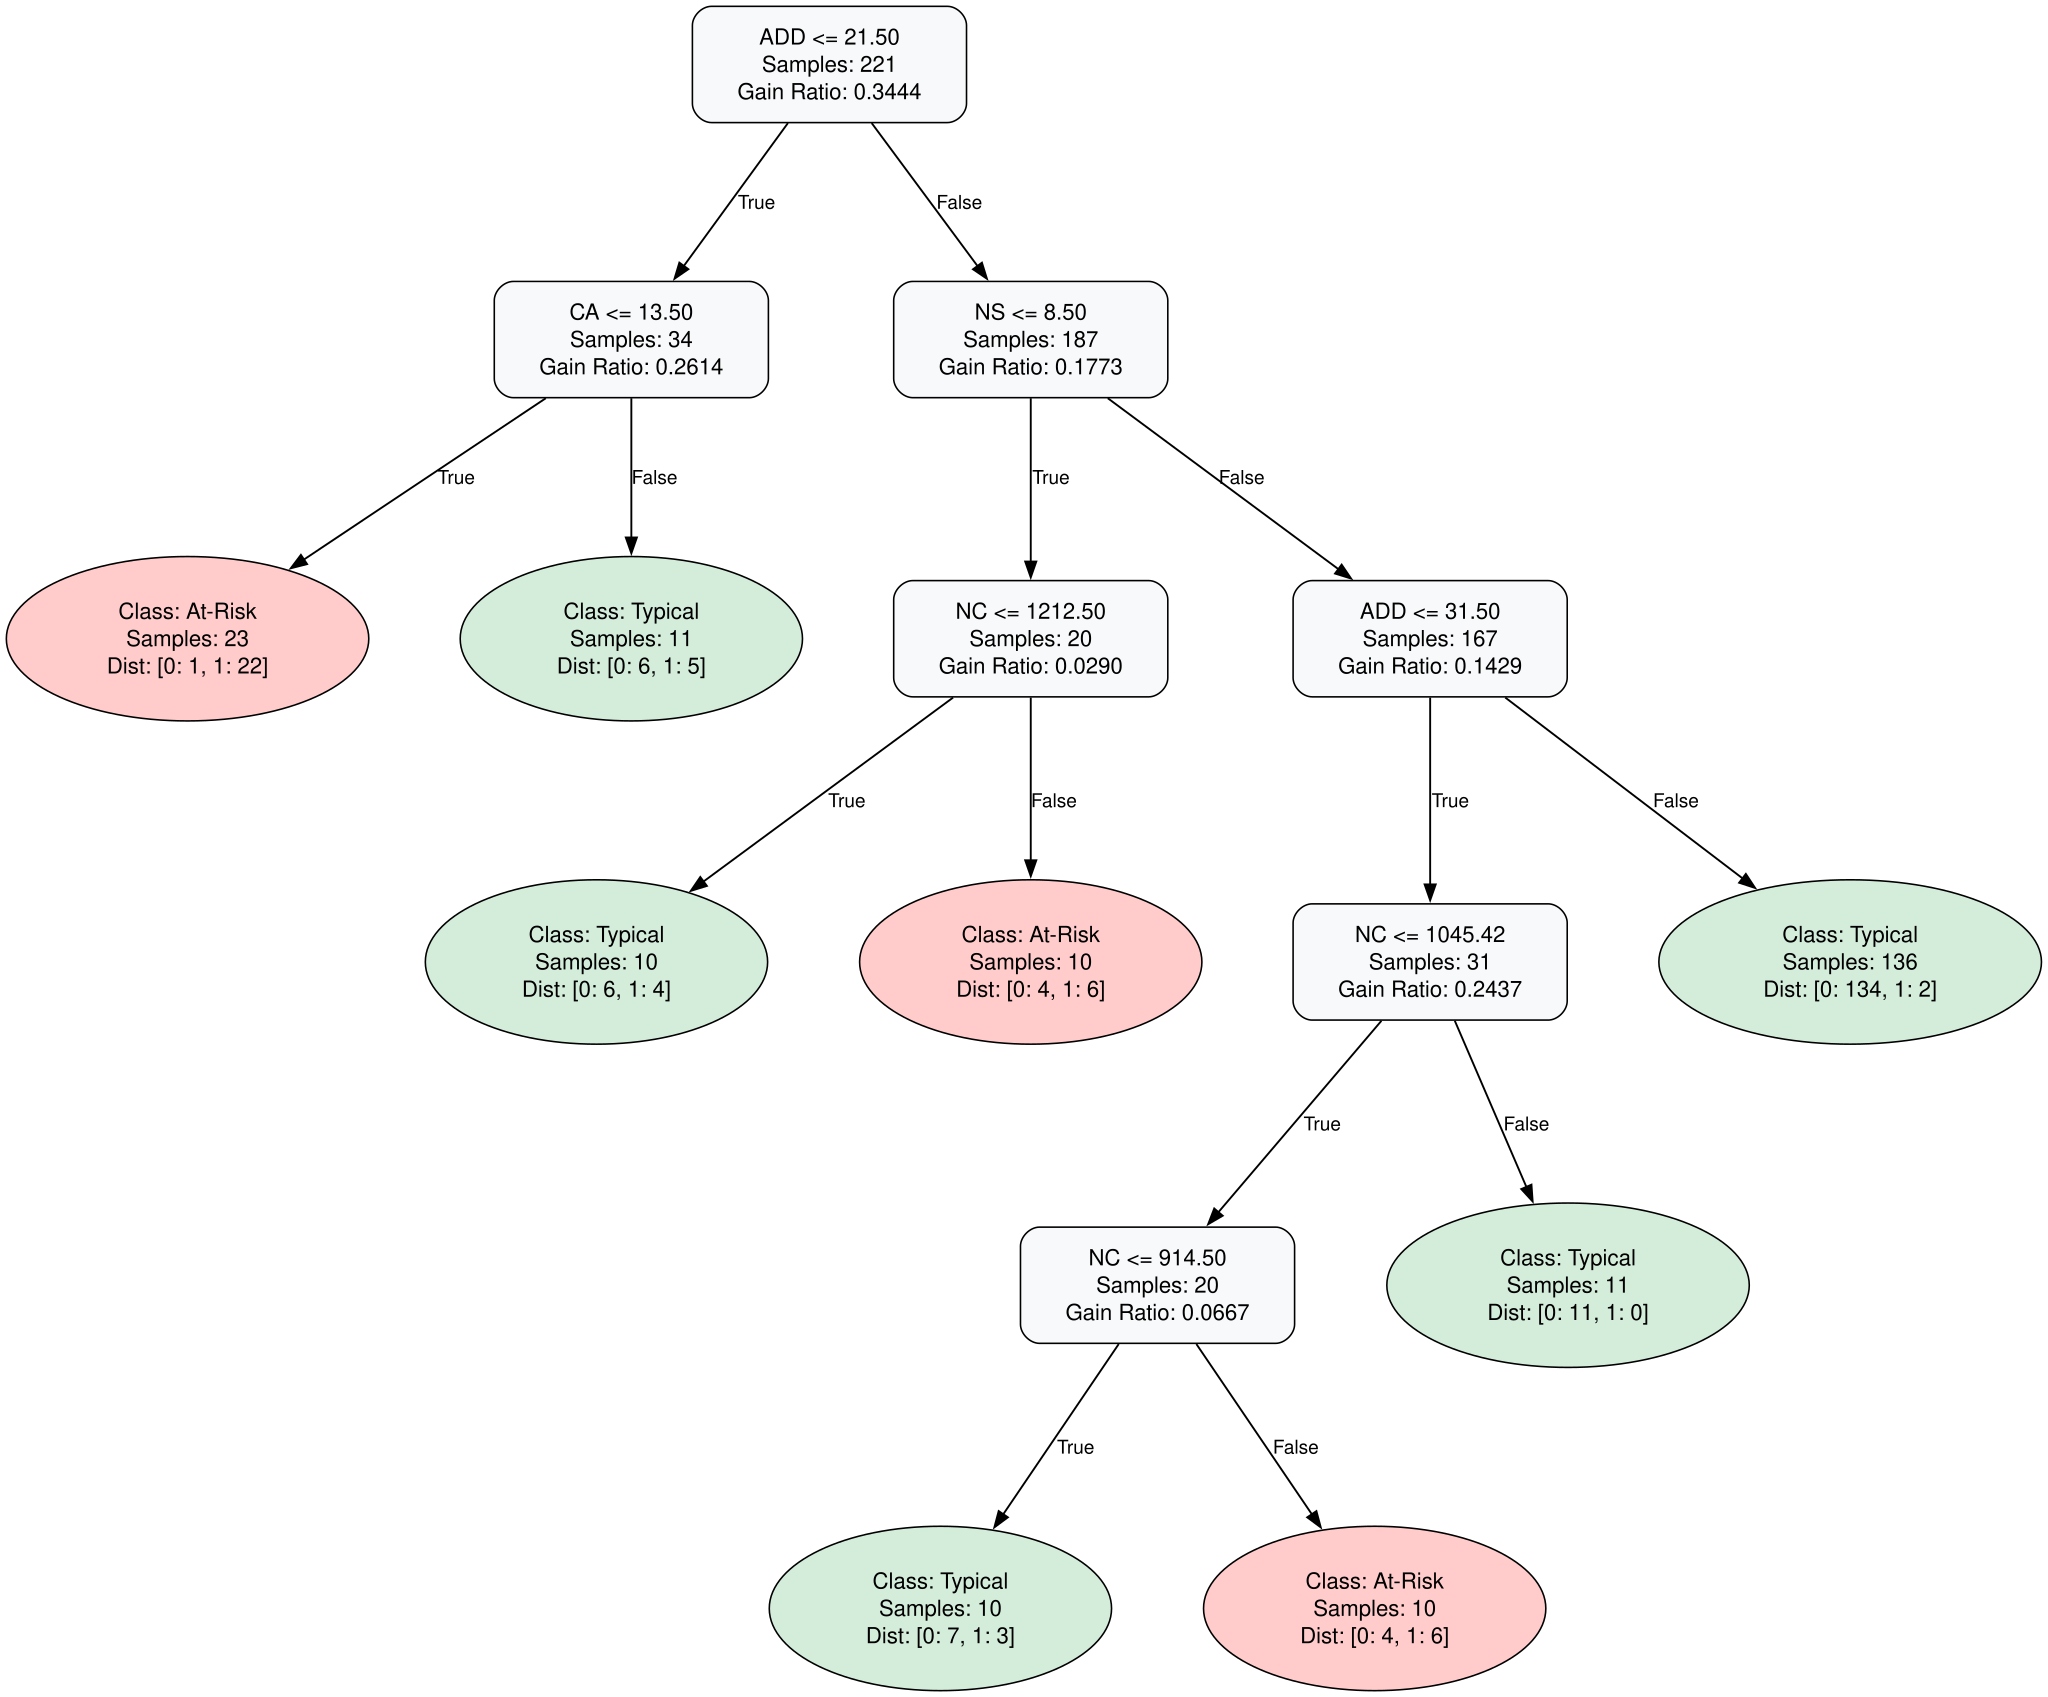


Displayed tree: TRSTR | no_threshold
Saved to: /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/outputs/figures/final_model_trees/TRSTR_no_threshold_final_tree.svg


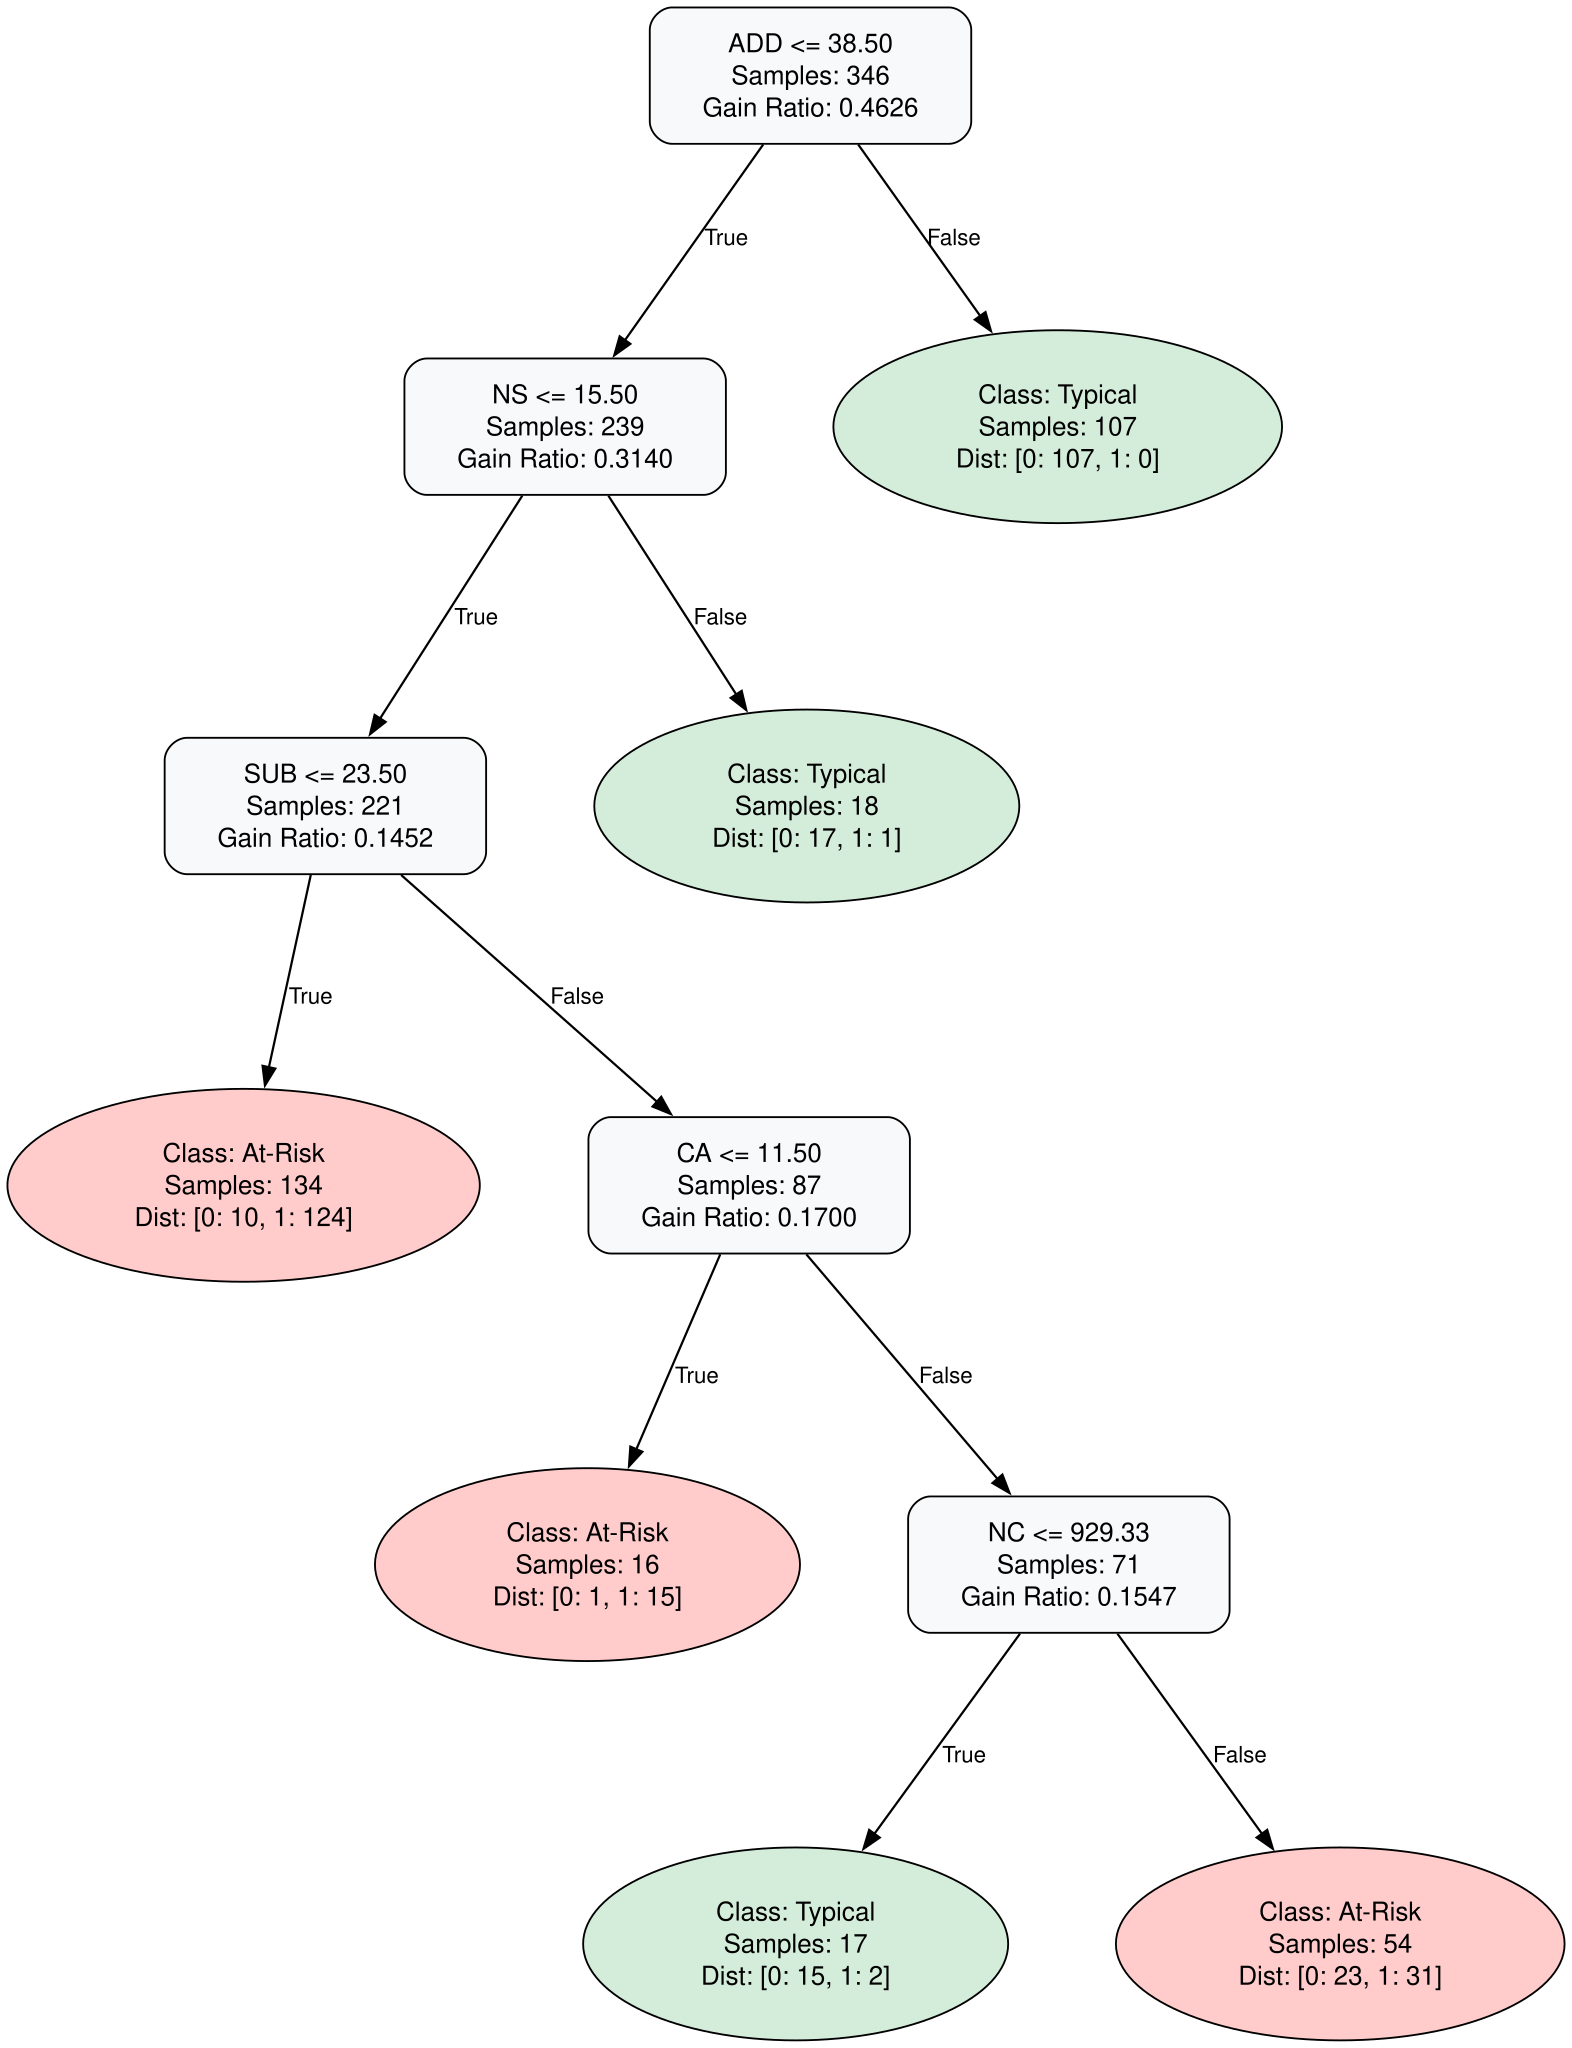


Displayed tree: TRTR | thresholded
Saved to: /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/outputs/figures/final_model_trees/TRTR_thresholded_final_tree.svg


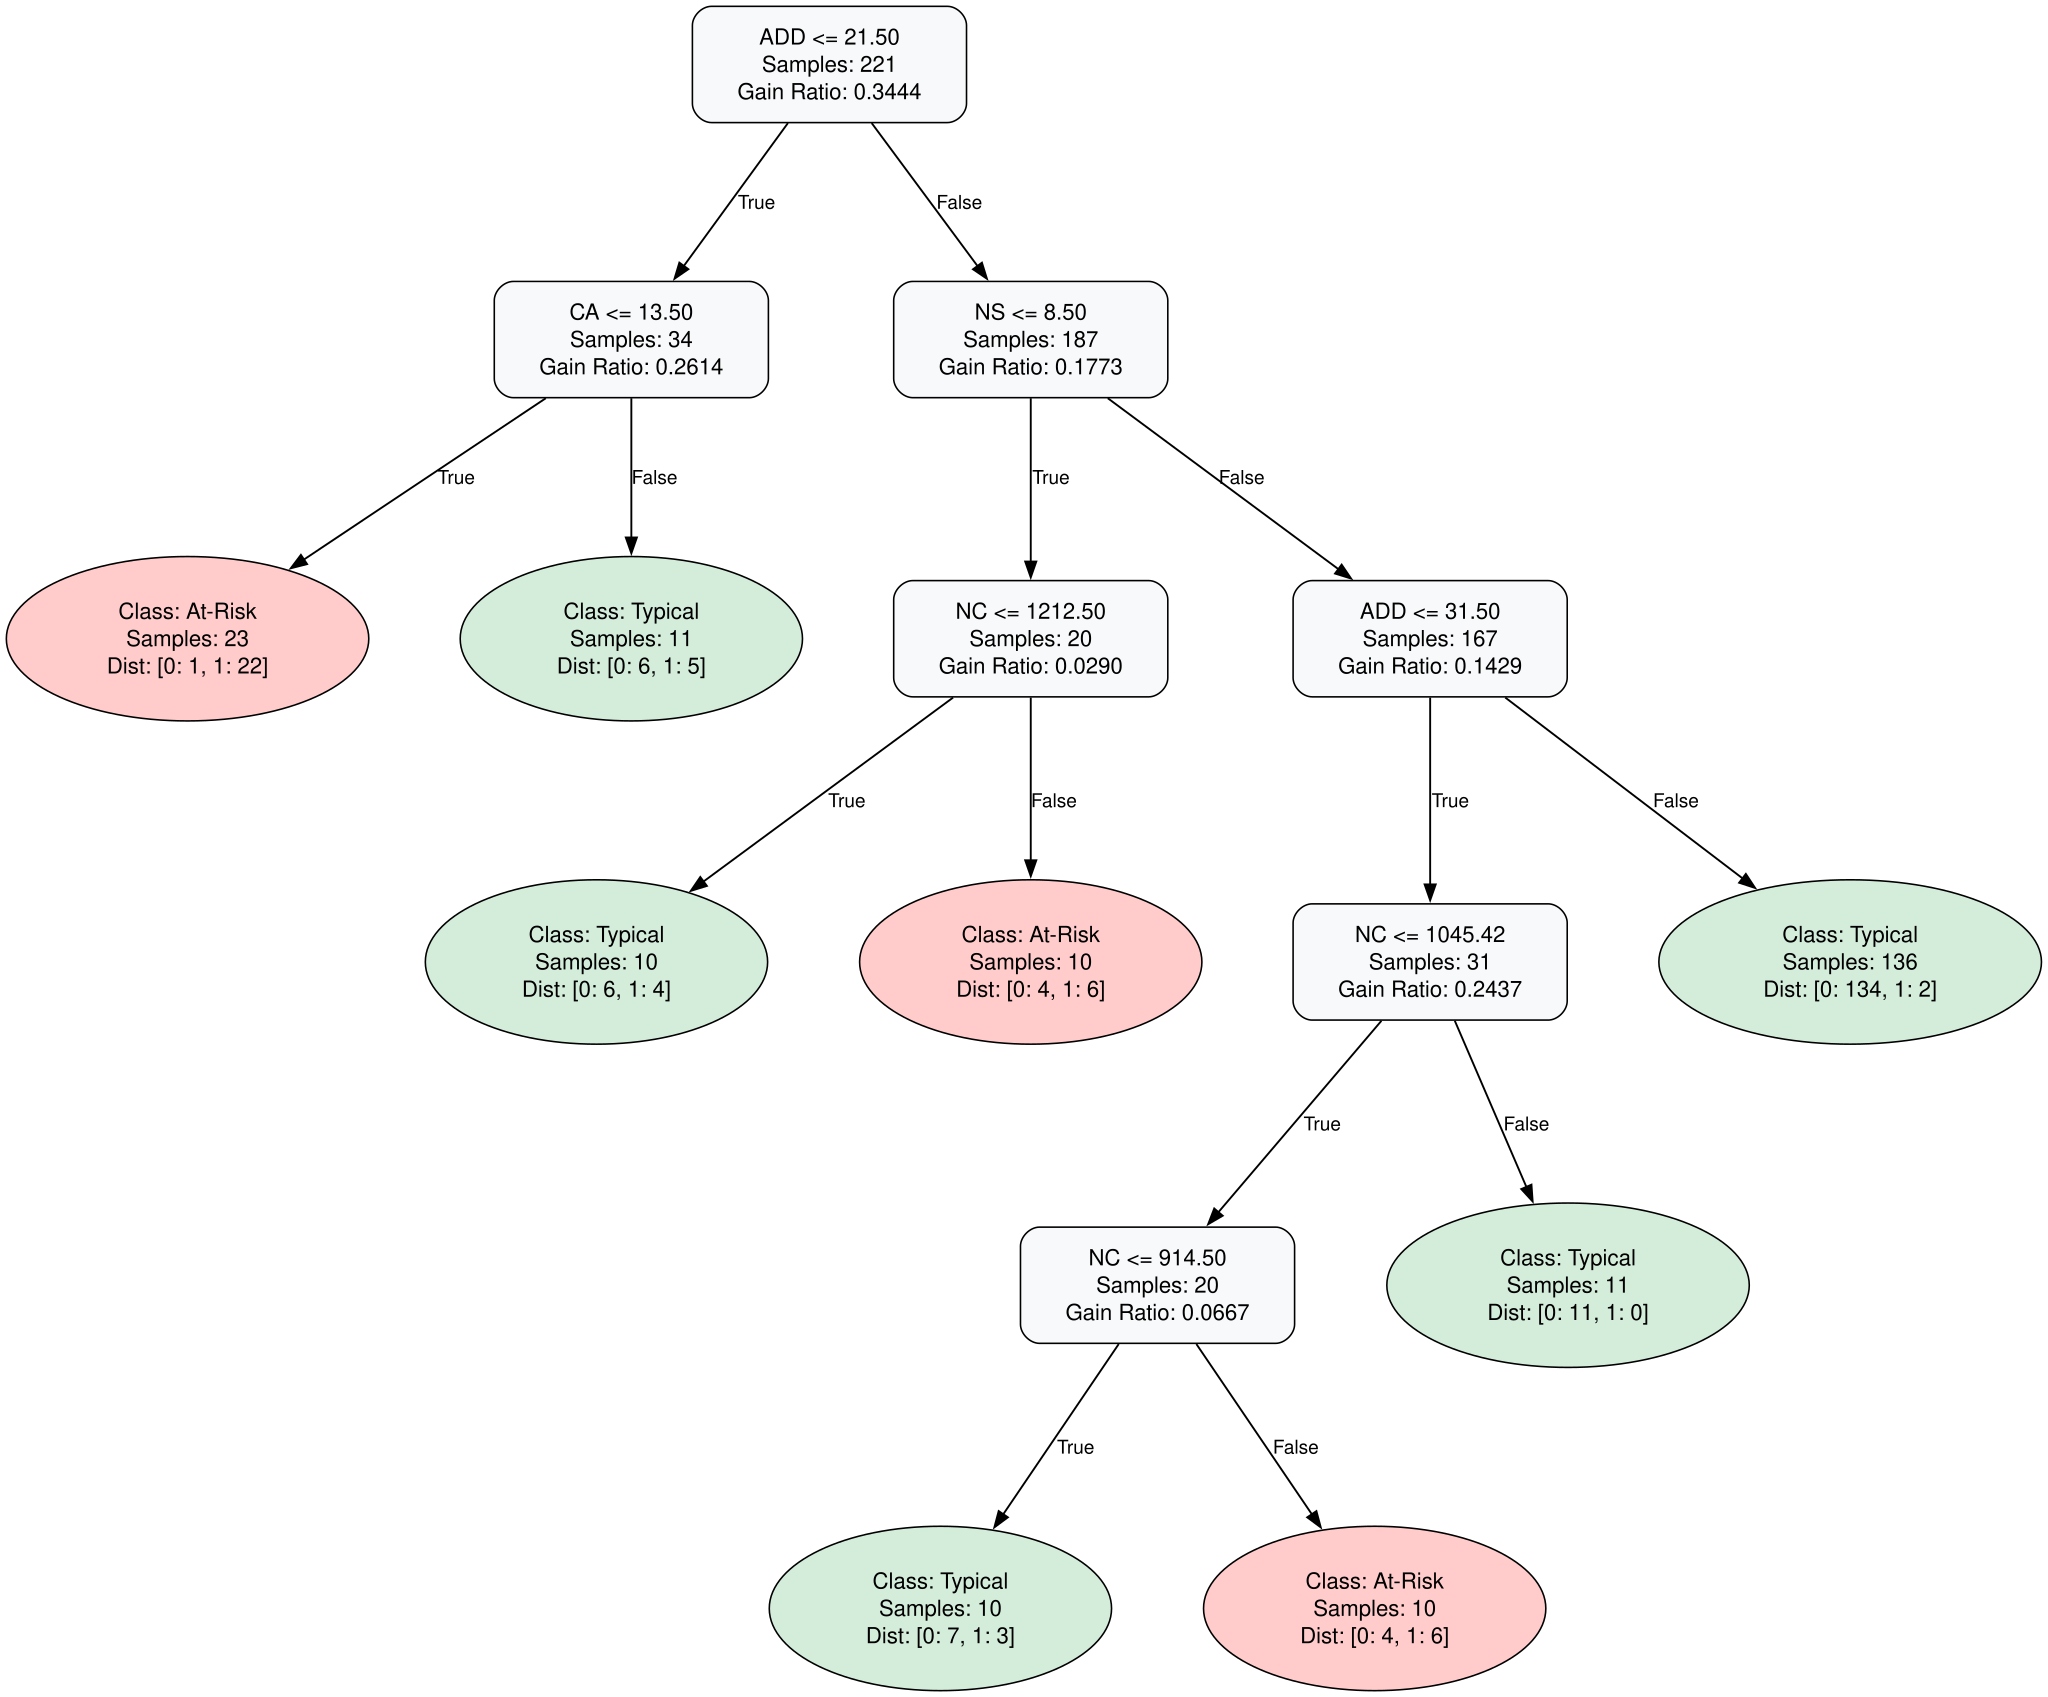


Displayed tree: TRSTR | thresholded
Saved to: /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/outputs/figures/final_model_trees/TRSTR_thresholded_final_tree.svg


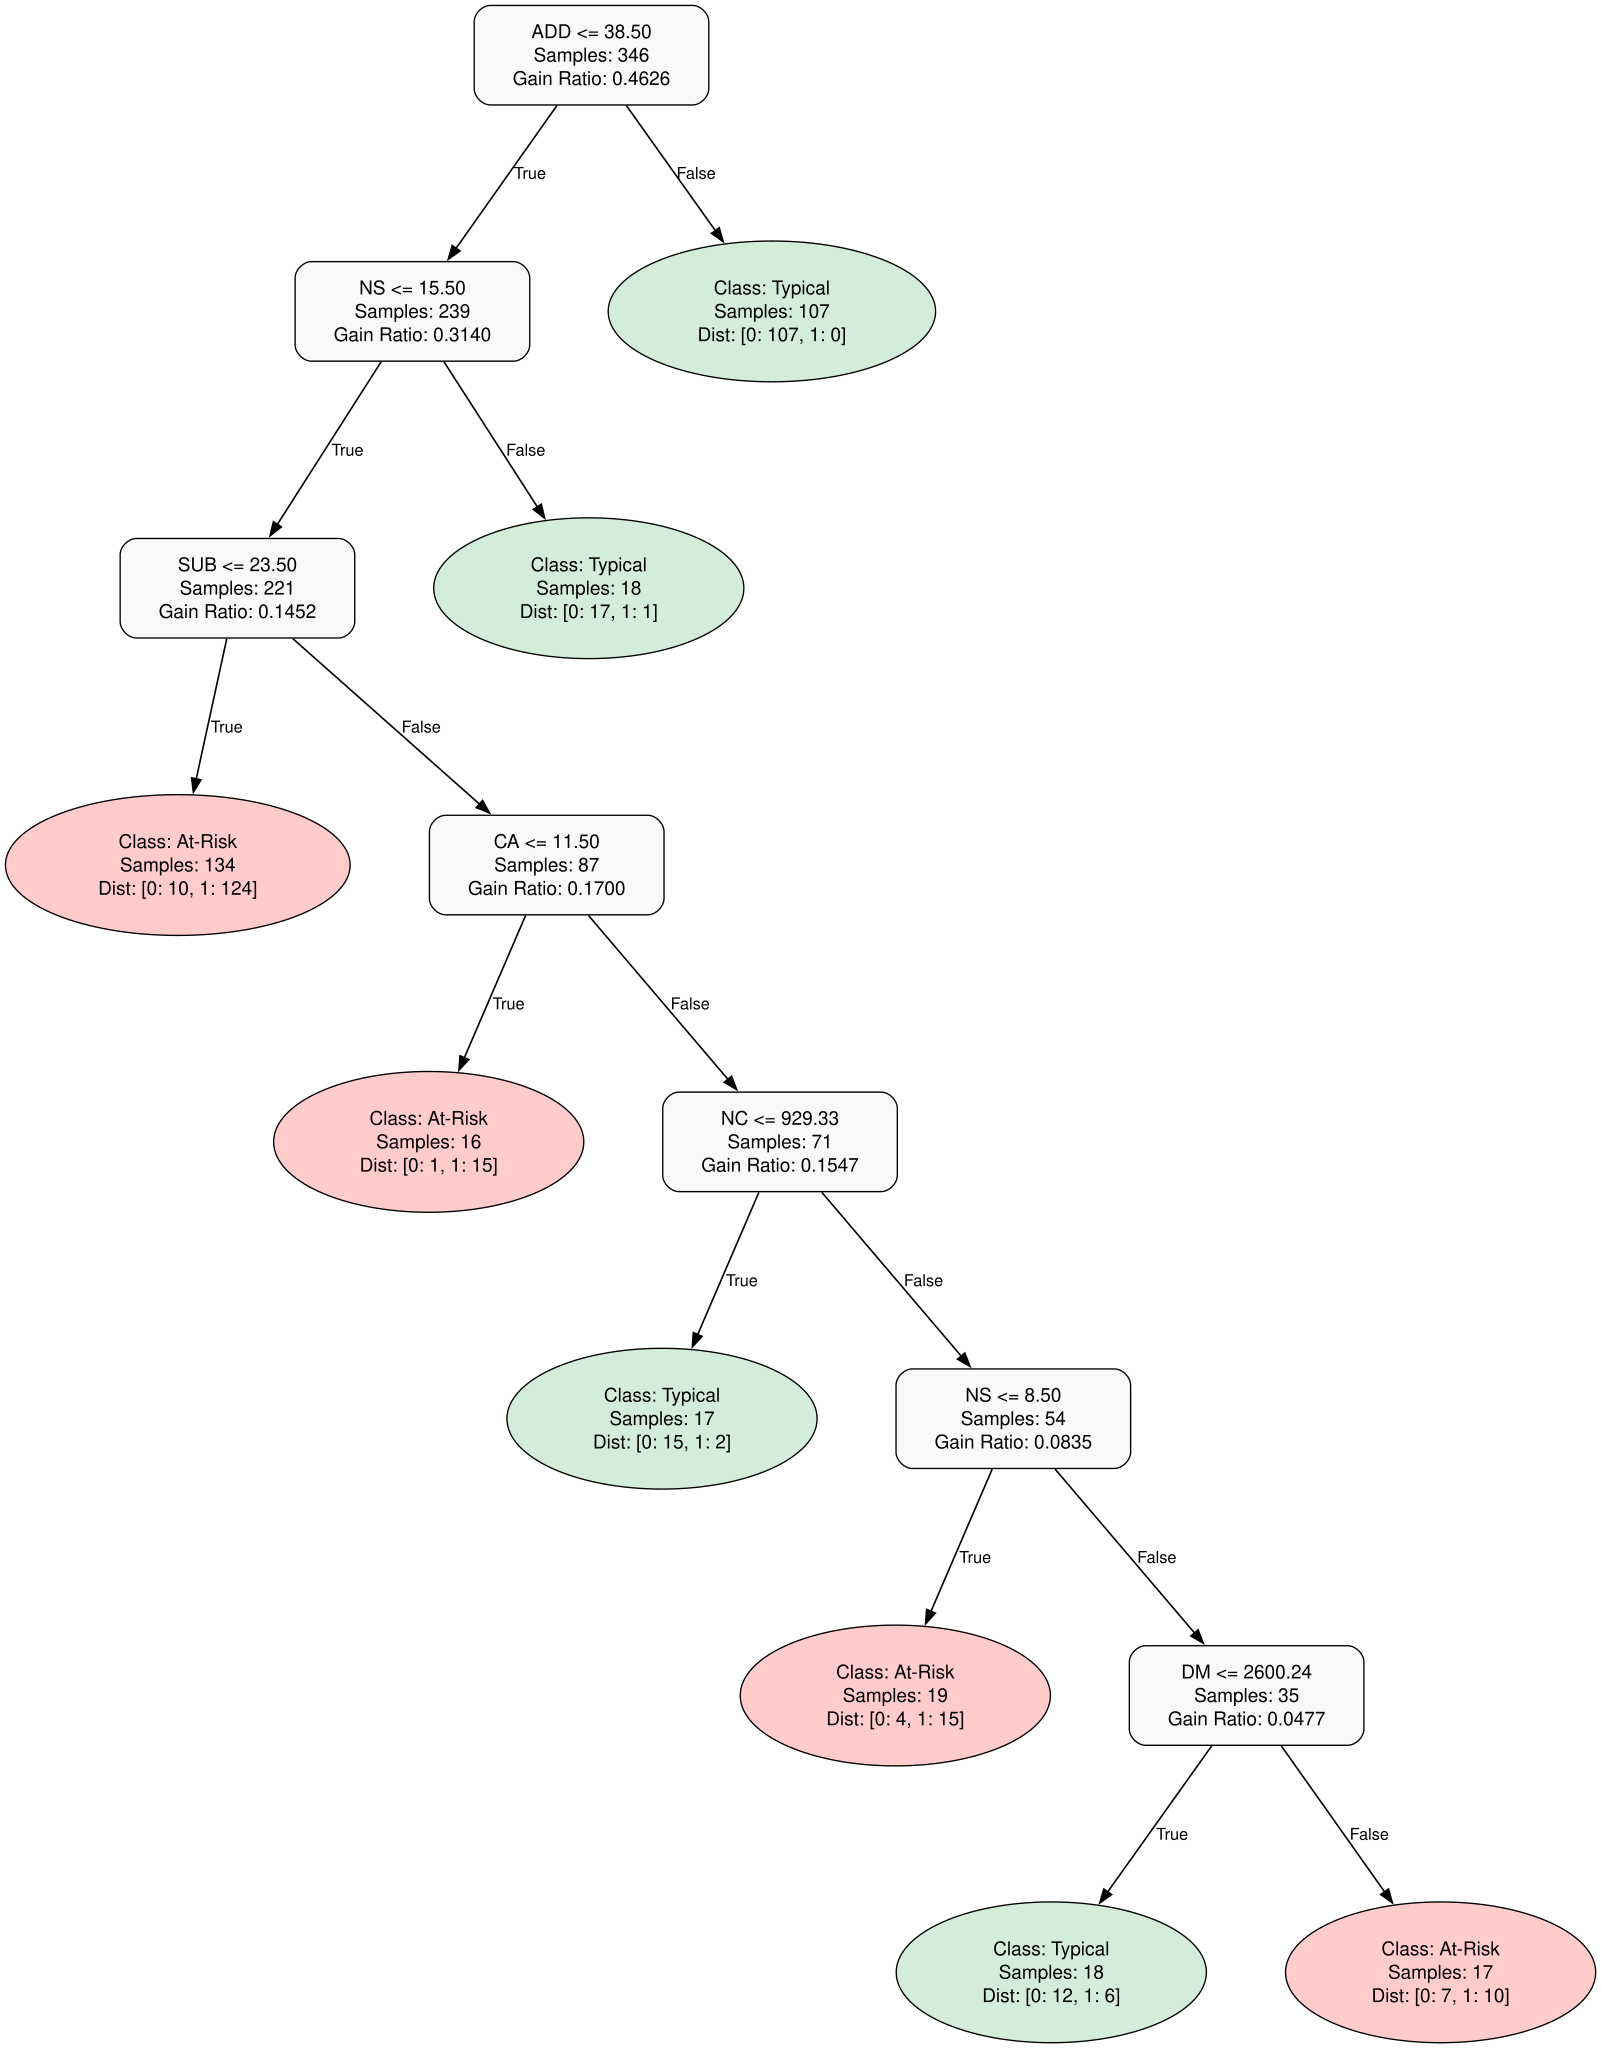

In [ ]:
from IPython.display import SVG, display
from pathlib import Path

# Folder where SVG tree files will be saved
TREE_DIR = Path(OUTPUTS_DIR / "figures" / "final_model_trees")
TREE_DIR.mkdir(exist_ok=True)

DISPLAY_WIDTH = "100%"      # fits notebook cell width
# DISPLAY_WIDTH = "1200px"  # alternative fixed width

for mode in final_trees:
    for label in final_trees[mode]:
        tree_model = final_trees[mode][label]

        base_filename = TREE_DIR / f"{label}_{mode}_final_tree"

        export_tree_svg(
            tree_model=tree_model,
            base_filename=str(base_filename)
        )

        svg_path = f"{base_filename}.svg"

        print(f"\nDisplayed tree: {label} | {mode}")
        print(f"Saved to: {svg_path}")

        display(SVG(filename=svg_path))

## Final Validator Notes: Limitations and Claim Boundaries

The pipeline is suitable for thesis-level proof-of-concept validation if the following limitations are acknowledged:

1. **Sample size limitation:** The dataset is relatively small, so model results should be interpreted cautiously.
2. **Screening-label limitation:** The At-Risk label is derived from an operational RMAT percentile cutoff and is not a clinical diagnosis.
3. **Synthetic-data limitation:** Statistical similarity between real and synthetic samples supports training augmentation, but it does not establish equivalence to real learner records.
4. **Generalizability limitation:** Results from this dataset may not generalize to all learner populations without further external validation.
5. **Deployment limitation:** The system is intended for teacher-in-the-loop screening support and instructional planning only.

Recommended final claim wording:

> The revised DysCalc ML pipeline provides methodologically defensible proof-of-concept evidence that synthetic minority-class augmentation can improve At-Risk screening sensitivity under a teacher-in-the-loop decision-support framework. The model output should be interpreted as a screening support indicator, not as a clinical diagnosis.
